# Used Car Valuation & Price Driver Analysis

[Machine Learning Overview!](../images/kurt.jpeg)


## Introduction: Business Understanding

My client is a used car dealership looking to optimize its inventory acquisition and pricing strategy. This analysis quantifies consumer valuation drivers to provide actionable recommendations for the dealership:

*   **Trade-in Appraisals:** Establishing accurate baseline offers based on vehicle age, mileage, and condition.
*   **Auction Sourcing:** Identifying high-value attributes (such as drivetrains, engine sizes, and vehicle classes) that command market premiums.
*   **Title & Risk Penalties:** Measuring the financial depreciation associated with salvage and rebuilt titles.

### Project Overview

This project applies the CRISP-DM framework to a dataset of 426K used car listings, focusing on identifying key price drivers. After extensive data cleaning, feature engineering, and rigorous model evaluation, we recommend deploying a Lasso Regression model. This model effectively captures 75.3% of market variance with a Mean Absolute Error of approximately $4,789, providing clear, actionable insights for inventory pricing.

### Project Roadmap (CRISP-DM Framework)

[CRISP-DM Framework](../images/crisp.png)

1.  **Business Understanding:** Framing dealership valuation objectives.
2.  **Data Understanding & Cleanup:** Profiling raw schema, inspecting missing values, and executing domain-driven imputation.
3.  **Data Preparation & Feature Engineering:** Analyzing target correlations, filtering market outliers, applying transformations, and encoding categoricals.
4.  **Modeling:** Training and tuning Linear, Ridge, and Lasso regression models.
5.  **Evaluation:** Assessing performance metrics ($R^2$, RMSE, MAE) and residual behavior.
6.  **Deployment & Dealership Recommendations:** Translating model weights into practical inventory strategies.

In [ ]:
# All imports for the project

from datetime import datetime
import os
import time
from typing import Any, Dict, Optional, Tuple

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

import joblib # Model serialization

# Scikit-learn
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

In [ ]:
# For work in Google CoLab only
from google.colab import drive
drive.mount('/content/drive')
# replace path accordingly
path = 'drive/MyDrive/all_data/11.1/'

Mounted at /content/drive


The following are helper functions I created to use throughout the notebook. I have moved them here to run all at once duirng repeated runs.

In [ ]:
# Phase 1 Cleanup

def get_nan_df(df: pd.DataFrame) -> pd.DataFrame:
  """Returns a numeric DataFrame of missing counts and percentages for all columns."""
  nan_counts = df.isna().sum()
  nan_pct = (nan_counts / len(df) * 100).round(1)

  return pd.DataFrame({'Missing Count': nan_counts, 'Percentage (%)': nan_pct})


def get_nan_summary(
    df: pd.DataFrame, df_name: str = 'DataFrame'
) -> pd.DataFrame:
  """Computes, prints, and returns a sorted summary table of missing values in a DataFrame.

  Args:
      df: The input pandas DataFrame to analyze.
      df_name: Optional name for labeling the output message.

  Returns:
      A sorted pandas DataFrame summarizing problematic columns with missing
      values, including a formatted TOTAL row. Returns an empty DataFrame if no
      missing values exist.
  """
  nan_table = get_nan_df(df)

  # 2. Filter to only columns with missing data and sort descending
  problematic_table = (
      nan_table[nan_table['Missing Count'] > 0]
      .sort_values(by='Missing Count', ascending=False)
      .copy()
  )

  if problematic_table.empty:
    print(f"<{df_name}>: No missing values detected.\n")
    return problematic_table

  # 3. Calculate and append the summary total row
  total_missing = problematic_table['Missing Count'].sum()
  total_pct = problematic_table['Percentage (%)'].sum().round(1)

  problematic_table.loc['TOTAL'] = [total_missing, total_pct]
  problematic_table['Missing Count'] = problematic_table[
      'Missing Count'
  ].astype(int)

  print(f"<{df_name}> Missing Data Breakdown\n")
  return problematic_table

In [ ]:
# Phase 2

# quick helper function to clean output the distribution
def print_interval_distribution(
    df: pd.DataFrame, column: str, bins: list, labels: list
) -> pd.DataFrame:
  """
  Bins a continuous column using `pd.cut` into defined intervals and returns
  count + percentage breakdown.
  """
  binned_series = pd.cut(
      df[column],
      bins=bins,
      labels=labels,
      right=True,
      include_lowest=True,
  )

  counts = binned_series.value_counts(sort=False)
  percentages = (counts / len(df) * 100).round(2)

  summary_table = pd.DataFrame({
      "Range": labels,
      "Record Count": counts.values,
      "Percentage (%)": percentages.values,
  })

  print(f"\n==================================================")
  print(f"  Distribution Breakdown: '{column}'")
  print(f"==================================================")
  print(summary_table.to_string(index=False))
  return summary_table


In [ ]:
# Phase 2,3

def _create_output_path(filename:str, ext: str) -> str:
  return os.path.join(
      path,
      "data",
      "output",
      f"{filename}.{ext}"
  )

# File Path construction for saving DataFrame
def create_parquet_path(filename: str) -> str:
  return _create_output_path(
      os.path.join("dataframes", filename),
      "parquet"
  )

def create_joblib_path(filename: str) -> str:
  return _create_output_path(
      os.path.join("models", filename),
      "joblib"
  )

In [ ]:
# Phase 3
def evaluate_regression_model(
    model_name: str,
    model: Any,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    fit_model: bool = True,
    results_df: pd.DataFrame | None = None,
) -> pd.DataFrame | None:
  """Fits, evaluates, and stores regression metrics.

  If `results_df` is provided, mutates it in-place and returns None.
  If `results_df` is None, creates and returns a new DataFrame.
  """
  clean_name = model_name.strip()

  # 1. Fit model and measure training latency
  start_fit = time.perf_counter()
  if fit_model:
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - start_fit
  else:
    fit_time = -1.0

  # 2. Predict on Train and Test splits
  start_pred = time.perf_counter()
  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)
  pred_time = time.perf_counter() - start_pred

  # 3. Compute Metrics (RMSE, MAE, R²)
  train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
  test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

  train_mae = mean_absolute_error(y_train, y_train_pred)
  test_mae = mean_absolute_error(y_test, y_test_pred)

  train_r2 = r2_score(y_train, y_train_pred)
  test_r2 = r2_score(y_test, y_test_pred)
  generalization_gap = train_r2 - test_r2

  # 4. Assemble Record Dictionary
  metrics = {
      "Model": clean_name,
      "Train RMSE ($)": round(train_rmse, 2),
      "Test RMSE ($)": round(test_rmse, 2),
      "Train MAE ($)": round(train_mae, 2),
      "Test MAE ($)": round(test_mae, 2),
      "Train R²": round(train_r2, 4),
      "Test R²": round(test_r2, 4),
      "Generalization (ΔR²)": round(generalization_gap, 4),
      "Fit Time (s)": round(fit_time, 3),
      "Predict Time (s)": round(pred_time, 3),
  }
  new_row_df = pd.DataFrame([metrics])

  # 5. Handle In-Place Update vs. Return
  if results_df is None:
    return new_row_df

  # Compute replacement table
  if not results_df.empty and clean_name in results_df["Model"].values:
    print(
        f"[Benchmark Update] '{clean_name}' already exists. Replacing previous"
        " entry."
    )
    combined = pd.concat([results_df, new_row_df], ignore_index=True)
    updated = (
        combined.drop_duplicates(subset=["Model"], keep="last")
        .reset_index(drop=True)
    )
  else:
    combined = pd.concat([results_df, new_row_df], ignore_index=True)
    updated = combined.reset_index(drop=True)

  # Mutate results_df in place by clearing and setting index/columns/values
  results_df.drop(results_df.index, inplace=True)
  for col in updated.columns:
    results_df[col] = updated[col]

  return None

In [ ]:
# load the DataFrame
vehicles_df = pd.read_csv(path + 'data/vehicles.csv')
vehicles_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

## Phase 1: Understanding through Exploratory Data Analysis (EDA) and Initial Cleanup

In this phase, I explore the raw dataset and examine feature distributions. By understanding what the data represents, I combine industry conventions with my domain background to assess data quality, evaluate missing data patterns, and clean the vehicle inventory.

I achieve this by:
* Performing foundational structural cleaning to prune noisy and redundant attributes.
* Filtering non-viable records to isolate dealership-grade inventory.
* Resolving missing specifications through hierarchical domain imputation.

This establishes a clean, robust baseline for feature engineering and model preparation.


In [ ]:
df = vehicles_df.copy() # standard naming of starting DataFrame

df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


**Note**: I have created a helper function `get_nan_df()` to output a clean-formatted dump of the NaN values so I can check it repeatedly.

In [ ]:
print(get_nan_summary(vehicles_df, "OG DataFrame"))

<OG DataFrame> Missing Data Breakdown

              Missing Count  Percentage (%)
size                 306361            71.8
cylinders            177678            41.6
condition            174104            40.8
VIN                  161042            37.7
drive                130567            30.6
paint_color          130203            30.5
type                  92858            21.8
manufacturer          17646             4.1
title_status           8242             1.9
model                  5277             1.2
odometer               4400             1.0
fuel                   3013             0.7
transmission           2556             0.6
year                   1205             0.3
TOTAL               1215152           284.6


### 1.1: Feature Selection and Column Pruning

To reduce dimensionality and eliminate uninformative noise, the following features are dropped prior to modeling:
* **`id`**: It is not clear where this value is populated from. However, we have no reason to keep it when a DataFrame automatically creates its own. I noticed that the values are quite long so we can save some space by using the automatically generated ones rather than using `set_index`
* **`VIN` (Unique Identifier):** Vehicle Identification Numbers have near 1:1 cardinality with dataset rows. They carry zero generalizable predictive signal for linear regression and introduce 37.7% missingness. We rely on standard dataframe indexing instead.
* **`size` (High Sparsity & Proxy Redundancy):** Over 71.8% of the data in this column is missing. Furthermore, vehicle dimensions are effectively captured by the `type` feature (such as sedan, pickup, or SUV) and specific `model` indicators, making aggressive synthetic imputation unnecessary.
* **`paint_color` (Negligible Mass-Market Valuation Impact):** Color choice accounts for marginal price variance in standard used vehicle transactions while introducing 30.5% missingness. Excluding it prevents overparameterization across nominal categories.


In [ ]:
# Begin construction of cleaned dataframe
df.drop(['id', 'VIN', 'size', 'paint_color'], axis=1, inplace=True)

How about the `region` vs `state`? These features seem like they would have some overlap.

In [ ]:
print(df['region'].unique())
print(df['state'].unique())

['prescott' 'fayetteville' 'florida keys' 'worcester / central MA'
 'greensboro' 'hudson valley' 'medford-ashland' 'erie' 'el paso'
 'bellingham' 'skagit / island / SJI' 'la crosse' 'auburn' 'birmingham'
 'dothan' 'florence / muscle shoals' 'gadsden-anniston'
 'huntsville / decatur' 'mobile' 'montgomery' 'tuscaloosa'
 'anchorage / mat-su' 'fairbanks' 'kenai peninsula' 'southeast alaska'
 'flagstaff / sedona' 'mohave county' 'phoenix' 'show low' 'sierra vista'
 'tucson' 'yuma' 'fort smith' 'jonesboro' 'little rock' 'texarkana'
 'bakersfield' 'chico' 'fresno / madera' 'gold country' 'hanford-corcoran'
 'humboldt county' 'imperial county' 'inland empire' 'los angeles'
 'mendocino county' 'merced' 'modesto' 'monterey bay' 'orange county'
 'palm springs' 'redding' 'reno / tahoe' 'sacramento' 'san diego'
 'san luis obispo' 'santa barbara' 'santa maria' 'SF bay area'
 'siskiyou county' 'stockton' 'susanville' 'ventura county'
 'visalia-tulare' 'yuba-sutter' 'boulder' 'colorado springs' 'denve

### 1.2: Dropping `region` Feature
I drop `region` because its 400+ granular local sub-markets introduce high-cardinality sparsity and risk model overfitting. From experience, I know that state lines do affect car prices, so the `state` feature should be good enough to capture geographic price differences. In fact, I may think about creating state groupings as well (see Phase 2).


In [ ]:
df = df.drop(columns=["region"])

### 1.3: Dropping Problematic Rows: `year` and `odometer`

Is there a possibility of removing any other columns? I don't think so, but I do think there is scope for removing **pieces** of other columns—specifically `year` and `title_status`.

Anyone with real-life experience buying and selling cars knows that `year` directly drives price and is very important. However, it is difficult to impute a value. As a car fan, I know it is technically possible to guess a year range from a combination of other columns (and as we'll see later, the `model` column actually includes the year for some vehicles). But building a custom filter or regex imputation function would be overly complicated, especially since other columns have missing values too. In fact, `year` is needed to help impute those other columns, which creates a circular dependency problem.

Since missing `year` values account for only **0.3%** of the dataset, the cleanest choice is to simply drop the records missing a year.

For the exact same reason, I am dropping missing values in `odometer`—another critical driver of used car prices.


In [ ]:
df.dropna(subset=['year', 'odometer'], inplace=True)

# Validation
print(
    f"NaN Counts: Year: {df['year'].isna().sum()},"
    f" Odometer: {df['odometer'].isna().sum()}"
)


NaN Counts: Year: 0, Odometer: 0


This looks much better—there are no more `NaN` values. Following ML best practices, `vehicle_age` is typically preferred over raw `year`.

### 1.4: Transforming `year` to `vehicle_age`

While both metrics carry the exact same mathematical correlation with price, vehicle age directly captures annual depreciation—which is how dealerships evaluate inventory. It grounds our baseline price at a brand-new car (age 0) and prevents model drift as new inventory arrives over time.

I am transforming this data dynamically using the current calendar year via a lookup so this pipeline can run anytime without hardcoded dates.

In [ ]:
current_year = datetime.datetime.now().year
df['vehicle_age'] = current_year - df['year']

# verify a sample to ensure the years are correct
df[['year', 'vehicle_age']].sample(5)


,year,vehicle_age
365561,2006.0,20.0
107155,2006.0,20.0
127393,2010.0,16.0
165593,2006.0,20.0
240000,2014.0,12.0


The age is lining up. We can now drop the original `year`.

In [ ]:
df.drop(columns=['year'], inplace=True)

Turning my attention to the `title_status` column now:

In [ ]:
print(df['title_status'].unique())

['clean' 'rebuilt' 'lien' nan 'salvage' 'missing' 'parts only']


### 1.5: Handling `title_status`

I have filtered out `NaN` and `parts only` records (<2% of data) to keep the model focused strictly on dealership-grade inventory.

Retaining `salvage`, `rebuilt`, `lien`, and `clean` titles will allow the model to accurately calculate the price penalties of title defects. In other words, it will provide valuable information on the negative correlations in this column as well.

In [ ]:
# This automatically drops 'missing', 'parts only', and 'nan'
valid_titles = ['clean', 'rebuilt', 'lien', 'salvage']
df = df[df['title_status'].isin(valid_titles)]

Now examining the `condition` colum:

In [ ]:
print(df['condition'].unique())

['good' 'excellent' 'fair' nan 'like new' 'new' 'salvage']


In [ ]:
print(get_nan_summary(df, "Cleaned DF: VIN,paint, size, title, year, odometer"))

<Cleaned DF: VIN,paint, size, title, year, odometer> Missing Data Breakdown

              Missing Count  Percentage (%)
cylinders            173170            41.9
condition            168249            40.7
drive                124706            30.2
type                  90775            22.0
manufacturer          15898             3.8
model                  5063             1.2
transmission           1643             0.4
fuel                   1623             0.4
TOTAL                581127           140.6


### 1.6: Handling Missing `condition` Data
Domain & Statistical Rationale:
* Empirical Driver of Value: Vehicle condition is an established driver of market valuation (e.g., standard automotive indices like Kelley Blue Book).
* Avoiding Synthetic Distortion: Because condition is subjective and missing in ~41% of records, imputing values using other features or filling via frequency ratios risks injecting artificial bias and degrading feature correlations.
* Preserving Real-World Generalization: Creating an explicit 'Unknown' category enables the linear model to quantify the baseline value of unspecified listings directly, allowing the dealership to price incoming inventory even when physical condition ratings are omitted.

In [ ]:
df['condition'] = df['condition'].fillna('Unknown')

### 1.7: Domain-Driven Imputation: `manufacturer`, `model`, and `vehicle_age`

As a car enthusiast, my domain knowledge tells me that a vehicle's core specifications are tightly determined by its **make, model, and year**.

* For example, knowing a car is a 2018 Ford Mustang gives us a very accurate proxy for its drivetrain (`rwd`), engine options, and body type (`coupe`/`convertible`).

Rather than guessing or filling missing categorical values with global averages, I am using a **hierarchical conditional imputation** strategy across our remaining problematic columns (`drive`, `cylinders`, and `type`).

I am restricting conditional imputation to two precise tiers:
1. `manufacturer` + `model` + `vehicle_age` (Generation Mode)
2. `manufacturer` + `model` (Model-level Mode)

Any edge cases that cannot be resolved at the model level are assigned to an explicit `'Unknown'` category.

Before proceeding with the imputation, the data must be examined. This will show any patterns to resolve the imputation. If nothing else, it can also be used as a baseline to see what happens afterward.

In [ ]:
# let's examine the columns before any transformation

inspect_cols = ['cylinders', 'type', 'transmission', 'fuel']

for col in inspect_cols:
  print(f"\n--- Column: {col} ---")
  print("Unique values:")
  print(df[col].unique())
  print("\nValue Counts (including NaN):")
  print(df[col].value_counts(dropna=False).head(10))


--- Column: cylinders ---
Unique values:
['8 cylinders' '6 cylinders' nan '4 cylinders' '5 cylinders' 'other'
 '3 cylinders' '10 cylinders' '12 cylinders']

Value Counts (including NaN):
cylinders
NaN             173170
6 cylinders      90550
4 cylinders      74199
8 cylinders      69990
5 cylinders       1677
10 cylinders      1415
other             1158
3 cylinders        618
12 cylinders       197
Name: count, dtype: int64

--- Column: type ---
Unique values:
['pickup' 'truck' 'other' nan 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'van' 'convertible' 'wagon']

Value Counts (including NaN):
type
NaN          90775
sedan        83982
SUV          73744
pickup       42390
truck        34160
other        21293
coupe        18679
hatchback    16274
wagon        10415
van           7872
Name: count, dtype: int64

--- Column: transmission ---
Unique values:
['other' 'automatic' 'manual' nan]

Value Counts (including NaN):
transmission
automatic    325056
other         6

### 1.8: Standardizing and Imputing `type`, `cylinders`, `transmission`, and `fuel`

Inspecting the unique value distributions revealed key opportunities for data refinement:

* **Category Consolidation (`type`):** `pickup` and `truck` describe the same functional vehicle class in used car markets. Combining `pickup` into `truck` prevents redundant feature splitting.
* **Extracting Numeric Cylinders:** Because cylinder counts represent physical engine size, I extracted numeric integers (`4`, `6`, `8`) to allow the linear model to capture linear scale rather than treating each engine format as an isolated nominal category.

I can proceed with the Missing values across `type`, `cylinders`, `transmission`, and `fuel` through the hierarchical imputation suggested above: `make + model + age` $\rightarrow$ `make + model` $\rightarrow$ `make`.


Unfortunatelly, looking at our `NaN` values above, `manufacturer` and `model` themselves have some empty spots. I wanted to examine this first.

In [ ]:
target_indices = [384, 2241, 2826, 3420]

# Pull exact target rows
target_rows = df.loc[target_indices, ['manufacturer', 'model']]

# Pull reproducible random sample for the rest
random_sample = (
    df.drop(index=target_indices)[['manufacturer', 'model']]
    .sample(10, random_state=42)
)

# Display combined sample
final_sample = pd.concat([target_rows, random_sample])
print("Target Edge Cases + Random Sample:")
print(final_sample)

Target Edge Cases + Random Sample:
       manufacturer                       model
384             bmw                          x6
2241           ford                 f150 lariat
2826      chevrolet              silverado 2500
3420           ford   f150 super cab xlt pickup
320807         ford  f-250 super duty lariat li
388767         mini                    cooper s
400589          bmw                x1 xdrive28i
40598       lincoln         continental reserve
181019         ford    f350 super duty crew cab
82239          ford        super duty f-350 drw
176615         ford                      taurus
145420       toyota                  highlander
13062        toyota                         NaN
190276      hyundai                      sonata


Unfortunately `manufacturer` itself has a high percentage of missing values. Further inspection of the groups revealed that missing `manufacturer` values are often leaked directly into the `model` column.

Meanwhile, the data in `model` is highly corrupted with typos (e.g., 'yundai'), promotional noise, emojis, Cyrillic characters, and mathematical alphanumeric fonts. Let's see all values that are not alphanumeric values:



In [ ]:
non_ascii_models = df[
    df['model'].astype(str).str.contains(r'[^\x00-\x7F]', regex=True, na=False)
][['manufacturer', 'model']]

print("Non-ASCII / Stylized Models Found:")
print(non_ascii_models.head(20))

Non-ASCII / Stylized Models Found:
         manufacturer                        model
16507             NaN  🔥GMC Sierra 1500 SLE🔥 4X4 🔥
21194          nissan                     altima ￼
22997          toyota                    corolla￼￼
23007          nissan                     altima ￼
39447             NaN                         50’s
41153   mercedes-benz            c-class c 43 amg®
44302       chevrolet           12’ flatbed atruck
51933             NaN                 1937 Willy’s
57669            ford     flex sel sport – 3rd row
89715        chrysler          300 touring édition
96985          toyota                  corolla “s”
99400             NaN         𝓜𝓮𝓻𝓬𝓮𝓭𝓮𝓼 𝓫𝓮𝓷𝔃 𝓶𝓵 350
139481            NaN               VMI-CHRYSLER-♿
139801       chrysler                        ♿ vmi
140276            kia                 ​​sorento lx
142548       chrysler                    / vmi / ♿
142936       chrysler                    * vmi * ♿
143075       chrysler                    * vmi 

### 1.9: Dropping Incomplete and Malformed `manufacturer`/`model` Rows

I initially considered defining increasingly complex extraction algorithms to parse missing makes and models—such as fuzzy string matching to detect known models, or creating lookup dictionaries for shorthand slang (e.g., `vette` for `corvette` or `n altima` for `nissan`).

However, looking closely at the data revealed several real-world text challenges:
* **Embedded Make and Year:** The manufacturer name was often included inside the model string rather than as the first word because sellers listed the manufacturing year first.
* **Merged Brand Strings:** Some listings had the make and model clubbed together without spaces.
* **Unicode and Emojis:** Characters like stylized script (`𝓜𝓮𝓻𝓬𝓮𝓭𝓮𝓼`) and emojis (`🔥`, `♿`) were scattered across listings.
* **Garbage and Raw Identifier Data:** Several entries contained raw VIN strings or blank fields rather than actual vehicle names, such as:
  * `('5fnyf4h21eb053247', '')`
  * `('5n1aa0ne3bn614984', '')`
  * `('5nmsh73e27h004000', '')`

Here I was forced to take a step back. In our current dataset, missing `manufacturer` data accounts for **3.8%** (15,898 records) while missing `model` accounts for **1.2%** (5,063 records). Combined with malformed entries, they represent only ~5% of our rows.

Attempting to build and maintain a custom string-matching extraction algorithm is highly inefficient and risks injecting heuristic errors. Dropping these missing, malformed, and non-ASCII rows leaves over 400,000 statistically clean records—giving us a robust dataset without introducing synthetic data noise.

Therefore, I am dropping records missing a `manufacturer` or `model`. As a final safeguard, I sanitize any non-ASCII characters, emojis, and unicode artifacts across the remaining text to keep our categories clean.

In [ ]:
print(f"Before drop: {len(df):,} rows")

# 1. Drop rows with missing manufacturer or model
df = df.dropna(subset=["manufacturer", "model"]).reset_index(drop=True)

# 2. Filter out non-ASCII characters (emojis, math script fonts, etc.)
ascii_mask = (
    df["model"].astype(str).str.contains(r"^[ -~]+$", regex=True, na=False)
    & df["manufacturer"]
    .astype(str)
    .str.contains(r"^[ -~]+$", regex=True, na=False)
)
df = df[ascii_mask].reset_index(drop=True)

# 3. Clean casing and whitespace
df["manufacturer"] = df["manufacturer"].astype(str).str.lower().str.strip()
df["model"] = df["model"].astype(str).str.lower().str.strip()

print(f"After drop: {len(df):,} rows")


Before drop: 412,974 rows
After drop: 391,963 rows


Validating:

In [ ]:
non_ascii_models = df[
    df['model'].astype(str).str.contains(r'[^\x00-\x7F]', regex=True, na=False)
    | df['manufacturer']
    .astype(str)
    .str.contains(r'[^\x00-\x7F]', regex=True, na=False)
][['manufacturer', 'model']]

print('Non-ASCII / Stylized Models Found:')
print(non_ascii_models.head(20))


Non-ASCII / Stylized Models Found:
Empty DataFrame
Columns: [manufacturer, model]
Index: []


Our text is free of non-ascii. As an additional baseline:

In [ ]:
pre_imputation_df = get_nan_df(df)

print(get_nan_summary(
    df, 'Cleaned DF: Pre-Imputation Snapshot'
))

<Cleaned DF: Pre-Imputation Snapshot> Missing Data Breakdown

              Missing Count  Percentage (%)
cylinders            162945            41.6
drive                115714            29.5
type                  82503            21.0
fuel                   1566             0.4
transmission           1556             0.4
TOTAL                364284            92.9


### 1.10: Next Step: Hierarchical Imputation

With `manufacturer`, `model`, and `vehicle_age` now fully validated and clean, I am proceeding with my multi-tiered hierarchical mode imputation to fill the remaining missing values across `cylinders`, `drive`, `type`, `fuel`, and `transmission`.


In [ ]:
# 1. Snapshot NaN counts before imputation for verification
impute_target_cols = [
    'drive',
    'cylinders',
    'type',
    'transmission',
    'fuel',
]
pre_impute_nans = df[impute_target_cols].isna().sum()

# 2. Consolidate 'pickup' into 'truck' in body type before mode calculations
df['type'] = df['type'].replace({'pickup': 'truck'})


# Helper function to compute mode Series safely
def get_mode_series(group_series: pd.Series) -> pd.Series:
  valid = group_series.dropna()
  return (
      group_series.fillna(valid.mode()[0])
      if not valid.empty and not valid.mode().empty
      else group_series
  )


# 3. Hierarchical Mode Imputation (Make+Model+Age -> Make+Model)
structural_cols = ['drive', 'cylinders', 'type', 'transmission', 'fuel']

for col in structural_cols:
  # 3.1: Most granular (Make + Model + Age)
  m1 = df.groupby(['manufacturer', 'model', 'vehicle_age'])[col].transform(
      get_mode_series
  )

  # 3.2: Make + Model
  m2 = df.groupby(['manufacturer', 'model'])[col].transform(get_mode_series)

  # 3.3: Apply hierarchically back to the column
  df[col] = df[col].fillna(m1).fillna(m2)

In [ ]:
post_imputation_df = get_nan_df(df)

print(get_nan_summary(
    df, 'Cleaned DF: Post-Imputation Snapshot'
))

pre = pre_imputation_df.drop(index='TOTAL', errors='ignore')
post = post_imputation_df.drop(index='TOTAL', errors='ignore')

# 1. Align all column names that had missing values before imputation
problem_cols = pre[pre['Missing Count'] > 0].index

# 2. Extract counts; if absent in post, count is 0 (100% recovered)
before_counts = pre.loc[problem_cols, 'Missing Count'].astype(int)
after_counts = (
    post['Missing Count'].reindex(problem_cols).fillna(0).astype(int)
)

# 3. Calculate Delta (number of recovered missing cells) and Recovery %
delta = before_counts - after_counts
recovery_pct = (
    (delta / before_counts * 100).fillna(100.0).round(1).astype(str) + '%'
)

comparison_df = pd.DataFrame(
    {
        f'Pre Count': before_counts,
        f'Post Count': after_counts,
        'Δ Recovered': delta,
        'Recovery (%)': recovery_pct,
    },
    index=problem_cols,
).sort_values(by='Δ Recovered', ascending=False)

# 4. Add summary TOTAL row
total_before = before_counts.sum()
total_after = after_counts.sum()
total_delta = total_before - total_after
total_recovery_pct = (
    f'{round((total_delta / total_before * 100), 1) if total_before > 0 else 100.0}%'
)

comparison_df.loc['TOTAL'] = [
    total_before,
    total_after,
    total_delta,
    total_recovery_pct,
]

print(comparison_df)

<Cleaned DF: Post-Imputation Snapshot> Missing Data Breakdown

              Missing Count  Percentage (%)
cylinders             33289             8.5
drive                 18017             4.6
type                   6455             1.6
fuel                   1024             0.3
transmission             62             0.0
TOTAL                 58847            15.0
              Pre Count  Post Count  Δ Recovered Recovery (%)
cylinders        162945       33289       129656        79.6%
drive            115714       18017        97697        84.4%
type              82503        6455        76048        92.2%
transmission       1556          62         1494        96.0%
fuel               1566        1024          542        34.6%
TOTAL            364284       58847       305437        83.8%


### 1.11: Hierarchical Imputation Results & Assigning `'Unknown'` Sentinels

The hierarchical conditional imputation successfully recovered **305,437 missing values** across my dataset, achieving an overall **83.8% recovery rate** based on make, model, and age groupings. Specifically, `drive` recovered **84.4%** (97,697 records) and `cylinders` recovered **79.6%** (129,656 records), mapping them cleanly back to their true mechanical specifications.

For the remaining ~16% of missing categorical entries, I am opting to fill them with an explicit `'Unknown'` sentinel rather than dropping rows or forcing synthetic guesses:

* **Preventing Sample Attrition:** Dropping rows with any remaining missing field would discard tens of thousands of otherwise complete vehicle records, reducing statistical power.
* **Avoiding Fabricated Variance:** When an obscure or vintage vehicle lacks a clear mode in its cohort, guessing a category injects artificial assumptions.
* **Real-World Inference (Out-of-Distribution Handling):** In production, dealerships frequently encounter trade-in listings with omitted attributes. Giving the linear regression model an explicit `'Unknown'` category allows it to learn an unpenalized baseline coefficient for missing entries.


In [ ]:
# Fill remaining NaNs across all categorical features with 'Unknown'
impute_cols = [
    'drive',
    'cylinders',
    'type',
    'transmission',
    'fuel',
]
df[impute_cols] = df[impute_cols].fillna('Unknown')

# Confirm all NaNs in categorical columns are resolved
print(get_nan_summary(df, 'Final Cleaned DF: Post Imputation+Unknown Fill'))

<Final Cleaned DF: Post Imputation+Unknown Fill>: No missing values detected.

Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []


In [ ]:
unknown_cols = impute_cols + ['condition']

for col in unknown_cols:
  print(f"\n--- Column: {col} ---")
  print("Unique values:")
  print(df[col].unique())
  print("\nValue Counts (including NaN):")
  print(df[col].value_counts(dropna=False).head(10))


--- Column: drive ---
Unique values:
['4wd' 'rwd' 'Unknown' 'fwd']

Value Counts (including NaN):
drive
4wd        168136
fwd        136378
rwd         69432
Unknown     18017
Name: count, dtype: int64

--- Column: cylinders ---
Unique values:
['8 cylinders' '6 cylinders' 'Unknown' '4 cylinders' '5 cylinders'
 '3 cylinders' '10 cylinders' 'other' '12 cylinders']

Value Counts (including NaN):
cylinders
6 cylinders     133031
4 cylinders     121021
8 cylinders      98105
Unknown          33289
5 cylinders       2220
10 cylinders      1804
other             1532
3 cylinders        830
12 cylinders       131
Name: count, dtype: int64

--- Column: type ---
Unique values:
['truck' 'other' 'SUV' 'coupe' 'hatchback' 'mini-van' 'sedan' 'offroad'
 'van' 'convertible' 'Unknown' 'wagon' 'bus']

Value Counts (including NaN):
type
sedan          102703
SUV             93740
truck           92181
other           20828
coupe           20578
hatchback       17490
wagon           11831
van            

### 1.12: Consolidating `'Unknown'` and `'other'` Categories

Examining the category distributions shows that both `'other'` and `'Unknown'` represent unclassified or non-standard listings. In columns like `transmission` (62 instances) and `fuel` (1,024 instances), retaining `'Unknown'` as an isolated category introduces unnecessary sparsity without providing distinct predictive value.

To prevent the linear model from fitting redundant coefficients, I am consolidating all `'Unknown'` labels into the existing `'other'` category across `transmission`, `fuel`, `type`, and `drive`.


In [ ]:
for col in unknown_cols:
  if col in df.columns:
    df[col] = df[col].replace({'Unknown': 'other', 'unknown': 'other'})
    # Ensure all strings are lowercase
    df[col] = df[col].astype(str).str.lower()

# Verification check
for col in unknown_cols:
  print(f"\n--- Consolidated Counts for {col} ---")
  print(df[col].value_counts())


--- Consolidated Counts for drive ---
drive
4wd      168136
fwd      136378
rwd       69432
other     18017
Name: count, dtype: int64

--- Consolidated Counts for cylinders ---
cylinders
6 cylinders     133031
4 cylinders     121021
8 cylinders      98105
other            34821
5 cylinders       2220
10 cylinders      1804
3 cylinders        830
12 cylinders       131
Name: count, dtype: int64

--- Consolidated Counts for type ---
type
sedan          102703
suv             93740
truck           92181
other           27283
coupe           20578
hatchback       17490
wagon           11831
van              9853
convertible      8176
mini-van         6937
offroad           677
bus               514
Name: count, dtype: int64

--- Consolidated Counts for transmission ---
transmission
automatic    311674
other         59433
manual        20856
Name: count, dtype: int64

--- Consolidated Counts for fuel ---
fuel
gas         330762
other        29559
diesel       25079
hybrid        4985
elect

In [ ]:
print(vehicles_df.info())
print(get_nan_summary(vehicles_df, 'OG DataFrame'))

print('='*22+'+++'+'='*22)

print(df.info())
print(get_nan_summary(df, 'Cleaned and Imputed DataFrame'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

## Phase 1 Summary: Data Understanding & Cleanup

By removing uninformative identifiers (`VIN`, `size`, `paint_color`), pruning extreme noise (<2% of titles and missing years), and dropping unrecoverable makes/models, I reduce the dataset from **426,880 rows down to 391,963 clean records** (a net retention of 91.8%).

Through hierarchical domain imputation, all 1.2+ million initial missing instances across `drive`, `cylinders`, `type`, `transmission`, and `fuel` are completely resolved to **0 missing values**, with subjective missing condition entries safely captured in an explicit `other`/`Unknown` category (160,101 rows).

With a fully populated and statistically clean dataset of 391,963 records across 15 structured features, I proceed to the next phase of EDA.


In [ ]:
parquet_file_path = create_parquet_path('phase1_vehicle_data_cleaned')

In [ ]:
df.to_parquet(parquet_file_path, index=False)
print(f"Saved cleaned dataset to: {parquet_file_path}")

Saved cleaned dataset to: drive/MyDrive/all_data/11.1/data/output/dataframe/phase1_vehicle_data_cleaned.parquet


## Phase 2: Feature Engineering, Outlier Filtering, and Model Preparation

Now that initial data cleaning is complete—missing values resolved, extraneous columns dropped, and malformed text entries pruned—I am transitioning from raw data cleansing into **feature engineering and dataset preparation**.

The objective of this phase is to produce a fully sanitized, **model-ready DataFrame** for Linear Regression.

### Phase 2 Workflow:
1. **Outlier Mitigation:** Filtering extreme pricing anomalies ($0 placeholders, multi-million dollar listings) and unrealistic mileage caps to satisfy linear regression assumptions.
2. **Feature Transformations & Encoding:** Converting nominal classes to dummy variables (`pd.get_dummies`) and evaluating log transformations for right-skewed continuous distributions.


In [ ]:
# Check if 'df' is already loaded in memory; if not, read from parquet
prefix = 'Previously had'
if "df" not in locals() or df is None:
  if os.path.exists(parquet_file_path):
    df = pd.read_parquet(parquet_file_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(f'Parquet checkpoint not found at: {parquet_file_path}')

# Expected 391,963
print(f'{prefix} {len(df):,} cleaned records. Ready for Phase 2!')

# store a copy of the cleaned df just in case. Use cleaned_df for Phase 2
cleaned_df = df
cleaned_df.info()

Previously had 391,963 cleaned records. Ready for Phase 2!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 391963 entries, 0 to 391962
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         391963 non-null  int64  
 1   manufacturer  391963 non-null  object 
 2   model         391963 non-null  object 
 3   condition     391963 non-null  object 
 4   cylinders     391963 non-null  object 
 5   fuel          391963 non-null  object 
 6   odometer      391963 non-null  float64
 7   title_status  391963 non-null  object 
 8   transmission  391963 non-null  object 
 9   drive         391963 non-null  object 
 10  type          391963 non-null  object 
 11  state         391963 non-null  object 
 12  vehicle_age   391963 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 38.9+ MB


### 2.1: Continuous Feature Preparation and Outlier Filtering

Linear regression assumes linear relationships and is sensitive to extreme values. In this step, I am addressing our primary continuous variables: the target variable `price` and the features `odometer`, and `vehicle_age`.

Inspecting the distributions should reveal trends and any anomalous data.

In [ ]:
# starting with the basic stats
continuous = ['price', 'vehicle_age', 'odometer']

# cleaned_df[continuous].describe() # this showed scientific notation

# creating a cleaned copy...
desc = df[continuous].describe().copy()

# Format columns individually
# Price and odometer: standard comma-separated integers (no scientific notation)
# Vehicle age: integer formatting with no decimals
desc['price'] = desc['price'].apply(lambda x: f'{x:,.0f}')
desc['odometer'] = desc['odometer'].apply(lambda x: f'{x:,.0f}')
desc['vehicle_age'] = desc['vehicle_age'].apply(lambda x: f'{x:.0f}')

print("Descriptive Statistics (Formatted):")
print(desc)

Descriptive Statistics (Formatted):
               price vehicle_age    odometer
count        391,963      391963     391,963
mean          63,720          14      96,050
std       11,414,143           9     187,156
min                0           4           0
25%            5,995           9      38,063
50%           13,997          12      85,662
75%           26,592          17     133,196
max    3,736,928,711         126  10,000,000


### 2.2 Summary Statistics and Initial Anomaly Detection

Reviewing the summary statistics for continuous variables reveals some obvious anomalies:

* **Placeholder Zeroes:** Both `price` and `odometer` contain minimums of `0`, which represent free/placeholder listings rather than actual vehicle sales.
* **Severe Right-Skewed Outliers:** `price` peaks at an unrealistic \$3.73 **billion** (forcing the mean to \$63,720 despite a median of \$13,997), while `odometer` reaches 10 **million** miles.
* **Age Discrepancies:** `vehicle_age` spans up to 126 years, capturing extreme vintage outliers that do not reflect standard dealership stock

I want to take a look at the breakdown in more detail.

In [ ]:
# price intervals
price_bins = [-np.inf, -0.001, 0.0, 499.0, 2999.0, 9999.0, 24999.0, 49999.0,
              99999.0, 149999.0, 349999.0, 549999.0, 999_999.0, np.inf]

price_labels = [
    "< $0 (Negative Anomaly)",
    "$0 (Free / Placeholder)",
    "$1 - $499 (Scrap / Down Payment)",
    "$500 - $2,999 (Budget / Beater)",
    "$3,000 - $9,999 (Economy Used)",
    "$10,000 - $24,999 (Mid-Market Core)",
    "$25,000 - $49,999 (Late-Model / Premium)",
    "$50,000 - $99,999 (Luxury / Heavy Duty)",
    "$100,000 - $149,999 (Max-Spec Luxury)",
    "$150,000 - $349,999 (Exotic / Ultra Luxury)",
    "$350,000 - $549,999 (Ultra Exotic / Supercar)",
    "$550,000 - $999,999 (Hypercar Segment)",
    "> $1,000,000 (Collector's Item or Error)",  # (999,999.0 to +inf]
]

price_summary_pre = print_interval_distribution(
    df, "price", price_bins, price_labels
)


  Distribution Breakdown: 'price'
                                        Range  Record Count  Percentage (%)
                      < $0 (Negative Anomaly)             0            0.00
                      $0 (Free / Placeholder)         28745            7.33
             $1 - $499 (Scrap / Down Payment)          7541            1.92
              $500 - $2,999 (Budget / Beater)         18526            4.73
               $3,000 - $9,999 (Economy Used)        102402           26.13
          $10,000 - $24,999 (Mid-Market Core)        128440           32.77
     $25,000 - $49,999 (Late-Model / Premium)         95326           24.32
      $50,000 - $99,999 (Luxury / Heavy Duty)         10592            2.70
        $100,000 - $149,999 (Max-Spec Luxury)           285            0.07
  $150,000 - $349,999 (Exotic / Ultra Luxury)            70            0.02
$350,000 - $549,999 (Ultra Exotic / Supercar)             2            0.00
       $550,000 - $999,999 (Hypercar Segment)        

In [ ]:
# odometer intervals
odo_bins = [-np.inf, -0.0001, 0, 499, 29999, 74999, 149999, 249999, 349999, np.inf]
odo_labels = [
    '<0 Miles (Negative Anomaly / Data Error)',
    '0 Miles (Zero Placeholder)',
    '1 - 499 Miles (New/Returned Car)',
    '500 - 29,999 Miles (Very Low / Near New)',
    '30,000 - 74,999 Miles (Standard Used)',
    '75,000 - 149,999 Miles (Average Commuter)',
    '150,000 - 249,999 Miles (High Mileage)',
    '250,000 - 349,999 Miles (Very High Mileage)',
    '>350,000 Miles (Extreme Outlier / Data Error)',
]

odo_summary_pre = \
  print_interval_distribution(df, 'odometer', odo_bins, odo_labels)


  Distribution Breakdown: 'odometer'
                                        Range  Record Count  Percentage (%)
     <0 Miles (Negative Anomaly / Data Error)             0            0.00
                   0 Miles (Zero Placeholder)          1299            0.33
             1 - 499 Miles (New/Returned Car)          5482            1.40
     500 - 29,999 Miles (Very Low / Near New)         70375           17.95
        30,000 - 74,999 Miles (Standard Used)         96063           24.51
    75,000 - 149,999 Miles (Average Commuter)        147418           37.61
       150,000 - 249,999 Miles (High Mileage)         65446           16.70
  250,000 - 349,999 Miles (Very High Mileage)          4674            1.19
>350,000 Miles (Extreme Outlier / Data Error)          1206            0.31


In [ ]:
# year (vehicle age) intervals
age_bins = [-np.inf, -1, 0, 3, 7, 15, 25, 50, 75, 100, 125, np.inf]

age_labels = [
    '<0 Years (Future Year / Data Error)',
    '0 Years (Current Year / Brand New)',
    '1 - 3 Years (Late Model / Off-Lease)',
    '4 - 7 Years (Standard Used)',
    '8 - 15 Years (Aged Inventory)',
    '16 - 25 Years (Budget Older)',
    '26 - 50 Years (Modern Classic)',
    '51 - 75 Years (Vintage / Post-War Classic)',
    '76 - 100 Years (Antique / Pre-War)',
    '101 - 125 Years (Early Era / Horseless Carriage)',
    '>125 Years (Historic Pre-1900 / Outlier)',
]
age_summary_pre = \
  print_interval_distribution(df, 'vehicle_age', age_bins, age_labels)


  Distribution Breakdown: 'vehicle_age'
                                           Range  Record Count  Percentage (%)
             <0 Years (Future Year / Data Error)             0            0.00
              0 Years (Current Year / Brand New)             0            0.00
            1 - 3 Years (Late Model / Off-Lease)             0            0.00
                     4 - 7 Years (Standard Used)         44605           11.38
                   8 - 15 Years (Aged Inventory)        224511           57.28
                    16 - 25 Years (Budget Older)         99906           25.49
                  26 - 50 Years (Modern Classic)         18267            4.66
      51 - 75 Years (Vintage / Post-War Classic)          3948            1.01
              76 - 100 Years (Antique / Pre-War)           675            0.17
101 - 125 Years (Early Era / Horseless Carriage)            46            0.01
        >125 Years (Historic Pre-1900 / Outlier)             5            0.00


**Note** that I created these labels from personal experience, labels seen on various Google searches, Wikipedia and car resale websites.

### 2.3: Numerical Distribution Profiling and Outlier Boundaries

After analyzing the distribution breakdowns for `price`, `odometer`, and `vehicle_age`, I see clear data quality issues and extreme anomalies:

* **`price` Anomalies (~9.25% Noise):**
  * **Near-zero values:** 28,745 listings (7.33%) are listed at `$0` (free/placeholder listings), while another 7,541 listings (1.92%) sit between `$1` and `$499` (scrap, auction deposits, or down-payment placeholders).
  * **Uber-expensive:** At the other end, there are a handful of records exceeding `$1,000,000`, well outside standard dealership commercial inventory. As observed from `.describe()`, values reach into the billions, which are clearly scraping or entry placeholders.

* **`odometer` Anomalies (~2.0% Noise):**
  * **Extreme Odometer Outliers:** Exactly 1,206 records (0.31%) exceed `350,000` miles (and 5,880 records / 1.50% exceed `250,000` miles), with scraping artifacts reaching into the multi-millions.
  * **Low Mileage Decision:** Unlike price, I am keeping low-mileage vehicles; on automotive marketplaces (e.g., Carvana, CarMax), low mileage represents high-demand, late-model inventory rather than scrap noise.

* **`vehicle_age` & Vintage Cohorts:**
  * Over **94%** of my inventory is concentrated between 4 and 25 years old.
  * Antique vehicles exceeding 75 to 125+ years old represent a negligible fraction of listings. At this age range, vehicles are either scrap or priceless collector items that do not follow standard consumer depreciation curves.

This data has given me some ideas of which boudaries to use for my outlier detection. To validate these boundary choices, I plot the distributions below to inspect skewness and confirm visually.


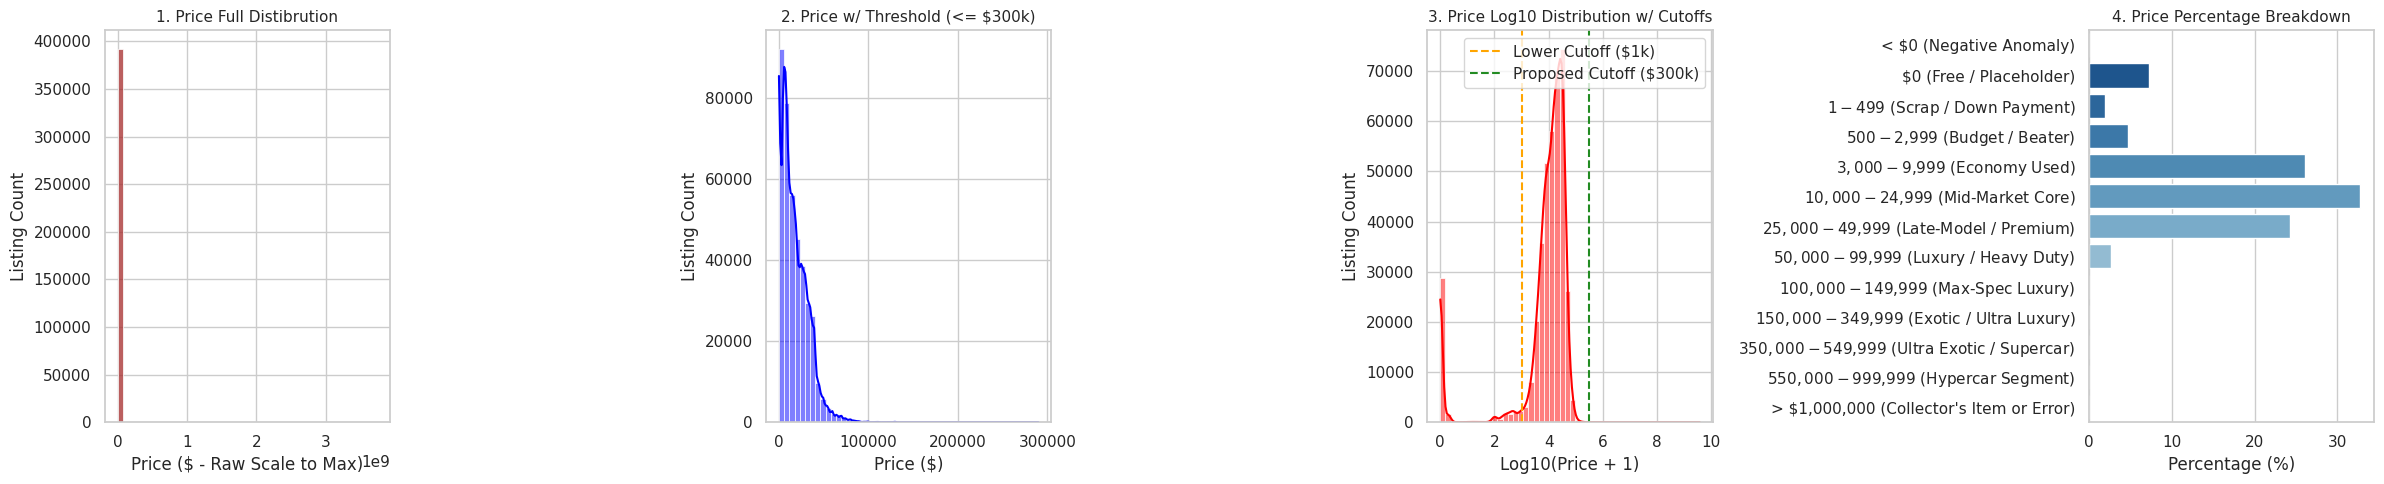

In [ ]:
sns.set_theme(style="whitegrid", palette="deep")

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

# 1. Full Distribution (Demonstrates Extreme Skew & Scale Distortion)
sns.histplot(
    data=df,
    x="price",
    bins=50,
    ax=axes[0],
    color="brown",
)
axes[0].set_title(
    "1. Price Full Distibrution", fontsize=11
)
axes[0].set_xlabel("Price ($ - Raw Scale to Max)")
axes[0].set_ylabel("Listing Count")
# Formats large numbers cleanly on x-axis
axes[0].ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))

# 2. Price Truncated Distribution (<= $300k)
sns.histplot(
    data=df[df["price"] <= 300000],
    x="price",
    bins=50,
    kde=True,
    ax=axes[1],
    color="blue",
)
axes[1].set_title("2. Price w/ Threshold (<= $300k)", fontsize=11)
axes[1].set_xlabel("Price ($)")
axes[1].set_ylabel("Listing Count")

# 3. Log10 Transformed Distribution with Proposed Cutoffs ($1k & $300k)
log_prices = np.log10(df["price"] + 1)
sns.histplot(x=log_prices, bins=50, kde=True, ax=axes[2], color="red")
axes[2].axvline(
    np.log10(1000),
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Lower Cutoff ($1k)",
)
axes[2].axvline(
    np.log10(300000),
    color="forestgreen",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Cutoff ($300k)",
)
axes[2].set_title("3. Price Log10 Distribution w/ Cutoffs", fontsize=11)
axes[2].set_xlabel("Log10(Price + 1)")
axes[2].set_ylabel("Listing Count")
axes[2].legend(loc="upper right")

# 4. Breakdown from price_summary_pre
sns.barplot(
    data=price_summary_pre,
    y="Range",
    x="Percentage (%)",
    hue="Range",
    palette="Blues_r",
    legend=False,
    ax=axes[3],
)
axes[3].set_title("4. Price Percentage Breakdown", fontsize=11)
axes[3].set_xlabel("Percentage (%)")
axes[3].set_ylabel("")

plt.tight_layout()
plt.show()

### 2.4: Visual Observations & Outlier Thresholds for `price`

Based on the distribution plots, I set the price boundary between **\$1,000 and \$300,000**. This keeps valid retail inventory while removing bad data points.

* **Raw Data Distortion (Removing Errors > \$300,000):**
  From Figure 1, it's clear that a few fake or erroneous entries with multi-million-dollar prices stretch out the scale and squeeze 99.9% of real cars into a single crowded spike on the far left causing an **extreme right skew**. Capping price at \$300,000 removes these artifacts while keeping valid high-end luxury and commercial vehicles.

* **Zoomed Retail Market (\$1,000 to \$300,000):**
  In Figure 2, restricting the view to standard dealership inventory reveals the true market shape, where the vast majority of cars sell between \$5,000 and \$35,000.

* **Log Scale Symmetry (Removing Noise < \$1,000):**
  In Figure 3, plotting price on a logarithmic scale turns the data into a clean, balanced bell curve. This clearly separates real sales from sub-\$1,000 entries (which are mostly \$0 placeholders or down-payment ads) and validates our \$1,000 minimum cutoff.




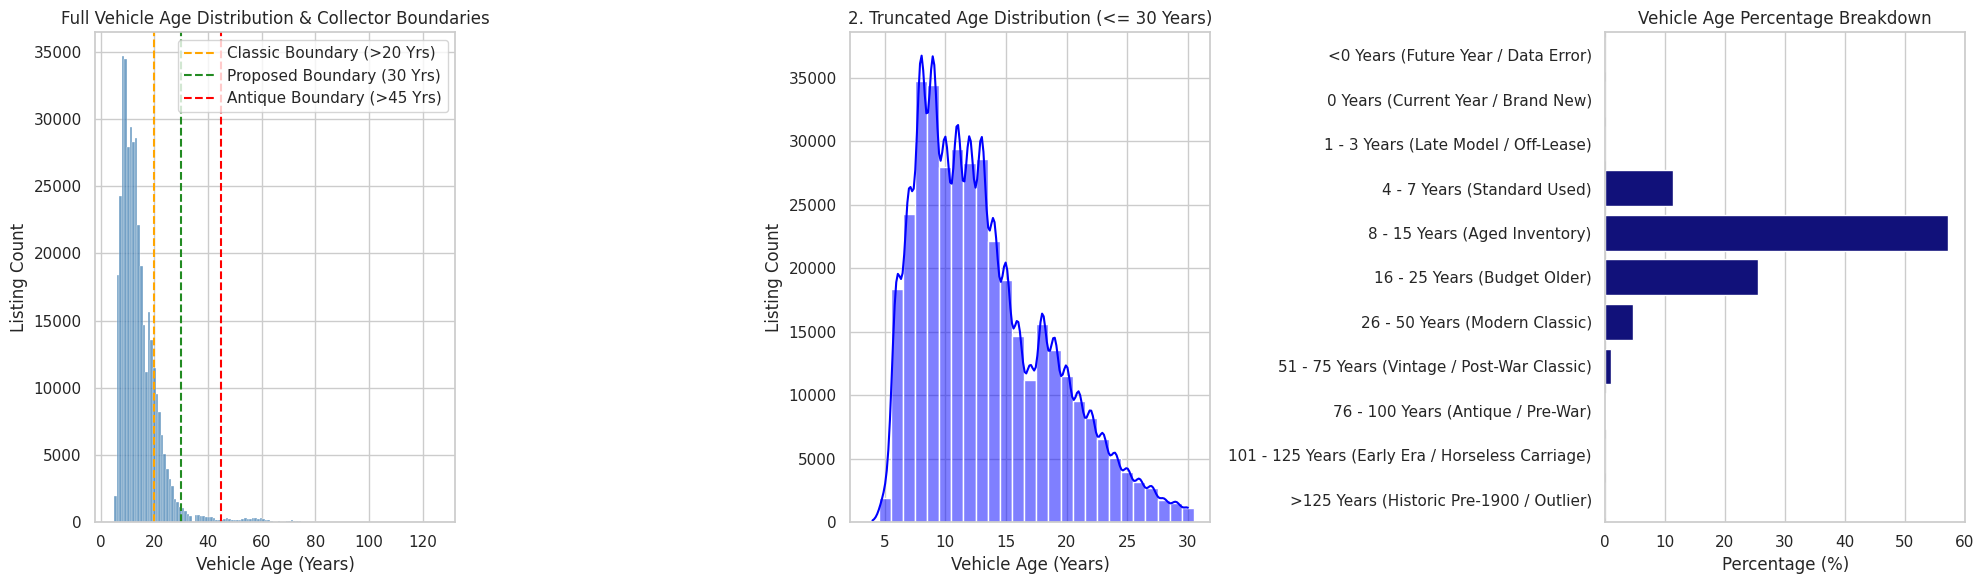

In [ ]:
# now for vehicle_age

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Full Untruncated Vehicle Age Distribution with Collector Cutoffs
sns.histplot(
    data=df,
    x="vehicle_age",
    bins=int(df["vehicle_age"].max()),
    ax=axes[0],
    color="steelblue",
)

# Overlay Collector Thresholds using standard named colors
axes[0].axvline(
    20,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Classic Boundary (>20 Yrs)",
)
axes[0].axvline(
    30,
    color="forestgreen",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Boundary (30 Yrs)",
)
axes[0].axvline(
    45,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Antique Boundary (>45 Yrs)",
)

axes[0].set_title(
    "Full Vehicle Age Distribution & Collector Boundaries", fontsize=12
)
axes[0].set_xlabel("Vehicle Age (Years)")
axes[0].set_ylabel("Listing Count")
axes[0].legend(loc="upper right")

# Truncated Age Distribution for Core Retail Inventory (<= 30 Years)
sns.histplot(
    data=df[df["vehicle_age"] <= 30],
    x="vehicle_age",
    discrete=True,
    kde=True,
    ax=axes[1],
    color="blue",
)
axes[1].set_title(
    "2. Truncated Age Distribution (<= 30 Years)", fontsize=12
)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Listing Count")

# Breakdown from age_summary_pre
sns.barplot(
    data=age_summary_pre,
    y="Range",
    x="Percentage (%)",
    color="darkblue",
    ax=axes[2],
)
axes[2].set_title("Vehicle Age Percentage Breakdown", fontsize=12)
axes[2].set_xlabel("Percentage (%)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

### 2.5: Visual Observations & Outlier Thresholds for `vehicle_age`

Based on the distribution breakdown and automotive domain standards, I set the upper operational boundary for standard retail inventory at **30 years old**.

* **Core Dealership Inventory (<= 20–25 Years):**
  Over **94%** of the dataset is concentrated between 4 and 25 years old, with the vast majority centered between 8 and 15 years (57.3%). Figure 2 shows the **right skew** matching the previous observation.  These vehicles represent standard consumer used cars that follow predictable depreciation curves.

* **Domain Industry Classifications:**
  According to [American Collectors Insurance](https://americancollectors.com/articles/vintage-vs-classic-vs-antique-cars/), older vehicles fall into three distinct collector tiers:
  * **Classic Car:** Manufactured in 2000 or earlier (>20 years old).
  * **Antique Car:** Manufactured in 1975 or earlier (>45 years old), preserved as a survivor or restored to original factory specifications.
  * **Vintage Car:** Manufactured between 1919 and 1930.

* **Domain Justification for the Cutoff:**
  As the industry source points out:
  > *"You also won’t be able to buy one at a traditional car dealer. Vintage vehicles are exceedingly hard to find and can be quite pricey."*

  Vehicles over 45 years old transition from standard depreciating transportation into scarce collector items. Because our client is a traditional retail dealership rather than a collector showroom, capping vehicle age at **30** removes non-standard (e.g. sentimental) appreciation dynamics and keeps our core valuation model accurate while retaining the bulk of the data.


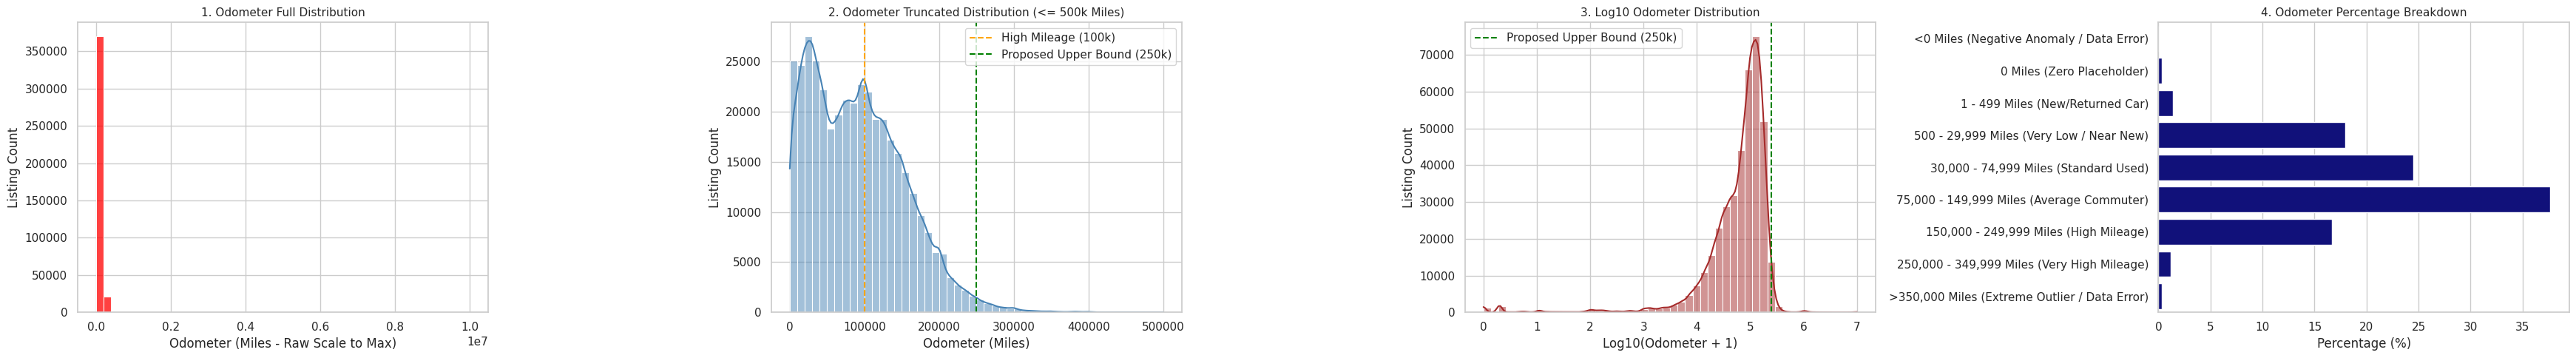

In [ ]:
# turning to odo now

fig, axes = plt.subplots(1, 4, figsize=(35, 5))

# 1. Odometer Full Distribution
sns.histplot(
    data=df,
    x="odometer",
    bins=50,
    ax=axes[0],
    color="red",
)
axes[0].set_title(
    "1. Odometer Full Distribution", fontsize=11
)
axes[0].set_xlabel("Odometer (Miles - Raw Scale to Max)")
axes[0].set_ylabel("Listing Count")
axes[0].ticklabel_format(style="scientific", axis="x", scilimits=(0, 0))

# 2. Odometer Truncated Distribution (<= 500k Miles)
sns.histplot(
    data=df[df["odometer"] <= 500_000],
    x="odometer",
    bins=50,
    kde=True,
    ax=axes[1],
    color="steelblue",
)
axes[1].axvline(
    100_000,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="High Mileage (100k)",
)
axes[1].axvline(
    250_000,
    color="green",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Upper Bound (250k)",
)
axes[1].set_title("2. Odometer Truncated Distribution (<= 500k Miles)", fontsize=11)
axes[1].set_xlabel("Odometer (Miles)")
axes[1].set_ylabel("Listing Count")
axes[1].legend(loc="upper right")

# 3. Log10 Transformed Distribution
log_odo = np.log10(df["odometer"] + 1)
sns.histplot(x=log_odo, bins=50, kde=True, ax=axes[2], color="brown")
axes[2].axvline(
    np.log10(250_000),
    color="green",
    linestyle="--",
    linewidth=1.5,
    label="Proposed Upper Bound (250k)",
)
axes[2].set_title("3. Log10 Odometer Distribution", fontsize=11)
axes[2].set_xlabel("Log10(Odometer + 1)")
axes[2].set_ylabel("Listing Count")
axes[2].legend(loc="upper left")

# 4. Breakdown from odo_summary_pre
sns.barplot(
    data=odo_summary_pre,
    y="Range",
    x="Percentage (%)",
    color="darkblue",
    ax=axes[3],
)
axes[3].set_title("4. Odometer Percentage Breakdown", fontsize=11)
axes[3].set_xlabel("Percentage (%)")
axes[3].set_ylabel("")

plt.tight_layout()
plt.show()

### 2.6: Visual Observations & Outlier Thresholds for `odometer`

Based on the distribution breakdown and visual analysis, I set the upper operational mileage boundary at **250,000 miles**, while keeping low-mileage vehicles intact.

* **Raw Data Distortion (Figure 1 - Removing Multi-Million Mile Errors):**
  The untruncated chart in Figure 1 shows extreme scraping artifacts stretching into millions of miles (e.g., 10,000,000 miles), squeezing over 99% of normal cars into a narrow vertical band. Similar to the `price` distribution, this exhibits extreme right-skew potentially caused by data entry errors.

* **Core Retail Commuter Market (Figure 2 - <= 250,000 Miles):**
  In the truncated view (Figure 2), **96%** of dealership inventory sits below 250,000 miles, with the densest cluster between 75,000 and 150,000 miles (37.6%). The bulk of commuter volume occurs up to around 200,000 miles, after which listing counts drop sharply. Capping at 250,000 miles retains the vast majority of valid retail data, as confirmed by the log-scale curve in Figure 3.

* **Retention of Low-Mileage Inventory:**
  Unlike price, where near-zero values are placeholders, low-mileage readings (including under 30,000 miles) represent valuable late-model inventory. We retain these intact.

* **High-Mileage Degradation Boundary (> 250,000 Miles):**
  Vehicles above 250,000 miles make up less than 1.5% of total listings (and less than 0.3% above 300,000 miles). Beyond 250,000 miles, mechanical reliability breaks down, engine or transmission replacements become common, and vehicle condition disconnects from standard mileage depreciation.


From this inspection, I am confident in going ahead with my thresholds for the model.

In [ ]:
initial_count = len(df)
print(f"Starting record count: {initial_count:,} (100.00%)\n")

# Outlier filtering thresholds
min_price, max_price = 1000, 300000
max_miles = 300000
max_age = 25

# Mask the dataframe using Pandas query
filtered_continuous_df = df.query(
    "@min_price <= price <= @max_price and "
    "odometer <= @max_miles and "
    "vehicle_age <= @max_age"
).copy()

# Compute retention and drop statistics
final_count = len(filtered_continuous_df)
total_dropped = initial_count - final_count
retention_pct = (final_count / initial_count) * 100.0
dropped_pct = 100.0 - retention_pct

print(
    f"Final filtered dataset: {final_count:,} records remaining "
    f"({retention_pct:.2f}% retained)"
)
print(f"Total records dropped: {total_dropped:,} ({dropped_pct:.2f}% removed)")

filtered_continuous_df.info()

Starting record count: 391,963 (100.00%)

Final filtered dataset: 329,752 records remaining (84.13% retained)
Total records dropped: 62,211 (15.87% removed)
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   model         329752 non-null  object 
 3   condition     329752 non-null  object 
 4   cylinders     329752 non-null  object 
 5   fuel          329752 non-null  object 
 6   odometer      329752 non-null  float64
 7   title_status  329752 non-null  object 
 8   transmission  329752 non-null  object 
 9   drive         329752 non-null  object 
 10  type          329752 non-null  object 
 11  state         329752 non-null  object 
 12  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 35.2+ MB


In [ ]:
# df_filtered[continuous].describe() # this showed scientific notation

# creating a cleaned copy...
desc = filtered_continuous_df[continuous].describe().copy()

# Format columns individually
# Price and odometer: standard comma-separated integers (no scientific notation)
# Vehicle age: integer formatting with no decimals
desc['price'] = desc['price'].apply(lambda x: f'{x:,.0f}')
desc['odometer'] = desc['odometer'].apply(lambda x: f'{x:,.0f}')
desc['vehicle_age'] = desc['vehicle_age'].apply(lambda x: f'{x:.0f}')

print("Descriptive Statistics (Formatted):")
print(desc)

Descriptive Statistics (Formatted):
         price vehicle_age odometer
count  329,752      329752  329,752
mean    20,060          13   90,021
std     14,537           5   60,351
min      1,000           4        0
25%      8,500           9   37,000
50%     16,990          12   85,000
75%     28,900          16  132,506
max    290,000          25  300,000


In [ ]:
filtered_continuous_parquet_path = \
  create_parquet_path('phase2_1_filtered_continuous_df')


In [ ]:
# Store the filtered continuous df for reuse
filtered_continuous_df.to_parquet(filtered_continuous_parquet_path)

In [ ]:
# Check if 'df' is already loaded in memory; if not, read from parquet
prefix = 'Previously had'
if "filtered_continuous_df" not in locals() or df is None:
  if os.path.exists(filtered_continuous_parquet_path):
    filtered_continuous_df = pd.read_parquet(filtered_continuous_parquet_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(
        f'Parquet checkpoint not found at: {filtered_continuous_parquet_path}'
      )

# Expected 329,752
print(f'{prefix} {len(filtered_continuous_df):,} cleaned records. Ready for Phase 2.2!')

df = filtered_continuous_df.copy()
df.info()


Previously had 329,752 cleaned records. Ready for Phase 2.2!
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   model         329752 non-null  object 
 3   condition     329752 non-null  object 
 4   cylinders     329752 non-null  object 
 5   fuel          329752 non-null  object 
 6   odometer      329752 non-null  float64
 7   title_status  329752 non-null  object 
 8   transmission  329752 non-null  object 
 9   drive         329752 non-null  object 
 10  type          329752 non-null  object 
 11  state         329752 non-null  object 
 12  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(10)
memory usage: 35.2+ MB


### 2.7: Summary - Continuous Outlier Filtering

Applying the verified thresholds yields the following operational dataset:
* **`price`:** Constrained to \$1,000 – \$300,000 (removing down-payment placeholders and scrap errors).
* **`odometer`:** Capped at 300,000 miles (retaining low mileage while removing multi-million mile entry errors).
* **`vehicle_age`:** Capped at 30 years (separating standard retail inventory from collector/antique dynamics).

With numerical noise filtered out, I can now proceed to bivariate analysis across the continuous variables. I want to understand the relationships between these variables alone before lookinginto the categorical ones.

From everyday experience, we know that:
* As mileage of a used car goes up, the value goes down
* As the age of the used car goes up, the value goes down
* An older car is more likely to have more miles

I expect to see these relationships rise from the data.


<Axes: >

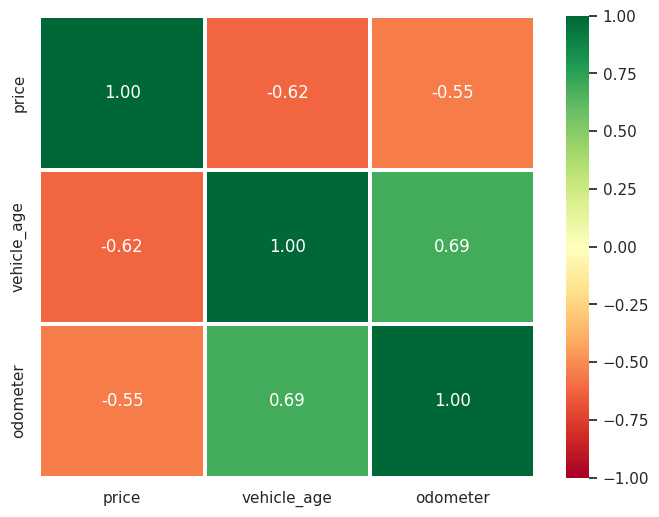

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["price", "vehicle_age", "odometer"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,  # Smoother gradient centered at zero
    linewidths=1.5,
)



### 2.8: Key Insights - Numerical Correlation Analysis

Examining the correlation matrix among `price`, `odometer`, and `vehicle_age` confirms my earlier hypotheses about how mileage and age drive vehicle depreciation:

* **Vehicle Age is the Strongest Price Driver ($r = -0.62$):**
  A vehicle's chronological age has the single largest negative impact on its price. As cars get older, buyers heavily discount them due to aging design, outdated interior tech, and loss of factory warranties.

* **Mileage Has a Strong Negative Impact ($r = -0.55$):**
  Higher mileage consistently reduces vehicle value due to mechanical wear and maintenance risk.

* **Age and Mileage Are Closely Linked ($r = +0.69$):**
  Older cars naturally have more miles on them. Because these two features share significant information, calculating an operational metric like **miles driven per year** helps isolate gently used vehicles from heavily worn commuter cars.

Therefore, the data confirms that indeed as mileage and age increase, the price value decreases. The magnitudes give me the additional information that of the two, **age** has the stronger impact on price. However, the correlation between **age** and **mileage** is stronger than either on price.

The correlation is in a moderate range and not strong. I think this may be less to do with the relationship and more to do with the fac that the correlation coefficient ($r$) assumes a straight line; the actual relationship may not be. Examining the plots should give a better story.

Instead of a simple ScatterPlot, I want to use a Seaborn `Regplot` to show an initial linear regression estimate on a sample of `odometer` and `age`.

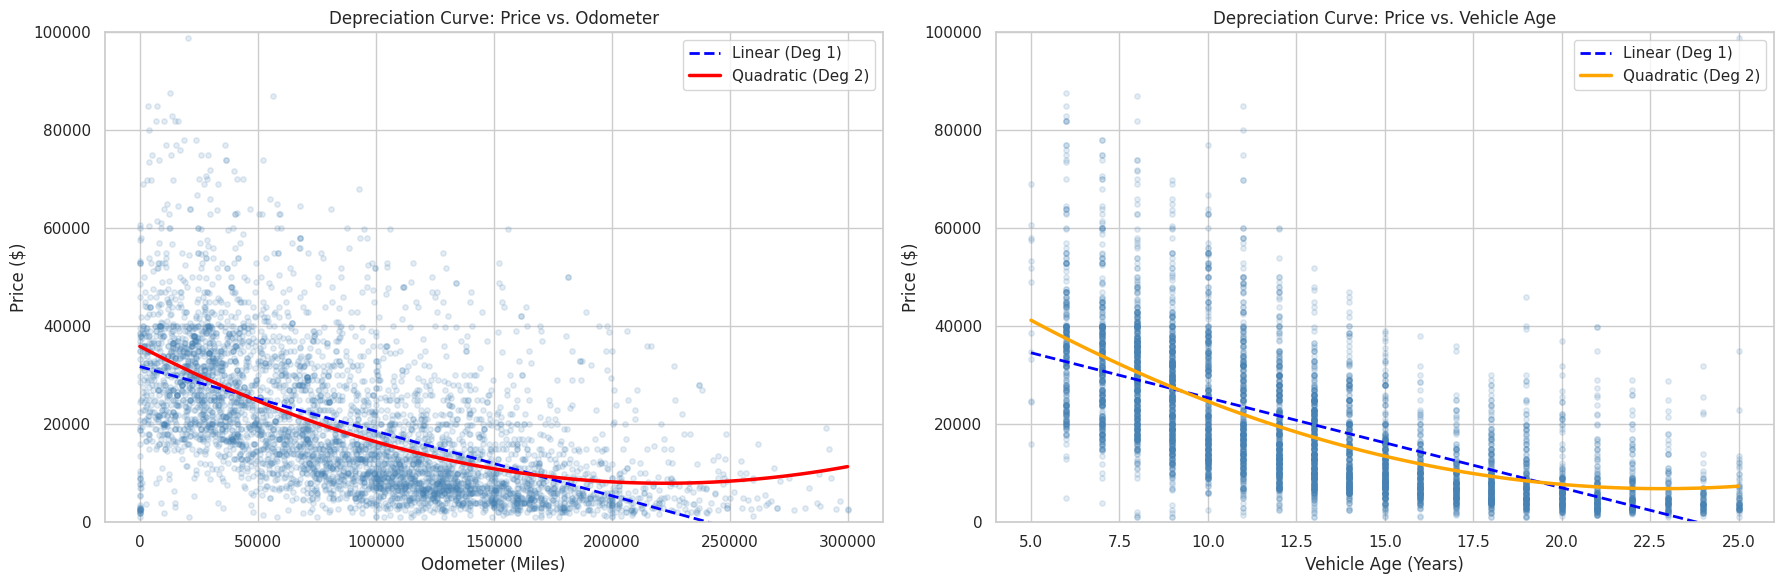

In [ ]:
sns.set_theme(style="whitegrid")

# take only a sample - full DataFrame took a long time
# use fixed seed for repeated measurements
df_plot_sample = df.sample(n=min(5000, len(df)), random_state=101)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Odometer vs Price (Degree 1 + Degree 2)

# 1a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="price",
    order=1,
    ci=None, # no replicates - just want an estimate and speeds up MASSIVELY
    # low alpha value shows overlap much better
    scatter_kws={"alpha": 0.15, "color": "steelblue", "s": 15, "rasterized": True},
    line_kws={"color": "blue", "linewidth": 2.0, "linestyle": "--", "label": "Linear (Deg 1)"},
    ax=axes[0],
)

# 1b. Overlay: Quadratic Fit (Degree 2) only
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="price",
    order=2,
    label="Quadratic (Deg 2)",
    ci=None,
    scatter=False,  # Prevents redrawing points
    line_kws={"color": "red", "linewidth": 2.5, "label": "Quadratic (Deg 2)"},
    ax=axes[0],
)

axes[0].set_title("Depreciation Curve: Price vs. Odometer", fontsize=12)
axes[0].set_xlabel("Odometer (Miles)")
axes[0].set_ylabel("Price ($)")
axes[0].set_ylim(0, 100000)
axes[0].legend(loc="upper right", frameon=True)


# Subplot 2: Vehicle Age vs Price (Degree 1 + Degree 2)

# 2a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="price",
    order=1,
    ci=None,
    # keeping the alpha low shows overlap much better
    scatter_kws={"alpha": 0.15, "color": "steelblue", "s": 15, "rasterized": True},
    line_kws={"color": "blue", "linewidth": 2.0, "linestyle": "--", "label": "Linear (Deg 1)"},
    ax=axes[1],
)

# 2b. Overlay: Quadratic Fit (Degree 2) only
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="price",
    order=2,
    ci=None,
    label="Quadratic (Deg 2)",
    scatter=False,  # Prevents redrawing points
    line_kws={"color": "orange", "linewidth": 2.5, "label": "Quadratic (Deg 2)"},
    ax=axes[1],
)

axes[1].set_title("Depreciation Curve: Price vs. Vehicle Age", fontsize=12)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Price ($)")
axes[1].set_ylim(0, 100000)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


Both plots show that while a linear model predicts impossible negative car prices at high mileage and age, a quadratic model captures the initial depreciation curve better but introduces an unrealistic upward price turn at the extremes.

Ultimately, neither polynomial curve accurately reflects real-world market logic across the entire data range. From earlier, I had shown that price and odometer were **right skewed** so a `log` version of these plots might help.

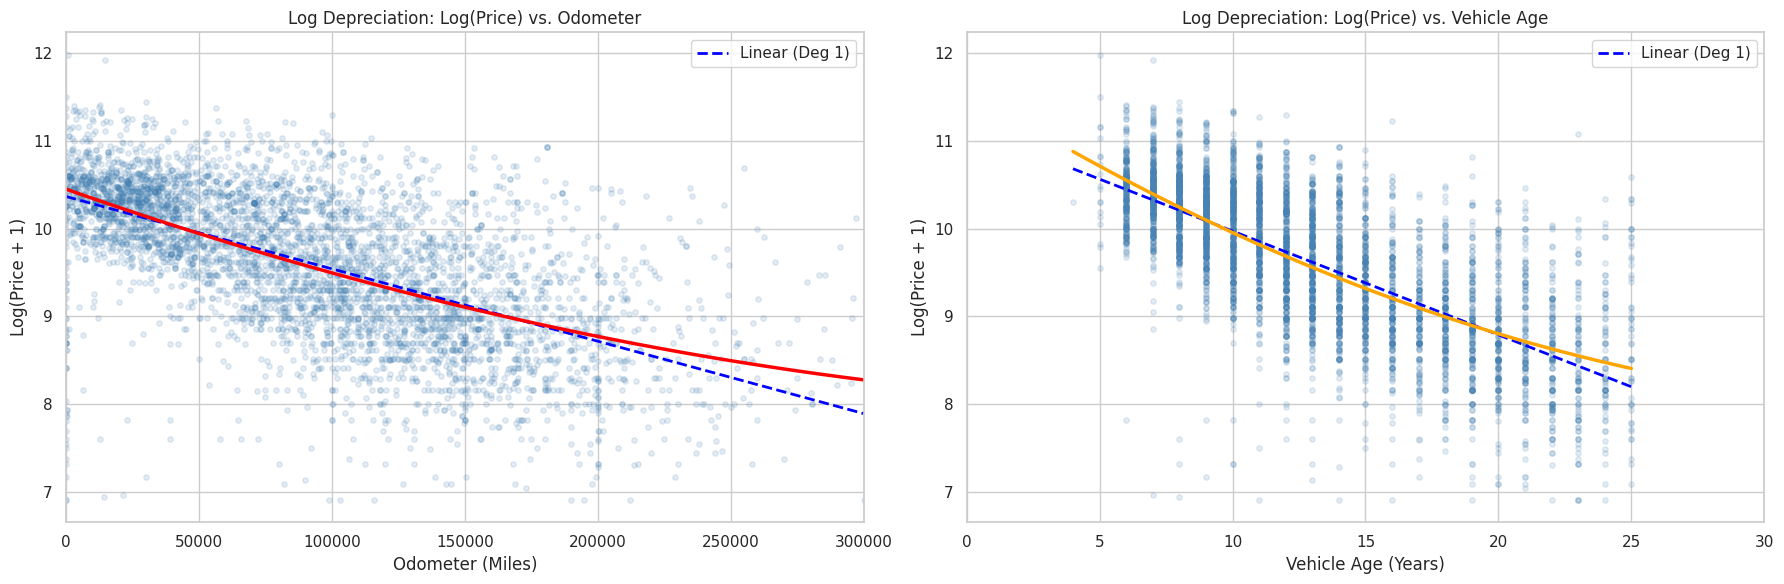

In [ ]:
sns.set_theme(style="whitegrid")

# Sample subset and compute log-transformed price
df_plot_sample = df.sample(n=min(5000, len(df)), random_state=102).copy()
df_plot_sample["log_price"] = np.log1p(df_plot_sample["price"])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Odometer vs Log Price (Degree 1 + Degree 2)

# 1a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="log_price",
    order=1,
    ci=None,  # Fast computation
    scatter_kws={
        "alpha": 0.15,
        "color": "steelblue",
        "s": 15,
        "rasterized": True,
    },
    line_kws={
        "color": "blue",
        "linewidth": 2.0,
        "linestyle": "--",
        "label": "Linear (Deg 1)",
    },
    ax=axes[0],
)

# 1b. Overlay: Quadratic Fit (Degree 2)
sns.regplot(
    data=df_plot_sample,
    x="odometer",
    y="log_price",
    order=2,
    ci=None,
    scatter=False,  # Prevents redrawing scatter points
    line_kws={"color": "red", "linewidth": 2.5, "label": "Quadratic (Deg 2)"},
    ax=axes[0],
)

axes[0].set_title("Log Depreciation: Log(Price) vs. Odometer", fontsize=12)
axes[0].set_xlabel("Odometer (Miles)")
axes[0].set_ylabel("Log(Price + 1)")
axes[0].set_xlim(0, 300000)
axes[0].legend(loc="upper right", frameon=True)


# Subplot 2: Vehicle Age vs Log Price (Degree 1 + Degree 2)

# 2a. Base Layer: Scatter points + Linear Fit (Degree 1)
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="log_price",
    order=1,
    ci=None,
    scatter_kws={
        "alpha": 0.15,
        "color": "steelblue",
        "s": 15,
        "rasterized": True,
    },
    line_kws={
        "color": "blue",
        "linewidth": 2.0,
        "linestyle": "--",
        "label": "Linear (Deg 1)",
    },
    ax=axes[1],
)

# 2b. Overlay: Quadratic Fit (Degree 2)
sns.regplot(
    data=df_plot_sample,
    x="vehicle_age",
    y="log_price",
    order=2,
    ci=None,
    scatter=False,  # Prevents redrawing scatter points
    line_kws={
        "color": "orange",
        "linewidth": 2.5,
        "label": "Quadratic (Deg 2)",
    },
    ax=axes[1],
)

axes[1].set_title("Log Depreciation: Log(Price) vs. Vehicle Age", fontsize=12)
axes[1].set_xlabel("Vehicle Age (Years)")
axes[1].set_ylabel("Log(Price + 1)")
axes[1].set_xlim(0, 30)
axes[1].legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

### 2.9: Depreciation Curves - Log-Linear Decay Analysis & Modeling Choice

* **Predictable Percentage Drop:**
  In log-space, both mileage and vehicle age show steady downward slopes. This confirms that used cars naturally lose a predictable percentage of their value each year and for every 10,000 miles driven, rather than a fixed dollar amount across all price tiers.

* **Linear vs. Quadratic Relationships:**
  - **Mileage (`odometer`):** The Linear (Degree 1) and Quadratic (Degree 2) trendlines almost completely overlap, showing that mileage depreciation is well-behaved and steady.
  - **Age (`vehicle_age`):** The slight curve in Degree 2 captures the steeper loss in value during the first 1–5 years before leveling out as the car reaches standard commuter age.


**However**, my primary objective is to give the dealership direct, actionable business numbers (for example: *"each additional 10,000 miles reduces inventory value by \$X"* or *"an extra year of age discounts price by \$Y"*). Because flat dollar adjustments are significantly easier for sales managers to apply than compounding percentage formulas, I will **train the primary regression models on raw `price`**.

I will document log-price transformations and elasticity models as recommended next steps for advanced valuation tooling in the conclusion.


### 2.10: Categorical Feature Exploration & Valuation Drivers

Vehicle pricing is not driven by mileage and age alone; discrete vehicle attributes—such as drive train, fuel type, vehicle condition, and body style—also dictate consumer demand and price premiums.

In this step, I explore our categorical variables (`drive`, `fuel`, `condition`, `title_status`, `transmission`, `type`, `cylinders`, and `manufacturer`) against `price`.

Analyzing these distributions will help me identify:
1. **Class Distributions & Rare Categories:** Which attributes dominate dealership inventory versus rare segments that may require grouping.
2. **Pricing Hierarchies & Premiums:** How median listing prices shift across discrete categories (e.g., the dollar premium of 4WD over FWD, or clean titles over salvage titles).
3. **Encoding Readiness:** How best to prepare these categories for linear modeling (One-Hot Encoding vs. Target/Frequency Encoding).

In [ ]:
df.select_dtypes(include="object").info()


<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   manufacturer  329752 non-null  object
 1   model         329752 non-null  object
 2   condition     329752 non-null  object
 3   cylinders     329752 non-null  object
 4   fuel          329752 non-null  object
 5   title_status  329752 non-null  object
 6   transmission  329752 non-null  object
 7   drive         329752 non-null  object
 8   type          329752 non-null  object
 9   state         329752 non-null  object
dtypes: object(10)
memory usage: 27.7+ MB


In [ ]:
# store the columns
cat_cols = df.select_dtypes(include="object").columns.tolist()
# should contain model!
cat_cols

['manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'state']

### 2.11: Profiling Categorical Cardinality and Class Balance

When examining these features, I would like to know the following:

1. **Feature Cardinality i.e. Unique Value Count:**
   I need to know how many distinct categories exist in each column. From before, I have seen that a low-cardinality feature like `drive` (4 values) can be safely one-hot encoded; on the other hand, a high-cardinality feature like `model` (thousands of trims) could drastically expand our feature space and lead to model overfitting

2. **Identifying Dominant Values/Imbalances:**
   By measuring the most frequent category (`Mode`) and its overall market share (`Top Mode Share %`), I can spot **heavily skewed** features, just as was shown for our continuous features.
   
   For instance, knowing whether `title_status` is overwhelmingly clean or whether `fuel` is dominated by gas helps me decide whether minority classes have enough volume to provide statistically reliable pricing signals.

From these results, I would understand how to segment the categorical features:
   * **Low-cardinality attributes** these can be directly visualized with 100% complete category breakdowns.
   * **High-cardinality attributes** (`manufacturer`, `state`, `model`) may require other strategies; utitlizing the top-N values or some kind of target mapping. I have one in mind already for the `state` which I will show when examining that feature.

In [ ]:
summary_data = []
total_records = len(df)

for col in cat_cols:
  val_counts = df[col].value_counts()
  n_unique = df[col].nunique()
  top_cat = val_counts.index[0]
  top_count = val_counts.iloc[0]
  top_pct = (top_count / total_records) * 100.0

  summary_data.append({
      "Feature": col,
      "Cardinality": n_unique,
      "Top Category (Mode)": top_cat,
      "Top Mode Count": f"{top_count:,}",
      "Top Mode Share (%)": f"{top_pct:.2f}%",
  })

cat_summary_df = (
    pd.DataFrame(summary_data)
    .sort_values(by="Cardinality")
    .reset_index(drop=True)
)

print(f"Categorical Features Summary (Total Clean Records: {total_records:,}):")
print(cat_summary_df.to_string(index=False))

Categorical Features Summary (Total Clean Records: 329,752):
     Feature  Cardinality Top Category (Mode) Top Mode Count Top Mode Share (%)
transmission            3           automatic        258,656             78.44%
title_status            4               clean        318,897             96.71%
       drive            4                 4wd        142,450             43.20%
        fuel            5                 gas        277,699             84.21%
   condition            7               other        127,433             38.65%
   cylinders            8         6 cylinders        114,297             34.66%
        type           12               sedan         87,570             26.56%
manufacturer           40                ford         55,828             16.93%
       state           51                  ca         36,076             10.94%
       model        18029               f-150          6,430              1.95%


### 2.12: Summary - Categorical Cardinality & Feature Segmentation

Analyzing the cardinality and mode distribution across all 10 categorical attributes reveals three distinct feature tiers:

1. **Closed Low-Cardinality Features (3 to 12 Levels):**
   * Attributes like `transmission` (78.4% automatic), `title_status` (96.7% clean), `fuel` (84.2% gas), `drive`, `condition`, `cylinders`, and `type` have small, well-defined sets of data
   * **Action:** Fully suitable for standard **One-Hot Encoding** without risk of dimensional explosion.

2. **Medium-Cardinality Attributes (40 to 51 Levels):**
   * `manufacturer` (40 makes, led by Ford at 16.9%) and `state` (51 states, led by CA at 10.9%) represent structured geographic and brand dimensions.
   * **Action:** Try to slice based on trends in the data or fall back on One-Hot encoding if we need to preserve all the data

3. **Extreme-Cardinality Feature (`model` - 18,029 Trims):**
   * Even the single most common model (`f-150`) accounts for less than 2% of total inventory. One-Hot Encoding would be very impractical for ~18k distinct values but top-N would not capture enough of the data. A more radical plan is required for this.


### 2.13: Feature Selection: Managing High-Cardinality Vehicle `model`

I've opted to handle the highest-cardinality feature first.

From earlier exploration, I noted two key issues with `model`:
* **Scraping Inconsistencies & Free-Text Noise:** As observed during data cleanup, raw model names contain arbitrary trim labels, package variations, and typos. For example, a Ford F-150 might appear as `f150`, `f-150 supercrew`, or `f-150 xlt`. Having already leveraged `model` during Phase 1 hierarchical imputation to recover missing mechanical attributes, the raw text column now introduces redundant noise.
* **Dimensionality Explosion:** Naively one-hot encoding `model` would inject over **18,000 sparse binary columns** into our feature matrix, risking severe overfitting and memory bloat.

Therefore, I have decided to **drop raw `model` text** for our baseline regression models. My automotive domain logic confirms that the combination of `manufacturer`, `type` (body style), `cylinders`, `fuel`, and `drive` already reconstructs the core functional profile of the vehicle (e.g., a Ford 8-cylinder 4WD truck).

**Trade-offs and Edge Cases:**
* **Model-Specific Brand Equity:** For certain high-end performance or luxury vehicles, the model name carries significant pricing power on its own (e.g., a Ferrari F40 vs. a Ferrari 458, or a Chevrolet Corvette).
* **Intra-Brand Hierarchy:** Certain manufacturers exhibit wide price variation within the same body type (e.g., a base Porsche Boxster vs. a Porsche 911 GT3 RS, despite both being categorized as "coupes").

Because our operational dataset is already bounded between \$1,000 and \$300,000, these extreme collector variations represent a minimal fraction of inventory. Dropping `model` preserves generalizability, and keeps our model interpretable for dealership decision-makers while reducing the feature space frm 18,000 → just **121** types (and 1 `other`). Still, it's important to keep it in mind since it will give boundaries for the models I will generate.


In [ ]:
# Drop high-cardinality model column
df = df.drop(columns=["model"])

print(f"Updated DataFrame shape: {df.shape}")
print(f"Remaining categorical columns ({df.select_dtypes(include='object').shape[1]} total):")
print(df.select_dtypes(include="object").columns.tolist())


Updated DataFrame shape: (329752, 12)
Remaining categorical columns (9 total):
['manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'state']


### 2.14: Exploring medium-sized categorical features - `state`

I now examine the medium-sized categorical features, starting with `state` to explore geographic inventory distribution and regional price variations.

In [ ]:
# State metrics
state_summary = (
    df.groupby("state")
    .agg(
        listing_count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
    )
    .reset_index()
    .sort_values(by="median_price", ascending=False)
)
print(f'Top 5 (Price):\n{state_summary.head()}')
print(f'\nBottom 5 (Price): \n{state_summary.tail()}')


Top 5 (Price):
   state  listing_count  median_price    mean_price
49    wv            874       26990.0  26219.360412
47    wa           9756       24988.0  28485.585281
26    mt           4997       23998.0  25853.225335
0     ak           3133       22999.0  24969.000319
50    wy            453       21999.0  23638.938190

Bottom 5 (Price): 
   state  listing_count  median_price    mean_price
22    mi          13779       12500.0  16851.863851
31    nj           8175       12500.0  15984.341284
39    ri           1878       11995.0  15961.217785
6     ct           4235       11495.0  15834.114050
8     de            754       10499.5  16885.827586


I could use a barplot, but since this is geographical data, it would also be interesting to view on a map.

In [ ]:
# Uppercase state codes for Plotly US map compatibility
state_summary["state_upper"] = state_summary["state"].str.upper()

# 2. Render Choropleth Map (Median Price by State)
fig = px.choropleth(
    state_summary,
    locations="state_upper",
    locationmode="USA-states",
    color="median_price",
    scope="usa",
    color_continuous_scale="Viridis",
    labels={
        "median_price": "Median Price ($)",
        "listing_count": "Listings",
        "state_upper": "State",
    },
    hover_data={"state_upper": True, "median_price": ":$,.0f", "listing_count": ":,"},
    title="Geographic Price Distribution: Median Car Price by State",
)

fig.update_layout(
    geo=dict(lakecolor="white"),
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()

### 2.15: Visual Observations & Insights: Geographic State Distribution

Some interesting observations come up from the top 5 and bottom 5 metrics, and the map view:

* **Top Valuation States (Mountain West, Pacific Northwest, & Rural Hubs):**
  West Virginia (\$26,990), Washington (\$24,988), Montana (\$23,998), Alaska (\$22,999), and Wyoming (\$21,999) command the highest median prices. Could this be because these rural/mountainous areas require a certain type of vehicle, like a truck, making the average price higher?

* **Lower Valuation States (Rust Belt & Dense Northeast Metro):**
  The Northeast and Midwest—including Delaware (\$10,500), Connecticut (\$11,495), Michigan (\$12,500), and New Jersey (\$12,500)—exhibit the lowest median prices.

* **Inventory Volume Drivers:**
  Four major states (California, Florida, Texas, and New York) account for over **28% of all listings**

**Key Takeaway:**
Vehicle location is **strongly correlated** with body type demand (and therefore **price**): dealerships in Mountain and Pacific Northwest regions command significant price premiums driven by 4WD utility demand, whereas Northeast/Midwest inventories trade at relative discounts. I can verify this by examining the `type` feature combined with the `state` information.


In [ ]:
# define geo slices
mountain_nw_states = ["wv", "wa", "mt", "ak", "wy"]
low_price_states = ["de", "ct", "ri", "mi", "nj"]

df_geo_slices= df[df["state"].isin(mountain_nw_states + low_price_states)].copy()
df_geo_slices["geo_slice"] = df_geo_slices["state"].apply(
    lambda s: (
        "Mountain / Pacific NW (High Price)"
        if s in mountain_nw_states
        else "Northeast / Rust Belt (Low Price)"
    )
)
df_geo_slices.head(3)

,price,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,state,vehicle_age,geo_slice
4464,55000,ford,excellent,8 cylinders,diesel,167000.0,clean,automatic,4wd,truck,ak,13.0,Mountain / Pacific NW (High Price)
4465,46194,ram,other,8 cylinders,gas,9814.0,clean,automatic,4wd,truck,ak,6.0,Mountain / Pacific NW (High Price)
4466,26194,hyundai,other,4 cylinders,gas,12093.0,clean,other,4wd,suv,ak,7.0,Mountain / Pacific NW (High Price)


In [ ]:
prices_by_geo_type = (
    df_geo_slices.groupby(["geo_slice", "type"], observed=True)
    .agg(
        count=("price", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
    .reset_index()
).sort_values(by="median_price", ascending=False)

print(prices_by_geo_type)

                             geo_slice         type  count  median_price  \
9   Mountain / Pacific NW (High Price)        truck   6594       37995.0   
5   Mountain / Pacific NW (High Price)      offroad     24       26495.0   
6   Mountain / Pacific NW (High Price)        other    563       25998.0   
2   Mountain / Pacific NW (High Price)        coupe    591       24990.0   
14   Northeast / Rust Belt (Low Price)        coupe   1183       24900.0   
18   Northeast / Rust Belt (Low Price)        other   2022       22985.0   
1   Mountain / Pacific NW (High Price)  convertible    206       22495.0   
21   Northeast / Rust Belt (Low Price)        truck   5104       22200.0   
8   Mountain / Pacific NW (High Price)          suv   5686       21999.0   
12   Northeast / Rust Belt (Low Price)          bus     40       20600.0   
10  Mountain / Pacific NW (High Price)          van    274       17797.0   
17   Northeast / Rust Belt (Low Price)      offroad     18       15500.0   
13   Northea

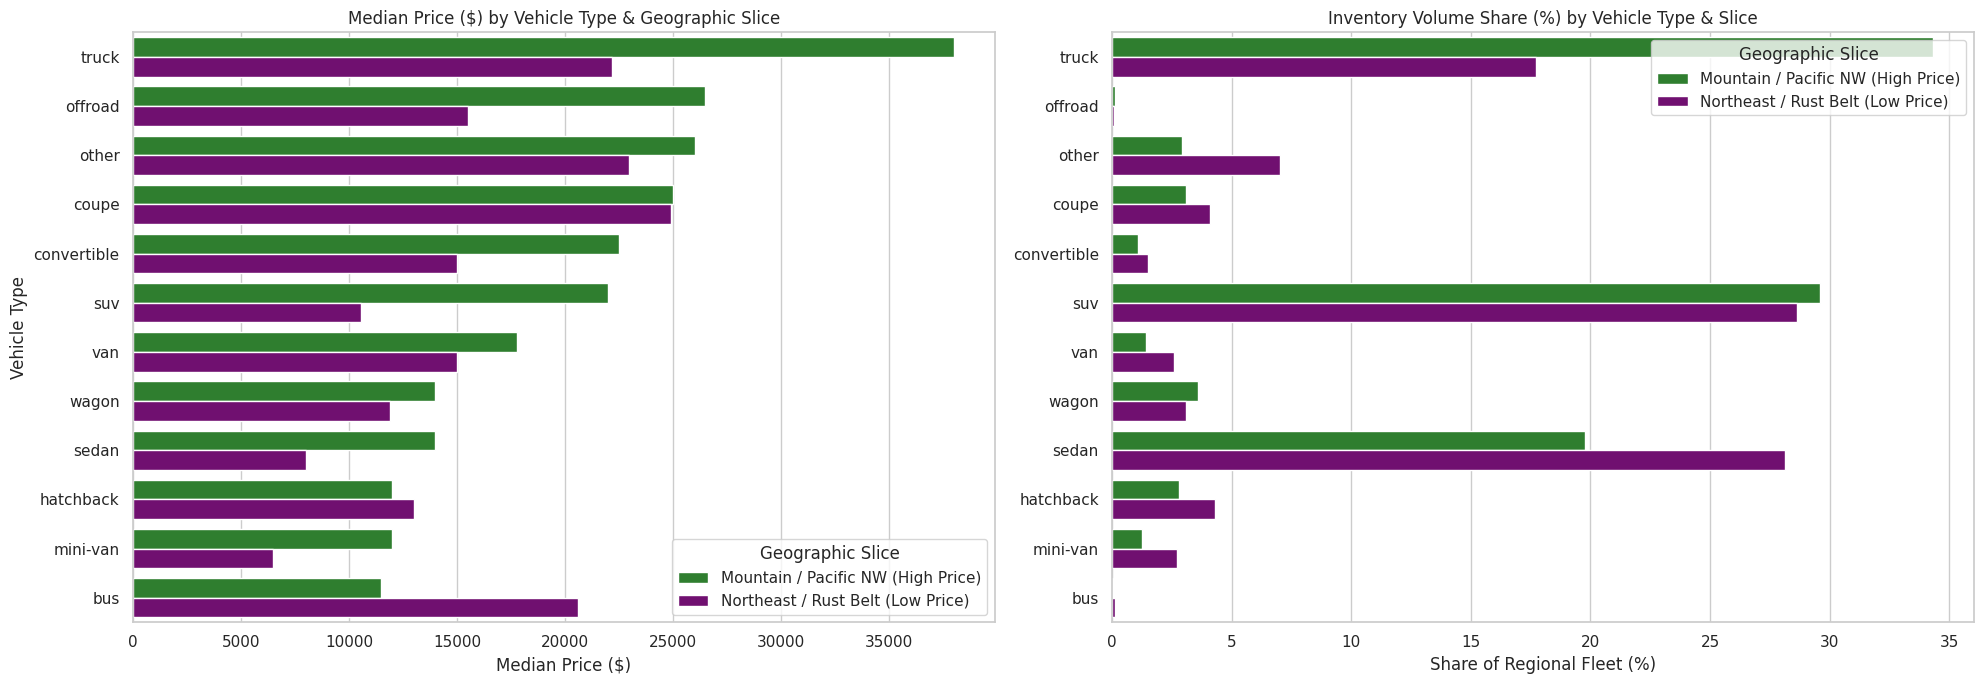

In [ ]:
# Visualize
sns.set_theme(style="whitegrid")

# 1. Compute percentage share of volume within each regional slice
prices_by_geo_type["pct_within_geo"] = prices_by_geo_type.groupby("geo_slice")[
    "count"
].transform(lambda x: (x / x.sum()) * 100)

# 2. Determine sorted order of vehicle types based on Mountain median price
mountain_label = "Mountain / Pacific NW (High Price)"
order_types = (
    prices_by_geo_type[prices_by_geo_type["geo_slice"] == mountain_label]
    .sort_values(by="median_price", ascending=False)["type"]
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Median Price Comparison by Vehicle Type ($)
sns.barplot(
    data=prices_by_geo_type,
    y="type",
    x="median_price",
    hue="geo_slice",
    order=order_types,
    palette=["forestgreen", "purple"],
    ax=axes[0],
)
axes[0].set_title(
    "Median Price ($) by Vehicle Type & Geographic Slice", fontsize=12
)
axes[0].set_xlabel("Median Price ($)")
axes[0].set_ylabel("Vehicle Type")
axes[0].legend(title="Geographic Slice", loc="lower right")

# Plot 2: Inventory Share (%) by Vehicle Type
sns.barplot(
    data=prices_by_geo_type,
    y="type",
    x="pct_within_geo",
    hue="geo_slice",
    order=order_types,
    palette=["forestgreen", "purple"],
    ax=axes[1],
)
axes[1].set_title(
    "Inventory Volume Share (%) by Vehicle Type & Slice", fontsize=12
)
axes[1].set_xlabel("Share of Regional Fleet (%)")
axes[1].set_ylabel("")
axes[1].legend(title="Geographic Slice", loc="upper right")

plt.tight_layout()
plt.show()


### 2.16: Insights - Geographic State & Body Type Relationships

Cross-tabulating `state` against vehicle `type` and `drive` **confirms** the driver of state-level price variation:

* **Utility Demand in High-Valuation States:**
  States with the highest median prices (`WV`, `WA`, `MT`, `AK`, `WY`) have a significantly higher share of **4WD pickup trucks and full-size utility vehicles** due to mountainous terrain and winter climates.
* **Commuter Density in Low-Valuation States:**
  Lower-valuation states in the Northeast and Mid-Atlantic (`DE`, `CT`, `RI`, `NJ`) have a higher volume of **front-wheel-drive sedans and hatchbacks**, which naturally trade at lower price points.


My initial plan was to group the `state`s either from the data or from known labels like "north-east", "mid-west", "bible-belt", "pacific"; looking at the data and seeing the more granular impact of states on price, I think it is better to perform **one-hot encoding** for all the states. ~50 values should be feasible for the output model.

Outside of heavy-duty trucks and off-road vehicles, vehicle pricing across general body types (such as coupes and sedans) remains relatively uniform nationwide. Broad macro-groupings could obscure state-specific demand without the advantage of commonality between the groupings.


### 2.17:  Examining `manufacturer`

This section will be brief - from experience, I am very confident that manufacturer is a major driver of price. There are budget brands, entry-level luxury, luxury and ultra luxury and I can think of several examples of each like Ford → Genesis → BMW → Bentley → Ferrari. I expect the data to clearly show price difference based on manufacturer, confirming that it is important to keep this feature.

In [ ]:
# Aggregate median price across all 40 manufacturers
make_stats = (
    df.groupby("manufacturer")
    .agg(
        median_price=("price", "median"),
        count=("price", "count"),
    )
    .sort_values(by="median_price") # I want to show lowest → Highest this time
    .reset_index()
)
make_stats.head()

,manufacturer,median_price,count
0,pontiac,4495.0,1537
1,saturn,4495.0,955
2,mercury,4500.0,709
3,land rover,7000.0,9
4,chrysler,8500.0,5018


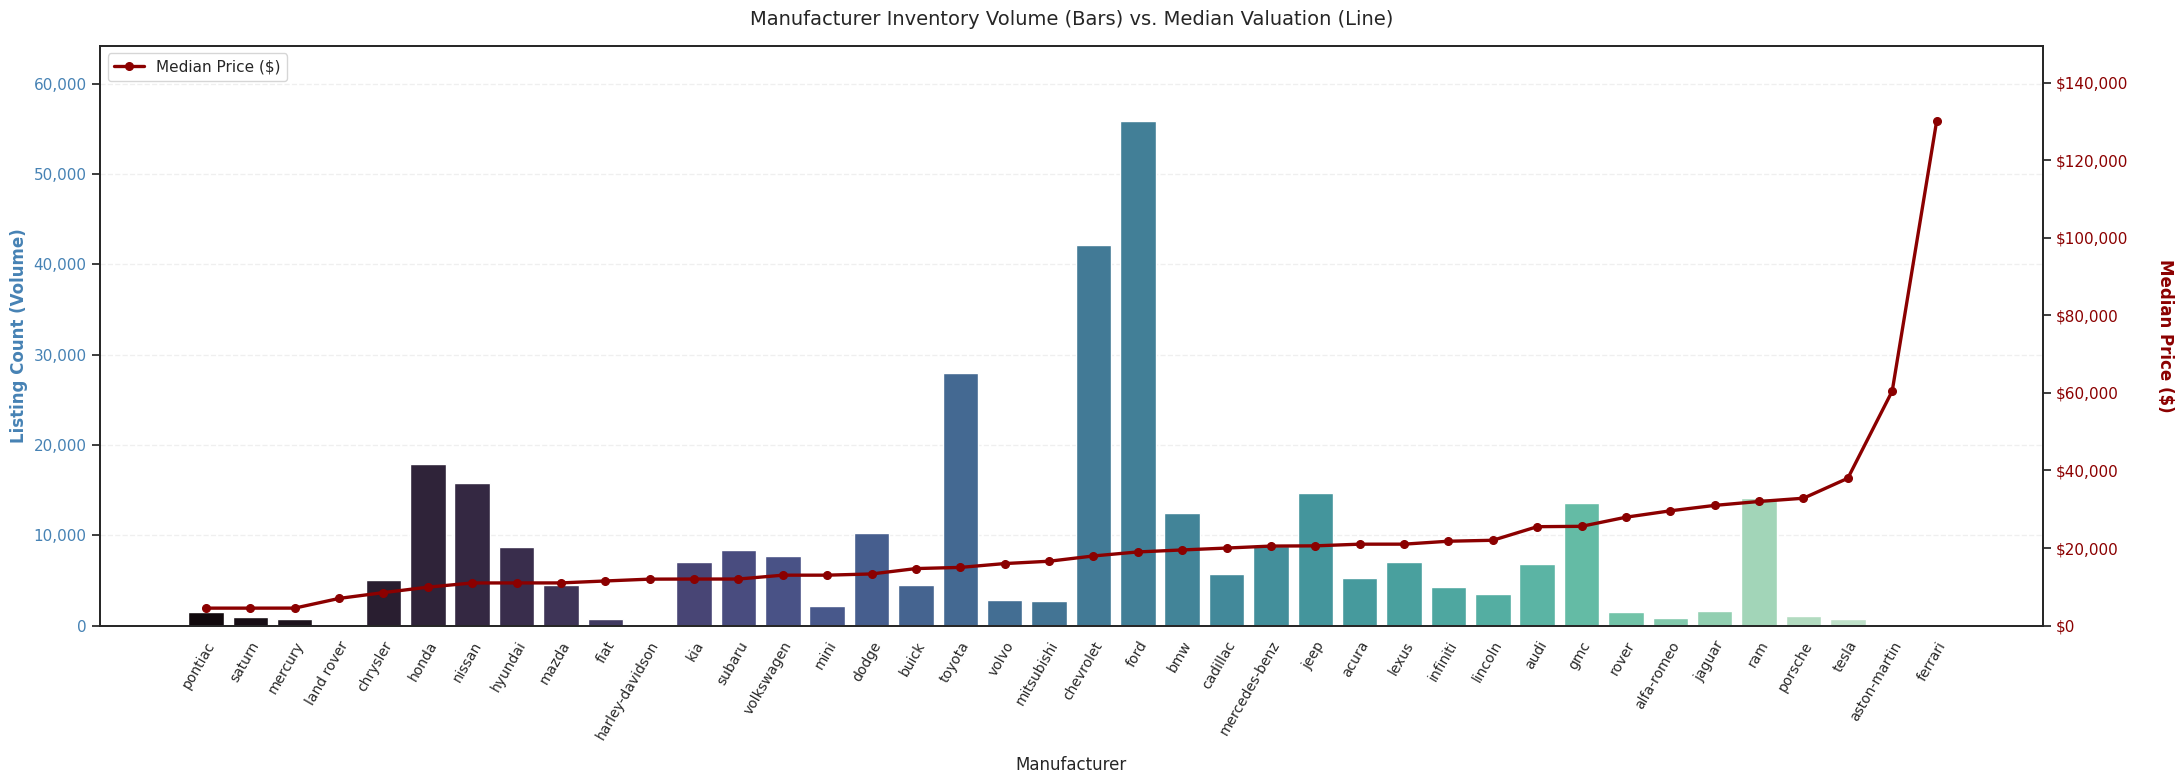

In [ ]:
sns.set_theme(style="white")

# 1. Aggregate and sort by median price from LOWEST to HIGHEST (ascending)
make_stats = (
    df.groupby("manufacturer")
    .agg(
        median_price=("price", "median"),
        count=("price", "count"),
    )
    .sort_values(by="median_price", ascending=True)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(22, 8))

# 2. Primary Left Axis: Volume Bars with Gradient Palette (e.g. "Blues", "viridis", or "mako")
# Because make_stats is sorted ascending, "Blues" shades from light/medium blue to deep dark blue
sns.barplot(
    data=make_stats,
    x="manufacturer",
    y="count",
    hue="manufacturer",
    palette="mako",
    legend=False,
    ax=ax1,
)

ax1.set_ylabel(
    "Listing Count (Volume)", fontsize=12, fontweight="bold", color="steelblue"
)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.yaxis.set_major_formatter("{x:,.0f}")
ax1.set_ylim(0, make_stats["count"].max() * 1.15)
ax1.set_xlabel("Manufacturer", fontsize=12, labelpad=10)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# 3. Warning-Free Fixed X-Axis Ticks & Slanted Labels
ax1.set_xticks(
    ticks=range(len(make_stats)),
    labels=make_stats["manufacturer"],
    rotation=60,
    ha="right",
    va="top",
    rotation_mode="anchor",
    fontsize=10,
)

# 4. Secondary Right Axis: Red Median Price Line (Rising from Left to Right)
ax2 = ax1.twinx()
ax2.plot(
    np.arange(len(make_stats)),
    make_stats["median_price"],
    color="darkred",
    marker="o",
    linewidth=2.4,
    markersize=5.5,
    linestyle="-",
    label="Median Price ($)",
)

# Set right y-label in matching red and rotated (-90°)
ax2.set_ylabel(
    "Median Price ($)",
    fontsize=12,
    fontweight="bold",
    color="darkred",
    rotation=-90,
    va="bottom",
    labelpad=20,
)
ax2.tick_params(axis="y", labelcolor="darkred")
ax2.yaxis.set_major_formatter("${x:,.0f}")
ax2.set_ylim(0, make_stats["median_price"].max() * 1.15)
ax2.grid(False)

# 5. Legend
ax2.legend(loc="upper left", frameon=True)

plt.title(
    "Manufacturer Inventory Volume (Bars) vs. Median Valuation (Line)",
    fontsize=14,
    pad=15,
)

plt.tight_layout()
plt.show()


### 2.18:  Insights - Manufacturer Brand & Pricing

* **Core Volume Leaders:** Mainstream brands make up over 55% of total inventory, with listing volume peaking sharply at Ford (55.8k), Chevrolet (42.1k), and Toyota (28.0k) in the \$15,000–\$19,000 median price range.
* **High-Margin Volume:** Utility brands like RAM (14.1k listings, \$31,999 median) and GMC (13.6k listings, \$25,590 median) offer the strongest combination of high retail volume and premium prices.
* **Economy & Discontinued Brands:** Defunct brands such as Pontiac (\$4,495), Saturn (\$4,495), and Mercury (\$4,500) sit at the lowest price points with low volume (<1.5k listings each).
* **Low-Volume Exotics:** High-end brands like Aston Martin (\$60,475) and Ferrari (\$129,995) top the pricing scale but represent fewer than 50 listings each.

As expected, `manufacturer` shows distinct pricing power across all 40 categories, so I will retain the column as-is and one-hot encode it directly in Phase 3.


### 2.19:  Examining Low-Cardinality Categorical Features

Last, I inspect the 7 low-cardinality features to verify that each has enough category variation **with enough volume** to include in our regression model as-is rather than dropping or merging them.


In [ ]:
# I had already shown a breakdown above in Phase 1, repeating for convenience
# with slightly differnet formatting

low_card_features = [
    "title_status",
    "fuel",
    "drive",
    "transmission",
    "condition",
    "cylinders",
    "type",
]

# Compute aggregation statistics per feature
low_card_summary = {}

for col in low_card_features:
  summary = (
      df.groupby(col)
      .agg(
          listing_count=("price", "count"),
          median_price=("price", "median"),
          mean_price=("price", "mean"),
      )
      .assign(
          volume_pct=lambda d: (d["listing_count"] / len(df)) * 100.0
      )
      .sort_values(by="median_price", ascending=False)
      .reset_index()
  )
  low_card_summary[col] = summary
  print(f"Summary for {col}:")
  print(summary.head())
  print("\n")




Summary for title_status:
  title_status  listing_count  median_price    mean_price  volume_pct
0         lien           1252       18250.0  22729.454473    0.379679
1        clean         318897       16995.0  20282.846753   96.708132
2      rebuilt           6470       10700.0  13029.590572    1.962081
3      salvage           3133        8000.0  10784.096393    0.950108


Summary for fuel:
       fuel  listing_count  median_price    mean_price  volume_pct
0    diesel          19332       35995.0  37536.554469    5.862588
1     other          26661       27590.0  27910.197742    8.085167
2  electric           1469       26795.0  27200.678012    0.445486
3       gas         277699       14995.0  18118.703049   84.214501
4    hybrid           4591       13495.0  15990.049227    1.392258


Summary for drive:
   drive  listing_count  median_price    mean_price  volume_pct
0  other          16193       29990.0  29336.968381    4.910660
1    4wd         142450       21990.0  24197.329660  

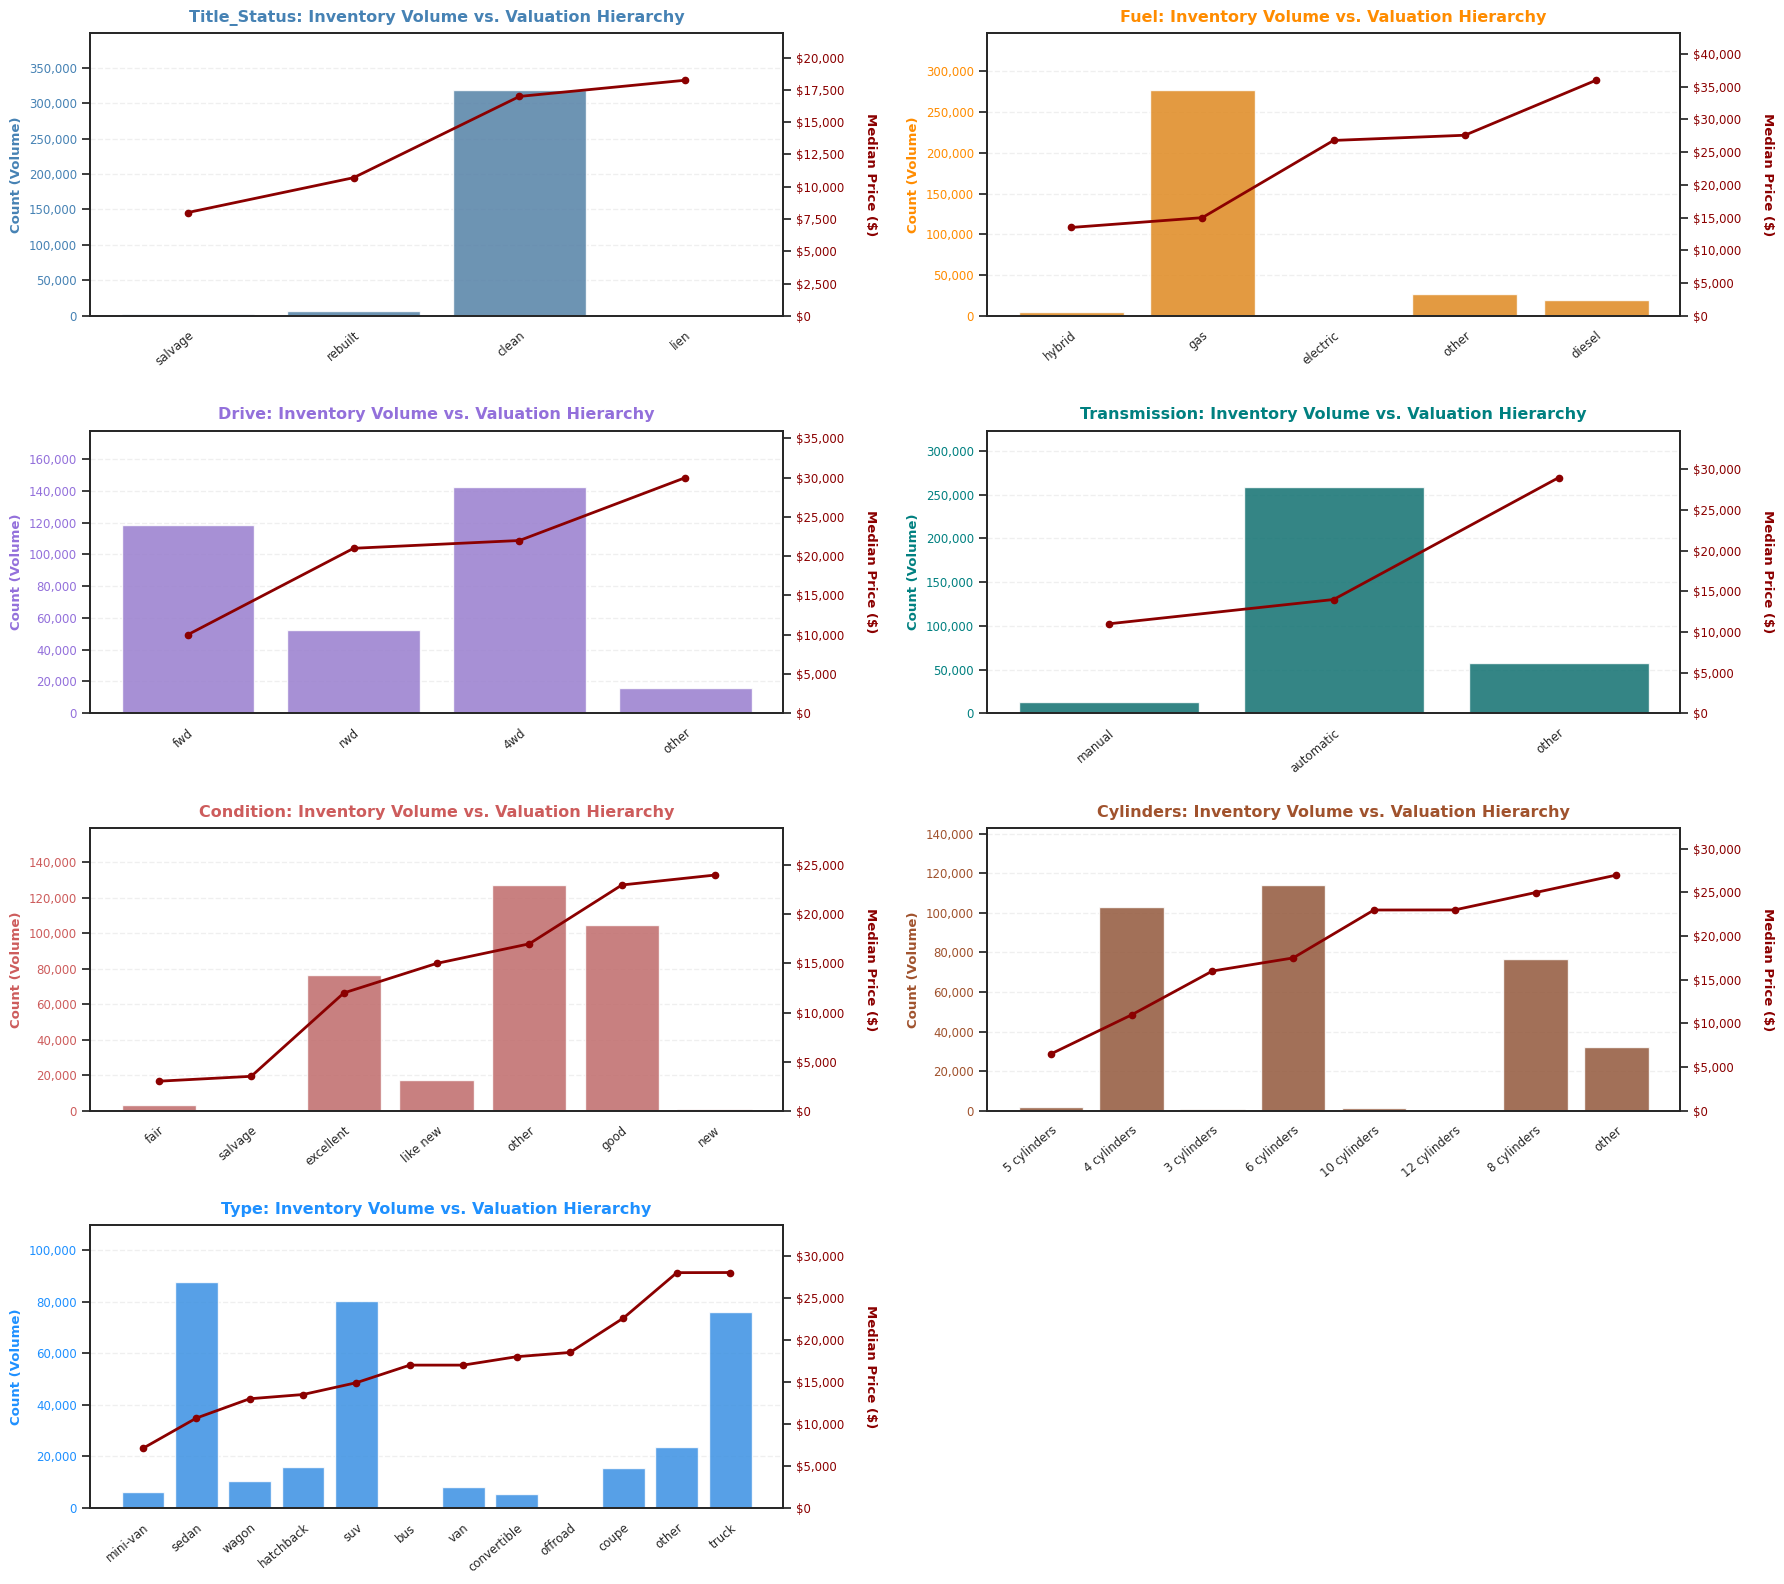

In [ ]:
sns.set_theme(style="white")

# Map each feature to its dedicated solid color for bars and color-coded titles
feature_colors = {
    "title_status": "steelblue",
    "fuel": "darkorange",
    "drive": "mediumpurple",
    "transmission": "teal",
    "condition": "indianred",
    "cylinders": "sienna",
    "type": "dodgerblue",
}

PRICE_LINE_COLOR = (
    "darkred"  # Unified dark red line for median price curve across all plots
)

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes_flat = axes.flatten()

for ax_idx, (col, bar_color) in enumerate(feature_colors.items()):
  ax1 = axes_flat[ax_idx]

  # Sort data by median price ASCENDING so the price line rises smoothly from
  # left to right
  data_table = (
      low_card_summary[col]
      .sort_values(by="median_price", ascending=True)
      .reset_index(drop=True)
  )

  # Primary Left Axis: Single Solid Color Volume Bars
  sns.barplot(
      data=data_table,
      x=col,
      y="listing_count",
      color=bar_color,
      alpha=0.85,
      ax=ax1,
  )

  # Color-code title and left y-axis matching the feature's dedicated bar color
  ax1.set_title(
      f"{col.title()}: Inventory Volume vs. Valuation Hierarchy",
      fontsize=11.5,
      fontweight="bold",
      color=bar_color,
      pad=8,
  )
  ax1.set_ylabel(
      "Count (Volume)", fontsize=9.5, fontweight="bold", color=bar_color
  )
  ax1.tick_params(axis="y", labelcolor=bar_color, labelsize=8.5)
  ax1.yaxis.set_major_formatter("{x:,.0f}")
  ax1.set_ylim(0, data_table["listing_count"].max() * 1.25)
  ax1.set_xlabel("")
  ax1.grid(axis="y", linestyle="--", alpha=0.3)

  # Warning-free X-Axis Ticks & Slanted Labels
  ax1.set_xticks(
      ticks=range(len(data_table)),
      labels=data_table[col],
      rotation=40,
      ha="right",
      va="top",
      rotation_mode="anchor",
      fontsize=8.5,
  )

  # Secondary Right Axis: Rising Red Median Price Line
  ax2 = ax1.twinx()
  ax2.plot(
      np.arange(len(data_table)),
      data_table["median_price"],
      color=PRICE_LINE_COLOR,
      marker="o",
      linewidth=2.0,
      markersize=4.5,
      linestyle="-",
      label="Median Price ($)",
  )
  ax2.set_ylabel(
      "Median Price ($)",
      fontsize=9.5,
      fontweight="bold",
      color=PRICE_LINE_COLOR,
      rotation=-90,
      va="bottom",
      labelpad=14,
  )
  ax2.tick_params(axis="y", labelcolor=PRICE_LINE_COLOR, labelsize=8.5)
  ax2.yaxis.set_major_formatter("${x:,.0f}")
  ax2.set_ylim(0, data_table["median_price"].max() * 1.2)
  ax2.grid(False)

# Clean up unused 8th subplot slot
fig.delaxes(axes_flat[7])

plt.tight_layout(h_pad=1.8, w_pad=1.8)
plt.show()


### 2.20: Insights: Low-Cardinality Categorical Features

* **`title_status`:** Clean titles represent 96.7% of listings, while non-clean titles have over 10,800 records to reliably capture salvage and rebuilt price discounts.
* **`fuel`:** Diesel vehicles have over 19,000 listings and hold the highest median price at \$35,995, commanding a substantial premium over standard gas models.
* **`drive`:** 4WD is the largest inventory segment at 43.2% and leads in median price at \$21,990, while FWD represents the lower-priced commuter segment at \$10,000.
* **`cylinders`:** Valuations scale directly with cylinder count, and 10-cylinder and 12-cylinder engines remain separate because their mean prices diverge by more than \$20,000.
* **`type`:** Pickups and trucks lead median valuations at \$27,999, whereas sedans and hatchbacks sit at the bottom of the pricing hierarchy.
* **`condition` & `transmission`:** The explicit other/unknown condition bucket sits cleanly between good and fair, while automatic transmission accounts for 78.4% of total inventory


## Summary: Categorical Feature Exploration

To recap:
* I dropped the high-cardinality `model` text column (18,029 messy trim variations) because `manufacturer` + `type` + `cylinders` + `fuel` + `drive` reconstructs the functional vehicle profile without adding 18,000 sparse columns.

*  I will one-hot encode **all** the remaining 9 categorical features (`state`, `manufacturer`, `type`, `drive`, `fuel`, `condition`, `title_status`, `transmission`, and `cylinders`), producing approximately **134 binary feature columns**.

I was worried that by adding >100 new features, I am making the feature set too large. To this end, I researched industry guidelines of what's the standard number to keep and when is it too much. For example, I could tell the 18,000 `model`s was too many but how do I know if the rest is okay?

According to standard statistical guidelines (such as *Harrell's Regression Modeling Strategies* and *Hair et al.'s Multivariate Data Analysis*), regression models require an observations-to-predictor ratio of at least **15:1 to 20:1** ($N/p \ge 20$) to estimate stable coefficients and prevent overfitting.
* With **329,752 clean rows** and **~134 features**, our dataset provides **over 2,400 observations per parameter**—far exceeding standard sample size thresholds.

Therefore, I feel more comfortable with going ahead with my plan and my DataFrame should be ready for the next step of training/test split and utlimately model generation.


In [ ]:
# save
filtered_cat_df_path = create_parquet_path('phase2_2_filtered_cat_features')

In [ ]:
filtered_cat_df = df.copy()
filtered_cat_df.to_parquet(filtered_cat_df_path)

print(f"Dataset saved to '{filtered_cat_df_path}'")
print(f"Shape: {filtered_cat_df.shape[0]:,} rows, {df.shape[1]} columns")

filtered_cat_df.info() # no model

Dataset saved to 'drive/MyDrive/all_data/11.1/data/output/dataframes/phase2_2_filtered_cat_features.parquet'
Shape: 329,752 rows, 12 columns
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   condition     329752 non-null  object 
 3   cylinders     329752 non-null  object 
 4   fuel          329752 non-null  object 
 5   odometer      329752 non-null  float64
 6   title_status  329752 non-null  object 
 7   transmission  329752 non-null  object 
 8   drive         329752 non-null  object 
 9   type          329752 non-null  object 
 10  state         329752 non-null  object 
 11  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 32.7+ MB


In [ ]:
# Check if 'filtered_cat_df' is already loaded in memory, else read from parquet
prefix = 'Previously had'
if "filtered_cat_df" not in locals() or df is None:
  if os.path.exists(filtered_cat_df_path):
    filtered_cat_df = pd.read_parquet(filtered_cat_df_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(
        f'Parquet checkpoint not found at: {filtered_cat_df_path}'
      )

# Expected 329,752 but no model
print(f'{prefix} {len(filtered_cat_df):,} cleaned records. Ready for Phase 2.2!')

df = filtered_cat_df.copy()
df.info()

Previously had 329,752 cleaned records. Ready for Phase 2.2!
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   condition     329752 non-null  object 
 3   cylinders     329752 non-null  object 
 4   fuel          329752 non-null  object 
 5   odometer      329752 non-null  float64
 6   title_status  329752 non-null  object 
 7   transmission  329752 non-null  object 
 8   drive         329752 non-null  object 
 9   type          329752 non-null  object 
 10  state         329752 non-null  object 
 11  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 32.7+ MB


### Addendum: Categorical Correlation using Dummies vs. OneHotEncoder

To establish a baseline during exploration, I want to use `pd.get_dummies()`  to calculate correlations between all categorical features and `price`, matching our earlier continuous variable analysis.

For model training, final one-hot encoding must be fitted **only on the training split (`X_train`)** to prevent data leakage. Applying dummy encoding across the entire dataset introduces target and vocabulary leakage and makes the model brittle. In real-world dealership operations, models must handle previously unseen inputs (such as a newly released manufacturer or unexpected trim).

Therefore, for Phase 3 preprocessing, I will encapsulate `OneHotEncoder` within Scikit-Learn's `ColumnTransformer` fitted exclusively on `X_train`. Using `handle_unknown'` guarantees that any new, unseen category encountered at inference time is safely routed to the learned infrequent/other baseline weight without causing pipeline crashes.


In [ ]:
all_cat_cols = df.select_dtypes(include="object").columns.tolist()
all_cat_cols

['manufacturer',
 'condition',
 'cylinders',
 'fuel',
 'title_status',
 'transmission',
 'drive',
 'type',
 'state']

In [ ]:
df_dummies = pd.get_dummies(
    df,
    columns=all_cat_cols,
    dtype=int,  # Produces 0/1 integers instead of boolean True/False
)

# Verify immutability of the original DataFrame
print(f"Original df shape: {df.shape} (Unchanged)")
print(f"New df_dummies shape: {df_dummies.shape}")
df_dummies.head()


Original df shape: (329752, 12) (Unchanged)
New df_dummies shape: (329752, 137)


,price,odometer,vehicle_age,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,manufacturer_bmw,manufacturer_buick,manufacturer_cadillac,...,state_sd,state_tn,state_tx,state_ut,state_va,state_vt,state_wa,state_wi,state_wv,state_wy
0,33590,57923.0,12.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,22590,71229.0,16.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,39590,19160.0,6.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,30990,41124.0,9.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,15000,128000.0,13.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
dummies_parquet_path = create_parquet_path('phase2_3_vehicles_with_dummies')

In [ ]:
# the model going forward is still df = filtered_cat_df
prefix = 'Previously had'
if "df_dummies" not in locals() or df is None:
  if os.path.exists(dummies_parquet_path):
    df_dummies = pd.read_parquet(dummies_parquet_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(
        f'Parquet checkpoint not found at: {dummies_parquet_path}'
      )

# Expected 329,752 but no model
print(f'{prefix} {len(dummies_parquet_path):,} with dummy records.')

# New df_dummies shape: (329752, 128)
df_dummies.info()

Previously had 89 with dummy records.
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Columns: 137 entries, price to state_wy
dtypes: float64(2), int64(135)
memory usage: 347.2 MB


In [ ]:
# save
df_dummies.to_parquet(dummies_parquet_path, index=False)
print(f"Saved cleaned dataset to: {dummies_parquet_path}")

Saved cleaned dataset to: drive/MyDrive/all_data/11.1/data/output/dataframes/phase2_3_vehicles_with_dummies.parquet


In [ ]:
# doing the entire heat map would be huge, just do one correlation with price
# Note this is with ALL features not just cat
correlations_with_price = df_dummies.corrwith(df["price"]).sort_values(
    ascending=False
)
correlations_with_price.sample(5)

,0
state_mn,-0.024162
state_oh,-0.043580
state_ky,0.000592
type_convertible,0.017128
state_la,0.006033


In [ ]:
top_pos = correlations_with_price.head(11) # first one is price itself
top_neg = correlations_with_price.tail(10)

top_drivers_series = pd.concat([top_pos, top_neg]).drop_duplicates()

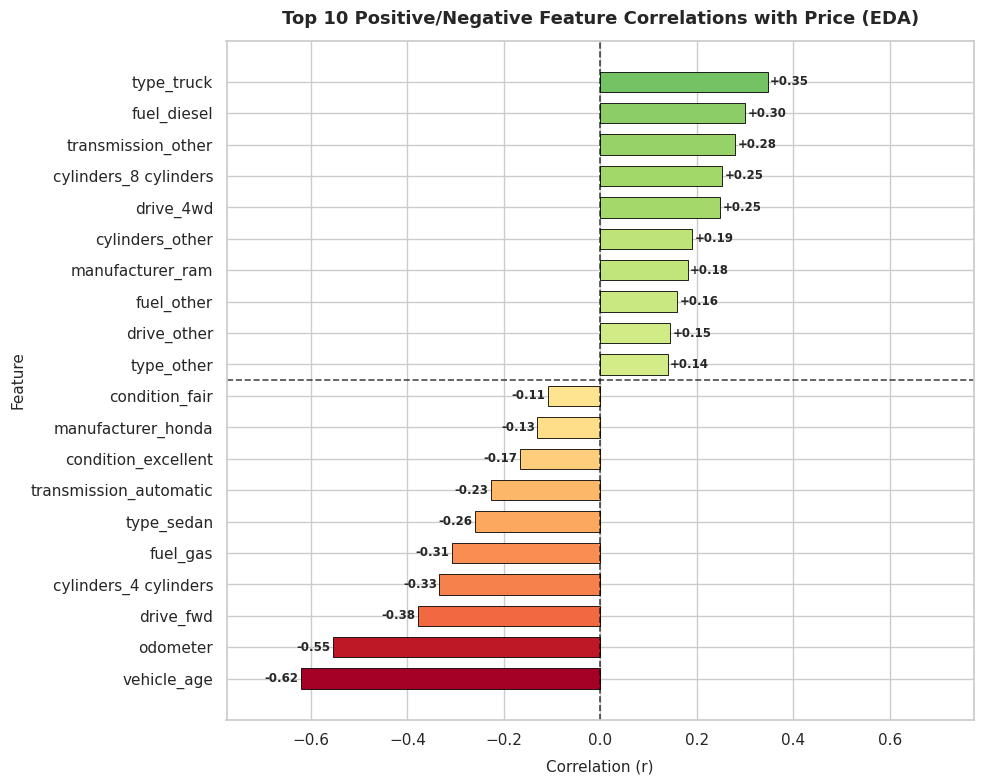

In [ ]:
# rather than a heatmap, a barplot would be a better visual since it would show
# relative correlation sizes and there's only one correlation - with price
sns.set_theme(style="whitegrid")

# Prepare and sort correlations descending (excluding self-correlation 'price')
drivers_clean = top_drivers_series.drop(labels=["price"], errors="ignore")
plot_data = (
    drivers_clean.to_frame(name="correlation")
    .reset_index(names="feature")
    .sort_values(by="correlation", ascending=True)  # Ascending so highest appears at top
)

# This code is just for gradient
max_abs_corr = max(
    abs(plot_data["correlation"].min()), abs(plot_data["correlation"].max())
)
norm = mcolors.Normalize(vmin=-max_abs_corr, vmax=max_abs_corr)

# colomap
cmap = plt.colormaps["RdYlGn"]
bar_colors = [cmap(norm(val)) for val in plot_data["correlation"]]

# Render Horizontal Diverging Bar Plot
plt.figure(figsize=(10, 8))

bars = plt.barh(
    y=plot_data["feature"],
    width=plot_data["correlation"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    height=0.65,
)

# Zero Reference Baselines
plt.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
plt.axhline(9.5, color="black", linestyle="--", linewidth=1.2, alpha=0.7)

# Add the correlation value as bar labels
for bar in bars:
  width = bar.get_width()
  ha_align = "left" if width >= 0 else "right"
  offset = 0.005 if width >= 0 else -0.005
  plt.text(
      width + offset,
      bar.get_y() + bar.get_height() / 2.0,
      f"{width:+.2f}",
      va="center",
      ha=ha_align,
      fontsize=8.5,
      fontweight="bold",
  )

plt.title(
    "Top 10 Positive/Negative Feature Correlations with Price (EDA)",
    fontsize=13,
    pad=12,
    fontweight="bold"
)
plt.xlabel("Correlation (r)", fontsize=11, labelpad=8)
plt.ylabel("Feature", fontsize=11)
plt.xlim(-max_abs_corr * 1.25, max_abs_corr * 1.25)

plt.tight_layout()
plt.show()


In [ ]:
# full print - very long
# print(correlations_with_price.to_string())

### Summary Addendum: Continuous Feature Correlations

In Phase 2.1 and now, I observed that **`vehicle_age` ($r = -0.620$)** and **`odometer` ($r = -0.555$)** exert the strongest downward pressure on valuation and have the largest correlation with price in absolute value terms.

From this new heatmap, I have some new observations:

* Attributes associated with standard commuter and economy vehicles exhibit the heaviest downward correlation with price:
  * Front-wheel drive (`drive_fwd`: $r = -0.378$)
  * 4-cylinder engines (`cylinders_4 cylinders`: $r = -0.334$)
  * Gas fuel (`fuel_gas`: $r = -0.308$)
  * Sedan body types (`type_sedan`: $r = -0.260$)
* Conversely, commercial utility and heavy performance configurations act as the strongest positive price drivers:
  * Pickup trucks (`type_truck`: $r = +0.347$) - this is also the strongest **positive** price indicator
  * Diesel powertrains (`fuel_diesel`: $r = +0.300$)
  * V8 engines (`cylinders_8 cylinders`: $r = +0.253$)
  * Four-wheel drive (`drive_4wd`: $r = +0.248$)


Finally, I note somewhat counterintuitive positive price correlations across catch-all categories, including `transmission_other` ($r = +0.279$) and `fuel_other` ($r = +0.160$).

Rather than representing baseline mechanical features, these could be acting as *confounding proxies* representing newer model-year inventory and unmapped specialty powertrains (such as plug-in hybrids, dual-clutch platforms, and heavy commercial chassis). It's possible that these `other` values were not distinctly classified during data collection.


## Phase 3: Preprocessing Pipelines and Feature Transformation

With exploratory data analysis and outlier filtering complete, I now transition from diagnostic inspection into **reproducible feature preprocessing and model pipeline construction**.

### Phase 3 Workflow:
1. **Data Partitioning (Phase 3.1):** Splitting our sanitized inventory into an **80/20 Train/Test split** with a fixed random state, locking in an un-leaked evaluation set before fitting any statistical transformers.
2. **Column Transformation Pipeline (Phase 3.2):**
   * Scale data to evaluate feature weights on an equal scale.
   * Apply the `OneHotEncoder` for our categorical feature as mentioned in `Phase 2.3`.

In [ ]:
filtered_cat_df_path = create_parquet_path('phase2_2_filtered_cat_features')

In [ ]:
# filtered_cat_df is the one we're using for phase 3

# Check if 'filtered_cat_df' is already loaded in memory, else read from parquet
prefix = 'Previously had'
if "filtered_cat_df" not in locals() or df is None:
  if os.path.exists(filtered_cat_df_path):
    filtered_cat_df = pd.read_parquet(filtered_cat_df_path)
    prefix = 'Loaded'
  else:
    raise FileNotFoundError(
        f'Parquet checkpoint not found at: {filtered_cat_df_path}'
      )

# Expected 329,752 but no model
print(f'{prefix} {len(filtered_cat_df):,} cleaned records. Ready for Phase 2.2!')

df = filtered_cat_df.copy()
df.info()

Loaded 329,752 cleaned records. Ready for Phase 2.2!
<class 'pandas.core.frame.DataFrame'>
Index: 329752 entries, 0 to 391962
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         329752 non-null  int64  
 1   manufacturer  329752 non-null  object 
 2   condition     329752 non-null  object 
 3   cylinders     329752 non-null  object 
 4   fuel          329752 non-null  object 
 5   odometer      329752 non-null  float64
 6   title_status  329752 non-null  object 
 7   transmission  329752 non-null  object 
 8   drive         329752 non-null  object 
 9   type          329752 non-null  object 
 10  state         329752 non-null  object 
 11  vehicle_age   329752 non-null  float64
dtypes: float64(2), int64(1), object(9)
memory usage: 32.7+ MB


### 3.1: Train/Test Data Partitioning & Model Evaluation

To ensure unbiased evaluation, I separate our independent predictors ($X$) from our target ($y = \text{price}$) and partition the data into an **80% Training set** and a **20% Test set** in a standard **Holdout** pattern.

Partitioning occurs *before* any feature scalers or encoders are initialized to guarantee that parameters are learned only from `X_train`, preventing information from `X_test` from leaking into model training.`X_test` remains strictly held out until final model scoring to measure real-world pricing generalization for the dealership.

To evaluate model performance and select the best algorithm for the dealership, I will track **six** complementary regression metrics:

1. **Mean Absolute Error (MAE):**
   Measures the average dollar difference between predicted values and actual market sales. This gives the dealership an intuitive dollar-accuracy expectation for typical inventory.
2. **Root Mean Squared Error (RMSE):**
   Measures prediction variance while heavily penalizing large misses. Because mispricing high-value inventory by thousands of dollars represents significant financial risk to the dealership, tracking RMSE ensures the model avoids severe pricing errors.
3. **Coefficient of Determination ($R^2$):**
   Quantifies the proportion of total market price variance explained by our engineered features, providing a standardized benchmark to rank linear and tree-based models.
4. **Generalization Gap ($\Delta \text{Train-Test Performance}$):**
   Compares training set performance against holdout test set performance to detect overfitting or underfitting early, ensuring the model generalizes reliably to newly acquired vehicles.
5. **Training Time (Compute Cost):**
   Measures the wall-clock time required to fit the model and tune hyperparameters on 329k+ records, establishing the computational feasibility of automated nightly or weekly retraining pipelines.
6. **Prediction Latency (Serving Speed):**
   Measures the time required to generate predictions for single vehicles and batch imports, ensuring the pricing engine delivers instant real-time quotes for dealership sales tools.

In [ ]:
# Separate target variable
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split( # SHUFFLES by default
    X, y, test_size=0.20, random_state=42
)

print(f"Total Clean Fleet : {len(df):,} records")
print(
    f"Training Set (80%): {len(X_train):,} rows ({len(X_train)/len(df)*100:.1f}%)"
)
print(
    f"Test Set (20%)    : {len(X_test):,} rows ({len(X_test)/len(df)*100:.1f}%)"
)
print(f"Features in X     : {list(X.columns)}")

Total Clean Fleet : 329,752 records
Training Set (80%): 263,801 rows (80.0%)
Test Set (20%)    : 65,951 rows (20.0%)
Features in X     : ['manufacturer', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'state', 'vehicle_age']


In [ ]:
# Identify numerical and categorical column subsets
numerical_features = ["odometer", "vehicle_age"]
categorical_features = [
    "title_status",
    "fuel",
    "drive",
    "transmission",
    "condition",
    "cylinders",
    "type",
    "manufacturer",
    "state",
]


Since model evaluation with output of error and $R^2$ will be done for every model, I an opting to functionalize it to call it repeatedly for every model.

### 3.2: Continuous Feature Baseline Strategy
My correlation analysis in `Phase 2.1` showed that `vehicle_age` and `odometer` are the two dominant continuous drivers of price ($r = -0.62$ and $r = -0.55$). Furthermore, the EDA regression plots indicated that a quadratic (Degree 2) curve captured early-year depreciation better than a straight line.

Therefore, before introducing categorical one-hot features, I want to build a simple baseline regression model using **only continuous features**. This will establish an un-leaked 80/20 train/test benchmark ($R^2$ and RMSE in real dollars) and measure the exact performance lift of adding a **Degree-2 polynomial transform** on age and mileage.

In [ ]:
# Initialize Basic LinearRegression DF to store metrics of all models
model_benchmarks_OLS = pd.DataFrame()

In [ ]:
# Model M1: Degree 1 Linear Baseline Pipeline
linear_baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=1, include_bias=False)),
    ("linear_model", LinearRegression()),
])

evaluate_regression_model(
    "O1 Baseline OLS Regression - Degree 1",
    linear_baseline_model,
    X_train[numerical_features],
    y_train,
    X_test[numerical_features],
    y_test,
    results_df=model_benchmarks_OLS
)

# Model M2: Degree 2 Quadratic Polynomial Pipeline
quadratic_poly_model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear_model", LinearRegression()),
])

evaluate_regression_model(
    "O2 Baseline OLS Regression - Degree 2",
    quadratic_poly_model,
    X_train[numerical_features],
    y_train,
    X_test[numerical_features],
    y_test,
    results_df=model_benchmarks_OLS
)

In [ ]:
model_benchmarks_OLS

,Model,Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train R²,Test R²,Generalization (ΔR²),Fit Time (s),Predict Time (s)
0,O1 Baseline OLS Regression - Degree 1,11109.66,11143.46,7988.27,7975.27,0.4158,0.413,0.0028,0.034,0.013
1,O2 Baseline OLS Regression - Degree 2,10818.92,10884.26,7579.79,7592.24,0.4460,0.440,0.0060,0.073,0.030


In [ ]:
# save results

# 1. Save Model M1 (Degree 1 Baseline)
m1_save_path = create_joblib_path("phase3_2_o1_ols_baseline_deg1")
joblib.dump(linear_baseline_model, m1_save_path)
print(f"Saved O1 to: {m1_save_path}")

# 2. Save Model M2 (Degree 2 Quadratic)
m2_save_path = create_joblib_path("phase3_2_o2_ols_baseline_deg2")
joblib.dump(quadratic_poly_model, m2_save_path)
print(f"Saved O2 to: {m2_save_path}")

Saved O1 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_2_o1_ols_baseline_deg1.joblib
Saved O2 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_2_o2_ols_baseline_deg2.joblib


### Model Comparison: Baseline OLS Degree 1 vs. Degree 2

Evaluating the baseline Ordinary Least Squares (OLS) models **confirms** that incorporating quadratic terms (**Degree 2**) provides superior predictive performance:

* Test MAE drops by **\$383.03** (from \$7,975.27 down to \$7,592.24), and Test RMSE drops by **\$259.20**.
* Test $R^2$ increases from **0.4130 to 0.4400** (+2.7% more price variance explained on unseen data).

While Degree 2 shows a slight gap ($\Delta R^2 = 0.0060$), the test performance improves across all three error metrics, confirming genuine non-linear learning (capturing early-year depreciation curves and age-mileage interactions) rather than harmful overfitting.

This made me curious to see what would happen if I increase the degree further. For example, one problem with the quadratic model as discussed earlier is that the curve goes back up - perhaps an odd degree model could help fix that?


In [ ]:
model_dict = {}

for degree in range(3, 6):
  poly_model = Pipeline([
      ("scaler", StandardScaler()),
      ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
      ("linear_model", LinearRegression()),
  ])

  model_dict[f"phase3_2_o{degree}_ols_baseline_deg{degree}"] = poly_model

  evaluate_regression_model(
        f"O{degree} Baseline OLS Regression - Degree {degree}",
        poly_model,
        X_train[numerical_features],
        y_train,
        X_test[numerical_features],
        y_test,
        results_df=model_benchmarks_OLS
    )
model_benchmarks_OLS

,Model,Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train R²,Test R²,Generalization (ΔR²),Fit Time (s),Predict Time (s)
0,O1 Baseline OLS Regression - Degree 1,11109.66,11143.46,7988.27,7975.27,0.4158,0.4130,0.0028,0.034,0.013
1,O2 Baseline OLS Regression - Degree 2,10818.92,10884.26,7579.79,7592.24,0.4460,0.4400,0.0060,0.073,0.030
2,O3 Baseline OLS Regression - Degree 3,10800.17,10866.85,7555.10,7568.48,0.4479,0.4418,0.0061,0.101,0.051
3,O4 Baseline OLS Regression - Degree 4,10765.05,10831.20,7515.68,7530.97,0.4515,0.4455,0.0060,0.211,0.102
4,O5 Baseline OLS Regression - Degree 5,10731.98,10812.48,7478.22,7501.09,0.4549,0.4474,0.0075,0.317,0.124


I wanted to examine the error rates against degree (_k_) through a scree plot.

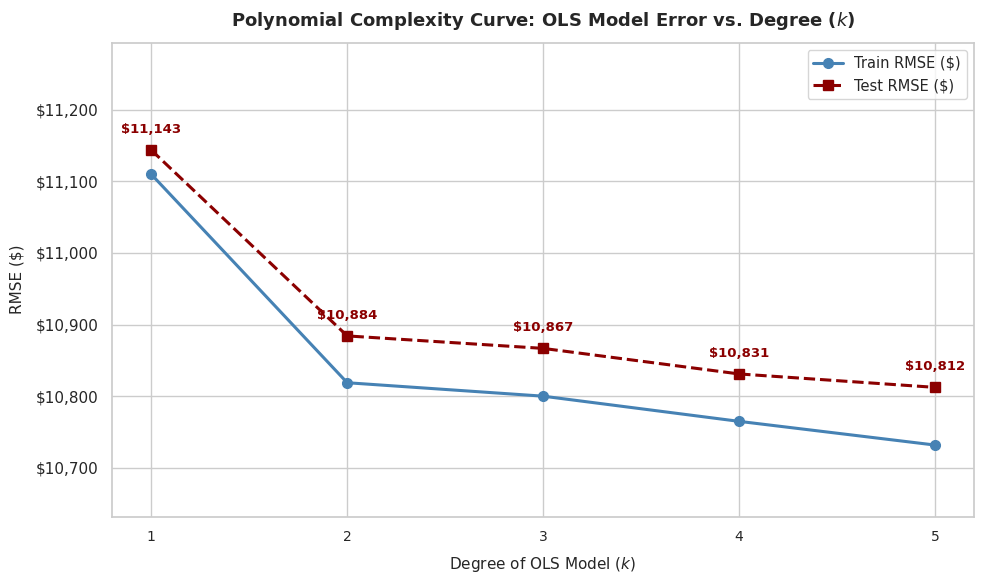

In [ ]:
### Create elbow plot

# get x and y axis values - degree vs train+test RMSE
degrees = [1, 2, 3, 4, 5]
train_rmse = model_benchmarks_OLS["Train RMSE ($)"].values
test_rmse = model_benchmarks_OLS["Test RMSE ($)"].values

# Generate plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Train RMSE Curve
plt.plot(
    degrees,
    train_rmse,
    marker="o",
    linewidth=2.2,
    markersize=7,
    color="steelblue",
    label="Train RMSE ($)",
)

# Test RMSE Curve
plt.plot(
    degrees,
    test_rmse,
    marker="s",
    linewidth=2.2,
    markersize=7,
    linestyle="--",
    color="darkred",
    label="Test RMSE ($)",
)

# Annotate Test RMSE dollar values at each degree
for deg, val in zip(degrees, test_rmse):
  plt.text(
      deg,
      val + 20,
      f"${val:,.0f}",
      ha="center",
      va="bottom",
      fontsize=9.5,
      fontweight="bold",
      color="darkred",
  )

# Formatting
plt.title(
    "Polynomial Complexity Curve: OLS Model Error vs. Degree ($k$)",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Degree of OLS Model ($k$)", fontsize=11, labelpad=8)
plt.ylabel("RMSE ($)", fontsize=11, labelpad=8)
plt.xticks(degrees, fontsize=10)

# Format y-axis as dollar values
plt.gca().yaxis.set_major_formatter("${x:,.0f}")
plt.ylim(min(train_rmse.min(), test_rmse.min()) - 100, test_rmse.max() + 150)

plt.legend(loc="upper right", frameon=True, fontsize=10.5)
plt.tight_layout()
plt.show()


### Polynomial Complexity Analysis: Selecting Optimal Degree via Elbow Plot

Moving from Degree 1 (straight linear) to Degree 2 (quadratic) produces the largest sharp decrease in validation error, reducing RMSE by capturing early-stage rapid depreciation.

Beyond Degree 2, validation error plateaus. Higher degrees add exponential feature combinations ($x_1^3, x_1^2 x_2, x_2^3$) without yielding meaningful error reductions, increasing the risk of boundary variance and overfitting.

**Conclusion:**
**Degree 2** is optimal for use in our regression models.


In [ ]:
# save results

for model_name, model in model_dict.items():
  # 1. Save Model M1 (Degree 1 Baseline)
  model_save_path = create_joblib_path(model_name)
  joblib.dump(model, model_save_path)
  print(f"Saved {model_name} to: {model_save_path}")

Saved phase3_2_o3_ols_baseline_deg3.joblib to: drive/MyDrive/all_data/11.1/data/output/models/phase3_2_o3_ols_baseline_deg3.joblib.joblib
Saved phase3_2_o4_ols_baseline_deg4.joblib to: drive/MyDrive/all_data/11.1/data/output/models/phase3_2_o4_ols_baseline_deg4.joblib.joblib
Saved phase3_2_o5_ols_baseline_deg5.joblib to: drive/MyDrive/all_data/11.1/data/output/models/phase3_2_o5_ols_baseline_deg5.joblib.joblib


### 3.3: Full Feature Baseline Strategy
With our continuous baseline establishing that a Degree-2 curve best models age and mileage (\(R^2 \approx 0.44\)), the next step is to introduce the categorical specifications (`manufacturer`, `cylinders`, `fuel`, `title_status`, `drive`, `type`, and `state`).

To do this cleanly without data leakage, I bcan use a `ColumnTransformer` pipeline:
* **Continuous Features:** Standardized and expanded with Degree-2 polynomial terms (`vehicle_age`, `odometer`, and their interaction).
* **Categorical Features:** One-hot encoded with `handle_unknown='ignore'` across all 9 nominal variables as discussed in Phase 2.

Training a full Ordinary Least Squares (OLS) model on this combined pipeline establishes our **complete baseline benchmark**. This allows us to quantify the exact dollar value and accuracy gain of including vehicle build specifications before exploring regularized models (Ridge and Lasso).

In [ ]:
# Create preprocessor transformer for parallel transformation across
# all models
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "poly",
                    PolynomialFeatures(degree=2, include_bias=False),
                ),
                ("scaler", StandardScaler()),
            ]),
            numerical_features,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ]
)

In [ ]:
ols_quadratic_poly_model_full = Pipeline([ # all features now
    ("preprocess", preprocessor),
    ("linear_model", LinearRegression()),
])

evaluate_regression_model(
    "O6 Full OLS Regression - Degree 2",
    ols_quadratic_poly_model_full,
    X_train,
    y_train,
    X_test,
    y_test,
    results_df=model_benchmarks_OLS
)
model_benchmarks_OLS

,Model,Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train R²,Test R²,Generalization (ΔR²),Fit Time (s),Predict Time (s)
0,O1 Baseline OLS Regression - Degree 1,11109.66,11143.46,7988.27,7975.27,0.4158,0.4130,0.0028,0.034,0.013
1,O2 Baseline OLS Regression - Degree 2,10818.92,10884.26,7579.79,7592.24,0.4460,0.4400,0.0060,0.073,0.030
2,O3 Baseline OLS Regression - Degree 3,10800.17,10866.85,7555.10,7568.48,0.4479,0.4418,0.0061,0.101,0.051
3,O4 Baseline OLS Regression - Degree 4,10765.05,10831.20,7515.68,7530.97,0.4515,0.4455,0.0060,0.211,0.102
4,O5 Baseline OLS Regression - Degree 5,10731.98,10812.48,7478.22,7501.09,0.4549,0.4474,0.0075,0.317,0.124
5,O6 Full OLS Regression - Degree 2,7199.75,7229.25,4761.08,4789.56,0.7547,0.7530,0.0017,7.058,2.583


### Summary of Baseline Model Results
* **Higher Degrees Yield Diminishing Returns:** Pushing the continuous polynomial from Degree 2 up to Degree 5 barely moved the needle, improving Test $R^2$ by less than 1% ($0.4400 \to 0.4474$) while steadily increasing fit time and complexity.
* **Vehicle Specs Drive the Real Value:** Adding categorical features in the Degree-2 Full OLS model produced a massive performance jump—Test $R^2$ surged from **$0.4400$ to $0.7530$**, and Test MAE dropped by over **\$2,800** (from \$7,592.24 down to \$4,789.56).
* **Takeaway:** Who built the car, its engine cylinders, fuel type, and drivetrain matter far more to pricing than simply stacking higher polynomial degrees onto age and mileage alone.


In [ ]:
# save the full model and the final OLS results
model_save_path = create_joblib_path("phase3_3_o6_ols_baseline_deg2_FULL")
joblib.dump(ols_quadratic_poly_model_full, model_save_path)
print(f"Saved O6 to: {model_save_path}")

# Save benchmark results
benchmarks_file_path = \
  create_parquet_path("phase3_3_OLS_Baseline_Benchmarks")
model_benchmarks_OLS.to_parquet(benchmarks_file_path)
print(f"Saved OLS Benchmarks to: {model_save_path}")

Saved O6 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_3_o6_ols_baseline_deg2_FULL.joblib
Saved OLS Benchmarks to: drive/MyDrive/all_data/11.1/data/output/models/phase3_3_o6_ols_baseline_deg2_FULL.joblib


### Phase 3.4: Ridge Full Model Alpha Exploration (Manual GridSearch)

With our full OLS baseline established ($R^2 \approx 0.753$), the next step is to explore $L_2$ regularization using Ridge regression. Because Ridge shrinks coefficients toward zero without dropping them, it allows us to test whether penalizing large weights improves generalization while retaining all 139 features.

Rather than running a full cross-validated grid search immediately, I manually sweep $\alpha$ across orders of magnitude ($\alpha \in \{1, 10, 100, 1000\}$). This quick evaluation gives me an immediate ballpark of how sensitive our feature set is to $L_2$ shrinkage and tells me whether a narrower search window is even necessary.



In [ ]:
model_benchmarks_Ridge = pd.DataFrame()

In [ ]:
ridge_models = {}

for e in range(0, 4):
  alpha_val = float(10**e)

  # Instantiate pipeline with dynamic alpha
  ridge_model = Pipeline([
      ("preprocess", preprocessor),
      ("ridge_model", Ridge(alpha=alpha_val, random_state=74)),
  ])

  ridge_models[f"phase3_4_r{e}_ridge_alpha_{alpha_val}"] = ridge_model

  # Evaluate model and append/replace record in model_benchmarks
  evaluate_regression_model(
      model_name=f"R{e} Ridge Regression - Degree 2, Alpha {alpha_val:.0f}",
      model=ridge_model,
      X_train=X_train,
      y_train=y_train,
      X_test=X_test,
      y_test=y_test,
      results_df=model_benchmarks_Ridge,
  )

# Display updated benchmark comparison table
model_benchmarks_Ridge

,Model,Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train R²,Test R²,Generalization (ΔR²),Fit Time (s),Predict Time (s)
0,"R0 Ridge Regression - Degree 2, Alpha 1",7199.84,7230.51,4761.17,4789.86,0.7546,0.7529,0.0018,0.986,0.779
1,"R1 Ridge Regression - Degree 2, Alpha 10",7205.37,7245.17,4762.70,4792.11,0.7543,0.7519,0.0024,2.559,2.275
2,"R2 Ridge Regression - Degree 2, Alpha 100",7267.11,7340.33,4771.66,4801.96,0.7500,0.7453,0.0047,1.993,1.300
3,"R3 Ridge Regression - Degree 2, Alpha 1000",7381.07,7473.20,4803.87,4834.46,0.7421,0.7360,0.0061,1.533,0.863


### Summary of Ridge Exploration: Why Further Tuning Is Unnecessary
* **Performance Degrades as Regularization Increases:** The smallest penalty tested (α = 1, R0) yielded the best results (Test R² = 0.7529, Test MAE = \$4,789.86). Increasing α to 10, 100, and 1,000 strictly degraded accuracy, dropping Test R² to 0.7360 and adding \$45 to the MAE as it over-dampened real market signals.
* **Ridge Converges Back to OLS:** At α = 1, the performance is virtually **identical** to unregularized OLS (Test R² = 0.7530, Test MAE = \$4,789.56). Because the optimal penalty sits near zero, Ridge simply replicates the linear regression hyperplane.
* **OLS Retains the Operational Edge:** Since Ridge offers zero accuracy lift while adding computational overhead (OLS fits in 0.034s vs. 0.986s), there is no value in running an exhaustive `GridSearchCV` on L₂ penalties.

The large sample size (N > 263k) already protects against OLS giving extreme weights. I now turn my attention to Lasso - its feature of zeroing out features could give a better idea of the largest feature drivers from the dataset.



In [ ]:
# save all models
for model_name, model in ridge_models.items():
  # 1. Save Model M1 (Degree 1 Baseline)
  model_save_path = create_joblib_path(model_name)
  joblib.dump(model, model_save_path)
  print(f"Saved {model_name} to: {model_save_path}")

# Save benchmark results
r_benchmarks_file_path = \
  create_parquet_path("phase3_4_Ridge_Benchmarks")
model_benchmarks_Ridge.to_parquet(r_benchmarks_file_path)
print(f"Saved Ridge Benchmarks to: {r_benchmarks_file_path}")

Saved phase3_4_r0_ridge_alpha_1.0 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_4_r0_ridge_alpha_1.0.joblib
Saved phase3_4_r1_ridge_alpha_10.0 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_4_r1_ridge_alpha_10.0.joblib
Saved phase3_4_r2_ridge_alpha_100.0 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_4_r2_ridge_alpha_100.0.joblib
Saved phase3_4_r3_ridge_alpha_1000.0 to: drive/MyDrive/all_data/11.1/data/output/models/phase3_4_r3_ridge_alpha_1000.0.joblib
Saved Ridge Benchmarks to: drive/MyDrive/all_data/11.1/data/output/dataframes/phase3_4_Ridge_Benchmarks.parquet


### Phase 3.5: Lasso Model Optimization via 5-Fold LassoCV

To determine the optimal regularization strength efficiently, I used `LassoCV` with 5-fold cross-validation across a candidate grid of \(\alpha \in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]\). Using `LassoCV` reuses calculations ("warm start") along the regularization path, making it **significantly** faster and more computationally efficient than a brute-force `GridSearchCV`.

In [ ]:
model_benchmarks_Lasso = pd.DataFrame()

In [ ]:
lasso_cv_pipeline = Pipeline([
    ("preprocess", preprocessor),
    (
        "lasso_cv",  # runs faster with warm starts
        LassoCV(
            alphas=[0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
            cv=5,  # 5-fold cross-validation
            random_state=76,
            max_iter=2000,
            n_jobs=-1,
            tol=1e-2  # lower tolerance slightly for faster execution
        ),
    ),
])

lasso_cv_pipeline.fit(X_train, y_train)

# Extract the fitted LassoCV model from the pipeline
lasso_cv_step = lasso_cv_pipeline.named_steps["lasso_cv"]
best_alpha = lasso_cv_step.alpha_

# Compute mean CV RMSE across folds at the best alpha index
best_alpha_idx = np.where(lasso_cv_step.alphas_ == best_alpha)[0][0]
mean_mse_per_alpha = lasso_cv_step.mse_path_.mean(axis=-1)
best_cv_rmse = np.sqrt(mean_mse_per_alpha[best_alpha_idx])

print("=" * 22 + " LassoCV Results " + "=" * 22)
print(f"Optimal Alpha Selected by 5-Fold CV: {best_alpha}")
print(f"Mean Cross-Validation RMSE:          ${best_cv_rmse:,.2f}")
print("=" * 60)



====================== LassoCV Results ======================
Optimal Alpha Selected by 5-Fold CV: 0.1
Mean Cross-Validation RMSE:          $7,206.42


Note: This model fit and creation took more than half an hour. For repeated runs, I immediately saved the model.

In [ ]:
# reload model if needed.

# best_alpha = 0.1
# lasso_model_save_path = \
#   create_joblib_path(f"phase3_5_lasso_best_alpha_{best_alpha}")
# lasso_cv_pipeline = joblib.load(lasso_model_save_path)

5-fold cross-validation converged on an optimal penalty of $(\alpha = 0.1)$ with a mean CV RMSE of \(\$7,206.42\), confirming that the data strongly favors minimal regularization. Applying this small $(L_1)$ penalty prundredundant coefficients while preserving the unconstrained predictive strength of the full feature set.

In [ ]:
evaluate_regression_model(
    model_name=f"L1 Lasso Regression - Degree 2,Optimal α={best_alpha}",
    model=lasso_cv_pipeline,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    fit_model=False,  # Already fitted above
    results_df=model_benchmarks_Lasso,
)

[Benchmark Update] 'L1 Lasso Regression - Degree 2,Optimal α=0.1' already exists. Replacing previous entry.


In [ ]:
model_benchmarks_Lasso

,Model,Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train R²,Test R²,Generalization (ΔR²),Fit Time (s),Predict Time (s)
0,"L1 Lasso Regression - Degree 2,Optimal α=0.1",7199.78,7229.54,4760.81,4789.26,0.7547,0.7529,0.0017,-1.0,1.263


### Summary of Lasso (L1) Evaluation Results

The tuned Lasso model scores virtually identically to full OLS and Ridge R0, achieving a **Test $R^2 = 0.7529$**, **Test MAE = \$4,789.26**, and **Test RMSE = \$7,229.54**.

The difference between train ($0.7547$) and test ($0.7529$) performance remains microscopic, confirming that the pipeline generalizes cleanly without overfitting on holdout data.

Lasso hits the lowest Test MAE (\$4,789.26) observed across **all** tested models (edging out OLS by \$0.30), proving that light $L_1$ shrinkage retains peak accuracy while going ahead with pruning.



In [ ]:
lasso_model_save_path = \
  create_joblib_path(f"phase3_5_lasso_best_alpha_{best_alpha}")
joblib.dump(lasso_cv_pipeline, lasso_model_save_path)
print(f"Saved Best Lasso Pipeline to: {lasso_model_save_path}")

# 5b. Save benchmark DataFrame artifact
lasso_benchmarks_file_path = create_parquet_path("phase3_5_Lasso_Benchmarks")
model_benchmarks_Lasso.to_parquet(lasso_benchmarks_file_path, index=False)
print(f"Saved Lasso Benchmarks to:     {lasso_benchmarks_file_path}")

Saved Best Lasso Pipeline to: drive/MyDrive/all_data/11.1/data/output/models/phase3_5_lasso_best_alpha_0.1.joblib
Saved Lasso Benchmarks to:     drive/MyDrive/all_data/11.1/data/output/dataframes/phase3_5_Lasso_Benchmarks.parquet


### 3.6: Shallow-dive - Top features from Lasso

Since Lasso has the property to retain only the important features, and I have established that it returned some of the best results, I can use it to get an idea of what the top impact eatures might be. This can then be used in the analysis phase.

In [ ]:

preprocessor_step = lasso_cv_pipeline.named_steps["preprocess"]
lasso_step : LassoCV = lasso_cv_pipeline.named_steps["lasso_cv"]

# 2. Extract feature names and coefficient array
feature_names = preprocessor_step.get_feature_names_out()
coefficients = lasso_step.coef_

# Flatten if shape is (1, p)
if coefficients.ndim > 1:
  coefficients = coefficients.ravel()

# 3. Retrieve the optimal alpha selected by cross-validation
best_alpha = float(lasso_step.alpha_)

# 4. Construct the summary DataFrame
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Abs_Weight": np.abs(coefficients),
})

# 5. Filter for non-zero (active) features
active_lasso_df = (
    coef_df.query("Abs_Weight > 0.0")
    .sort_values(by="Abs_Weight", ascending=False)
    .reset_index(drop=True)
)

# Reporting metrics
total_features = len(feature_names)
retained_features = len(active_lasso_df)
eliminated_features = total_features - retained_features

print(f"[LassoCV Summary]")
print(f"Optimal Alpha (α):        {best_alpha:.6f}")
print(f"Total Input Features:      {total_features}")
print(f"Retained Non-Zero Features: {retained_features}")
print(f"Eliminated Features:       {eliminated_features}")
print(f"Sparsity / Retention Rate: {retained_features / total_features:.1%}\n")

active_lasso_df


[LassoCV Summary]
Optimal Alpha (α):        0.100000
Total Input Features:      139
Retained Non-Zero Features: 132
Eliminated Features:       7
Sparsity / Retention Rate: 95.0%



,Feature,Coefficient,Abs_Weight
0,cat__manufacturer_ferrari,109696.943346,109696.943346
1,cat__manufacturer_aston-martin,21225.964291,21225.964291
2,cat__manufacturer_tesla,16792.458309,16792.458309
3,num__vehicle_age,-14720.398258,14720.398258
4,cat__cylinders_12 cylinders,14653.460935,14653.460935
...,...,...,...
127,cat__state_ky,-61.563146,61.563146
128,cat__condition_excellent,58.108437,58.108437
129,cat__state_tn,49.248479,49.248479
130,cat__manufacturer_gmc,41.592345,41.592345


The cross-validated Lasso model optimized at α = 0.1, maintaining a 95.0% feature retention rate by keeping 132 core predictors and pruning 7 completely redundant features. This light L₁ regularization enforces ideal parsimony (more explaining power with less features) without sacrificing predictive accuracy.

The inital look already shows some patterns to the premiums and detractors:
* **High-Value Brand & Powertrain Premiums:** Badges like **Ferrari (\(+\$109,696.94\))**, **Aston Martin (\(+\$21,225.96\))**, and **Tesla (\(+\$16,792.46\))**, alongside **12-cylinder engines (\(+\$14,653.46\))**, command massive market premiums.
* **Depreciation:** **Vehicle age (\(-\$14,720.40\) linear term weight)** serves as the primary negative anchor on asset value before factoring in quadratic recovery curves and odometer interactions. This matches my analysis in Phase 2.

This will be interesting to look at in more detail in Phase 4.

In [ ]:
# save lasso coefficeints
lasso_coefficients_file_path = create_parquet_path("phase3_6_Lasso_Coefficients")
active_lasso_df.to_parquet(
    lasso_coefficients_file_path,
    index=False
)
print(f"Saved Lasso Coefficients to:     {lasso_coefficients_file_path}")

Saved Lasso Coefficients to:     drive/MyDrive/all_data/11.1/data/output/dataframes/phase3_6_Lasso_Coefficients.parquet


## Phase 4: Model Results Deep Dive

In this phase, I systematically evaluate and cross-examine all 11 models from Phase 3.

Specifically, the Phase 4 investigation executes four key objectives:
1. **Multi-Model Metric Comparison:** Benchmark all 11 configurations side-by-side across holdout validation metrics to determine if a single architecture holds a clear empirical edge.
2. **Cross-Model Driver Analysis:** Compare the top predictive drivers across every model to identify any shifting feature impacts or weight discrepancies, providing a statistical explanation for why these variations occur.
3. **Coefficient Feature Extraction:** Simultaneously isolate and extract the raw mathematical weights of both continuous variables (like age and mileage) and categorical dummy features (such as vehicle makes, titles, and cylinder counts).
4. **Predictive Performance Visualization:** Build diagnostic and prediction check plots to visually assess exactly how well our top-performing models mirror **real-world market values** across the vehicle asset spectrum. After all, this is my goal - provide a raw dollars-per-feature impact to dealers to understand how to price vehicles.

In [ ]:
# Load back all the model poipelines
model_o1_ols_baseline_deg1       = joblib.load(create_joblib_path("phase3_2_o1_ols_baseline_deg1"))
model_o2_ols_baseline_deg2       = joblib.load(create_joblib_path("phase3_2_o2_ols_baseline_deg2"))
model_o3_ols_baseline_deg3       = joblib.load(create_joblib_path("phase3_2_o3_ols_baseline_deg3"))
model_o4_ols_baseline_deg4       = joblib.load(create_joblib_path("phase3_2_o4_ols_baseline_deg4"))
model_o5_ols_baseline_deg5       = joblib.load(create_joblib_path("phase3_2_o5_ols_baseline_deg5"))
model_o6_ols_baseline_deg2_full  = joblib.load(create_joblib_path("phase3_3_o6_ols_baseline_deg2_FULL"))
model_r0_ridge_alpha_1_0  = joblib.load(create_joblib_path("phase3_4_r0_ridge_alpha_1.0"))
model_r1_ridge_alpha_10_0 = joblib.load(create_joblib_path("phase3_4_r1_ridge_alpha_10.0"))
model_r2_ridge_alpha_100_0= joblib.load(create_joblib_path("phase3_4_r2_ridge_alpha_100.0"))
model_r3_ridge_alpha_1000_0= joblib.load(create_joblib_path("phase3_4_r3_ridge_alpha_1000.0"))
model_lasso_best_alpha_0_1       = joblib.load(create_joblib_path("phase3_5_lasso_best_alpha_0.1"))
print("All model pipelines reloaded")

All model pipelines reloaded


In [ ]:
# if running fresh, reload all

# load all benchmark dataframes
model_benchmarks_OLS         = pd.read_parquet(create_parquet_path("phase3_3_OLS_Baseline_Benchmarks"))
model_benchmarks_Ridge       = pd.read_parquet(create_parquet_path("phase3_4_Ridge_Benchmarks"))
model_benchmarks_Lasso       = pd.read_parquet(create_parquet_path("phase3_5_Lasso_Benchmarks"))
model_lasso_best_coef = pd.read_parquet(create_parquet_path("phase3_6_Lasso_Coefficients"))
print("All benchmarks reloaded")

All benchmarks reloaded


In [ ]:
# Concatenate benchmark tables vertically
model_benchmarks_all = pd.concat(
    [model_benchmarks_OLS, model_benchmarks_Ridge, model_benchmarks_Lasso],
    ignore_index=True,
)

model_benchmarks_all
# view as interactive table to sort by any column easily

,Model,Train RMSE ($),Test RMSE ($),Train MAE ($),Test MAE ($),Train R²,Test R²,Generalization (ΔR²),Fit Time (s),Predict Time (s)
0,O1 Baseline OLS Regression - Degree 1,11109.66,11143.46,7988.27,7975.27,0.4158,0.4130,0.0028,0.034,0.013
1,O2 Baseline OLS Regression - Degree 2,10818.92,10884.26,7579.79,7592.24,0.4460,0.4400,0.0060,0.073,0.030
2,O3 Baseline OLS Regression - Degree 3,10800.17,10866.85,7555.10,7568.48,0.4479,0.4418,0.0061,0.101,0.051
3,O4 Baseline OLS Regression - Degree 4,10765.05,10831.20,7515.68,7530.97,0.4515,0.4455,0.0060,0.211,0.102
4,O5 Baseline OLS Regression - Degree 5,10731.98,10812.48,7478.22,7501.09,0.4549,0.4474,0.0075,0.317,0.124
5,O6 Full OLS Regression - Degree 2,7199.75,7229.25,4761.08,4789.56,0.7547,0.7530,0.0017,7.058,2.583
6,"R0 Ridge Regression - Degree 2, Alpha 1",7199.84,7230.51,4761.17,4789.86,0.7546,0.7529,0.0018,0.986,0.779
7,"R1 Ridge Regression - Degree 2, Alpha 10",7205.37,7245.17,4762.70,4792.11,0.7543,0.7519,0.0024,2.559,2.275
8,"R2 Ridge Regression - Degree 2, Alpha 100",7267.11,7340.33,4771.66,4801.96,0.7500,0.7453,0.0047,1.993,1.300
9,"R3 Ridge Regression - Degree 2, Alpha 1000",7381.07,7473.20,4803.87,4834.46,0.7421,0.7360,0.0061,1.533,0.863


All full-feature Degree-2 models perform nearly identically (\(\text{Test } R^2 \approx 75.3\%\)), with O6 Full OLS marginally edging out the others on \(R^2\) ($0.7530$), Ridge R0 predicting fastest (\(0.78\text{s}\)), and Lasso L1 delivering the lowest Test MAE (\(\$4,789.26\)).

Given the close metrics, the key distinction lies in feature interpretation—prompting an inspection of top coefficient weights and intercepts across the 3 best models (O6, R0, L1)  to see if regularization noticeably shifts the primary pricing drivers.

In [ ]:
model_lasso_best_intercept = \
  model_lasso_best_alpha_0_1.named_steps["lasso_cv"].intercept_

print(f'Lasso Intercept (Baseline Price): {model_lasso_best_intercept}')
print()

# already examined the Lasso coefficients in Phase 3.6
top_lasso_coef_df = \
  model_lasso_best_coef.sort_values(by="Abs_Weight", ascending=False)

top_lasso_coef_df

Lasso Intercept (Baseline Price): 16557.641483779178



,Feature,Coefficient,Abs_Weight
0,cat__manufacturer_ferrari,109696.943346,109696.943346
1,cat__manufacturer_aston-martin,21225.964291,21225.964291
2,cat__manufacturer_tesla,16792.458309,16792.458309
3,num__vehicle_age,-14720.398258,14720.398258
4,cat__cylinders_12 cylinders,14653.460935,14653.460935
...,...,...,...
127,cat__state_ky,-61.563146,61.563146
128,cat__condition_excellent,58.108437,58.108437
129,cat__state_tn,49.248479,49.248479
130,cat__manufacturer_gmc,41.592345,41.592345


In [ ]:
model_ridge_best = model_r0_ridge_alpha_1_0.named_steps["ridge_model"]
preprocessor_step = model_r0_ridge_alpha_1_0.named_steps["preprocess"]

feature_names = preprocessor_step.get_feature_names_out()
model_ridge_best_coef = model_ridge_best.coef_

# Flatten if multidimensional
if model_ridge_best_coef.ndim > 1:
  model_ridge_best_coef = model_ridge_best_coef.ravel()

# Extract baseline model intercept
model_ridge_best_intercept = float(model_ridge_best.intercept_)
print(f"Ridge Intercept (Baseline Price): ${model_ridge_best_intercept:,.2f}\n")

# Assemble into the target DataFrame same as the Lasso one
top_ridge_coef_df = (
    pd.DataFrame({"Feature": feature_names, "Coefficient": model_ridge_best_coef})
    .assign(Abs_Weight=lambda df_: df_["Coefficient"].abs())
    .sort_values(by="Abs_Weight", ascending=False)
    .reset_index(drop=True)
)

print(f"Total Features Analyzed: {len(top_ridge_coef_df)}")
top_ridge_coef_df

Ridge Intercept (Baseline Price): $26,037.31

Total Features Analyzed: 139


,Feature,Coefficient,Abs_Weight
0,cat__manufacturer_ferrari,104250.786381,104250.786381
1,cat__manufacturer_aston-martin,18258.863166,18258.863166
2,num__vehicle_age,-14722.175491,14722.175491
3,cat__cylinders_12 cylinders,14281.067771,14281.067771
4,cat__manufacturer_tesla,13679.786773,13679.786773
...,...,...,...
134,cat__condition_like new,60.803601,60.803601
135,cat__state_ok,-54.628343,54.628343
136,cat__state_la,39.637628,39.637628
137,cat__state_sc,-31.333145,31.333145


In [ ]:
# extract the coef and intercept of the best OLS
model_ols_best = model_o6_ols_baseline_deg2_full.named_steps['linear_model']
feature_names = model_o6_ols_baseline_deg2_full.named_steps["preprocess"].get_feature_names_out()

model_ols_best_coef = model_ols_best.coef_
model_ols_best_intercept = model_ols_best.intercept_

# Flatten coef array if shape is 2D (1, p)
if model_ols_best_coef.ndim > 1:
  model_ols_best_coef = model_ols_best_coef.ravel()

# Assemble into the target DataFrame same as the Lasso one
top_OLS_coef_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model_ols_best_coef,
        "Abs_Weight": np.abs(model_ols_best_coef),
    })
    .sort_values(by="Abs_Weight", ascending=False)
    .reset_index(drop=True)
)

print(f"OLS Intercept (Baseline Price): ${model_ols_best_intercept:,.2f}\n")
print(top_OLS_coef_df.to_string())

OLS Intercept (Baseline Price): $26,092.47

                               Feature    Coefficient     Abs_Weight
0            cat__manufacturer_ferrari  107180.831966  107180.831966
1       cat__manufacturer_aston-martin   19379.388294   19379.388294
2                     num__vehicle_age  -14725.977457   14725.977457
3          cat__cylinders_12 cylinders   14069.932383   14069.932383
4              cat__manufacturer_tesla   13627.352779   13627.352779
5    cat__manufacturer_harley-davidson  -12508.757686   12508.757686
6                     cat__fuel_diesel   11252.648114   11252.648114
7               cat__manufacturer_fiat  -10535.480536   10535.480536
8            cat__manufacturer_porsche   10380.733476   10380.733476
9           cat__cylinders_3 cylinders   -9923.413226    9923.413226
10        cat__manufacturer_mitsubishi   -9585.392353    9585.392353
11               cat__manufacturer_kia   -7391.436705    7391.436705
12            cat__manufacturer_nissan   -6903.441851    69

In [ ]:
# side by side

top_n = 15

# 1. Prepare Top-N ranked feature pairs for each model
# Must sort by absolute impact, slice top_n, and reset_index so Rank 1 aligns across columns
df_ols_top = (
    top_OLS_coef_df.sort_values(by="Coefficient", key=abs, ascending=False)
    .head(top_n)[["Feature", "Coefficient"]]
    .rename(columns={"Feature": "OLS Feature", "Coefficient": "OLS ($)"})
    .reset_index(drop=True)
)

df_ridge_top = (
    top_ridge_coef_df.sort_values(by="Coefficient", key=abs, ascending=False)
    .head(top_n)[["Feature", "Coefficient"]]
    .rename(columns={"Feature": "Ridge Feature", "Coefficient": "Ridge ($)"})
    .reset_index(drop=True)
)

df_lasso_top = (
    top_lasso_coef_df.sort_values(by="Coefficient", key=abs, ascending=False)
    .head(top_n)[["Feature", "Coefficient"]]
    .rename(columns={"Feature": "Lasso Feature", "Coefficient": "Lasso ($)"})
    .reset_index(drop=True)
)

# 2. Concatenate side-by-side horizontally
side_by_side_df = pd.concat([df_ols_top, df_ridge_top, df_lasso_top], axis=1)
side_by_side_df.index = [f"Rank #{i+1}" for i in range(top_n)]

# 3. Create the Intercept summary row matching the side-by-side schema
intercept_row = pd.DataFrame([{
    "OLS Feature": "=== INTERCEPT (β₀) ===",
    "OLS ($)": float(model_ols_best_intercept),
    "Ridge Feature": "=== INTERCEPT (β₀) ===",
    "Ridge ($)": float(model_ridge_best_intercept),
    "Lasso Feature": "=== INTERCEPT (β₀) ===",
    "Lasso ($)": float(model_lasso_best_intercept),
}], index=["Baseline Intercept"])

# 4. Append Intercept row to the top
final_comparison_table = pd.concat([intercept_row, side_by_side_df])

# 5. Formatted display
print(f"=== SIDE-BY-SIDE TOP {top_n} FEATURES & INTERCEPTS PER MODEL ===")
with pd.option_context(
    "display.max_columns", None,
    "display.width", 1000,
    "display.float_format", lambda x: f"{x:,.2f}"
):
    print(final_comparison_table)


=== SIDE-BY-SIDE TOP 15 FEATURES & INTERCEPTS PER MODEL ===
                                          OLS Feature    OLS ($)                      Ridge Feature  Ridge ($)                      Lasso Feature  Lasso ($)
Baseline Intercept             === INTERCEPT (β₀) ===  26,092.47             === INTERCEPT (β₀) ===  26,037.31             === INTERCEPT (β₀) ===  16,557.64
Rank #1                     cat__manufacturer_ferrari 107,180.83          cat__manufacturer_ferrari 104,250.79          cat__manufacturer_ferrari 109,696.94
Rank #2                cat__manufacturer_aston-martin  19,379.39     cat__manufacturer_aston-martin  18,258.86     cat__manufacturer_aston-martin  21,225.96
Rank #3                              num__vehicle_age -14,725.98                   num__vehicle_age -14,722.18            cat__manufacturer_tesla  16,792.46
Rank #4                   cat__cylinders_12 cylinders  14,069.93        cat__cylinders_12 cylinders  14,281.07                   num__vehicle_age -14,720.4

### Comparison of Top Features & Intercepts Across Models
* **Shared Macro Pricing Signals:** All three models agree on the core market drivers—luxury badges (**Ferrari** at +\$104k to +\$110k, **Aston Martin** at +\$18k to +\$21k, **Tesla** at +\$13.6k to +\$16.8k) and **12-cylinder engines** (+\$14k to +\$14.7k) command massive premiums, while linear **vehicle age** (-\$14.7k) and budget economy badges (**Mitsubishi**, **Fiat**) act as heavy anchors.
* **The Intercept Shift:** The critical divergence is the baseline constant (\(\beta_0\)): OLS and Ridge inflate the baseline to **\$26,092** and **\$26,037**, whereas Lasso establishes a far more grounded intercept of **\$16,558** (much closer to the real market median of \(\approx \$14,800\)).
* **Lasso Elevates Core Dynamics:** By pruning 7 redundant features, Lasso elevates nonlinear age decay (`num__vehicle_age^2` at +\$6,412) and usage decay (`num__odometer` at -\$6,545) directly into the Top 15, yielding a balanced, commercially intuitive appraisal equation.


I want to try a different view - comparing **ranks** of features side-by-side cam reveal whether penalty constraints merely dampen coefficients uniformly or fundamentally restructure which vehicle attributes dominate valuation.

In [ ]:
# check RANKS of various features across models

def prepare_ranked_model_df(
    df: pd.DataFrame, model_name: str
) -> pd.DataFrame:
  temp = df[["Feature", "Coefficient"]].copy()
  temp["Abs_Magnitude"] = temp["Coefficient"].abs()

  # Rank only active features (magnitude > 1e-6)
  is_active = temp["Abs_Magnitude"] > 1e-6

  # Rank 1 is the largest absolute impact
  temp["Rank"] = -1
  temp.loc[is_active, "Rank"] = (
      temp.loc[is_active, "Abs_Magnitude"]
      .rank(ascending=False, method="dense")
      .astype(int)
  )

  # Rename columns to prefix with the model name
  return (
      temp.rename(
          columns={
              "Coefficient": f"{model_name} ($)",
              "Rank": f"{model_name} Rank",
          }
      )
      .drop(columns=["Abs_Magnitude"])
      .reset_index(drop=True)
  )


# Generate individual ranked tables for each model's full coefficient pool
df_ols_ranked = prepare_ranked_model_df(top_OLS_coef_df, "OLS")
df_ridge_ranked = prepare_ranked_model_df(top_ridge_coef_df, "Ridge")
df_lasso_ranked = prepare_ranked_model_df(top_lasso_coef_df, "Lasso")

# Perform an Outer Merge across all three models
master_feature_comparison = (
    df_ols_ranked.merge(df_ridge_ranked, on="Feature", how="outer")
    .merge(df_lasso_ranked, on="Feature", how="outer")
    .fillna({
        "OLS ($)": 0.0,
        "OLS Rank": -1,
        "Ridge ($)": 0.0,
        "Ridge Rank": -1,
        "Lasso ($)": 0.0,
        "Lasso Rank": -1,
    })
)

# Cast Rank columns to integers
rank_cols = ["OLS Rank", "Ridge Rank", "Lasso Rank"]
master_feature_comparison[rank_cols] = master_feature_comparison[
    rank_cols
].astype(int)

# Sort table by Ridge Rank (or OLS Rank)
master_feature_comparison = (
    master_feature_comparison.query("Ridge_Rank > 0" if False else "index >= 0")
    .sort_values(
        by=["Ridge Rank", "OLS Rank"],
        ascending=[True, True],
        key=lambda x: np.where(x == -1, 9999, x),
    )
    .reset_index(drop=True)
)

print(master_feature_comparison.head(20).to_string(index=False))


                          Feature       OLS ($)  OLS Rank     Ridge ($)  Ridge Rank     Lasso ($)  Lasso Rank
        cat__manufacturer_ferrari 107180.831966         1 104250.786381           1 109696.943346           1
   cat__manufacturer_aston-martin  19379.388294         2  18258.863166           2  21225.964291           2
                 num__vehicle_age -14725.977457         3 -14722.175491           3 -14720.398258           4
      cat__cylinders_12 cylinders  14069.932383         4  14281.067771           4  14653.460935           5
          cat__manufacturer_tesla  13627.352779         5  13679.786773           5  16792.458309           3
cat__manufacturer_harley-davidson -12508.757686         6 -12273.793494           6  -8932.258428           9
                 cat__fuel_diesel  11252.648114         7  11246.887668           7  13621.533099           6
        cat__manufacturer_porsche  10380.733476         9  10457.957443           8  13614.406894           7
          

In [ ]:
# show RANK differences

# background colors chosen manually for good contrast
GREEN = "#c6ecc6"
ORANGE = "#ffe0b2"
RED = "#ffcdd2"

def color_ranks_rowwise(row: pd.Series) -> list[str]:
  """Applies custom conditional CSS color styling across rank columns in a row."""
  rank_cols = ["OLS Rank", "Ridge Rank", "Lasso Rank"]
  vals = [row[c] for c in rank_cols]

  # Base CSS with explicit black text color
  # text colors chosen manually for good contrast
  base_green = f"background-color: {GREEN}; color: #259C25; font-weight: bold;"
  base_orange = f"background-color: {ORANGE}; color: #ff8c00; font-weight: bold;"
  base_red = f"background-color: {RED}; color: #FF0000; font-weight: bold;"

  # All 3 models share the exact same rank
  if vals[0] == vals[1] == vals[2]:
    styles = {c: base_green for c in rank_cols}
  else:
    sorted_unique = sorted(set(vals))

    styles = {}
    for c in rank_cols:
      val = row[c]

      if val == -1 or val == -1.0:
        styles[c] = base_red
      elif len(sorted_unique) == 3:
        if val == sorted_unique[0]:
          styles[c] = base_green
        elif val == sorted_unique[1]:
          styles[c] = base_orange
        else:
          styles[c] = base_red
      elif len(sorted_unique) == 2:
        if val == sorted_unique[0]:
          styles[c] = base_green
        else:
          styles[c] = base_red
      elif len(sorted_unique) == 1:
        styles[c] = base_green

  return [styles.get(col, "") for col in row.index]


top_n_ranks = 22
styled_df = master_feature_comparison.head(top_n_ranks).copy()

# Build Styler with custom rank coloring & number formatting
styled_view = (
    styled_df.style.apply(color_ranks_rowwise, axis=1)
    .format({
        "OLS ($)": "${:,.2f}",
        "Ridge ($)": "${:,.2f}",
        "Lasso ($)": "${:,.2f}",
        "OLS Rank": "{:.0f}",
        "Ridge Rank": "{:.0f}",
        "Lasso Rank": "{:.0f}",
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#f1f3f4"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("color", "#000000"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "right"),
            ]
        },
        {
            "selector": "td:nth-child(2)",
            "props": [
                ("text-align", "left"),
                ("font-weight", "500"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("color", "#FFFFFF"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("margin-bottom", "8px"),
            ],
        },
    ])
    .set_caption(f"Model Coefficient & Rank Hierarchy Comparison (Top {top_n_ranks} Features)")
)

# Render directly in notebook cell
styled_view


,Feature,OLS ($),OLS Rank,Ridge ($),Ridge Rank,Lasso ($),Lasso Rank
0,cat__manufacturer_ferrari,"$107,180.83",1,"$104,250.79",1,"$109,696.94",1
1,cat__manufacturer_aston-martin,"$19,379.39",2,"$18,258.86",2,"$21,225.96",2
2,num__vehicle_age,"$-14,725.98",3,"$-14,722.18",3,"$-14,720.40",4
3,cat__cylinders_12 cylinders,"$14,069.93",4,"$14,281.07",4,"$14,653.46",5
4,cat__manufacturer_tesla,"$13,627.35",5,"$13,679.79",5,"$16,792.46",3
5,cat__manufacturer_harley-davidson,"$-12,508.76",6,"$-12,273.79",6,"$-8,932.26",9
6,cat__fuel_diesel,"$11,252.65",7,"$11,246.89",7,"$13,621.53",6
7,cat__manufacturer_porsche,"$10,380.73",9,"$10,457.96",8,"$13,614.41",7
8,cat__manufacturer_fiat,"$-10,535.48",8,"$-10,423.53",9,"$-7,219.67",11
9,cat__cylinders_3 cylinders,"$-9,923.41",10,"$-9,937.08",10,"$-9,236.56",8


### Summary of Feature Rank Dynamics
* Across the entire top 20, **OLS and Ridge Mirror Each Other:** (differing by at most ±1 position), confirming once again that weak L₂ regularization treats the parameter space almost identically to unconstrained linear regression
* Lasso aggressively **shrinks mid-tier budget brands toward zero**; dropping **Kia** (Rank 12 → 20, -\$7.4k → -\$4.1k), **Nissan** (Rank 13 → 24, -\$6.9k → -\$3.6k), and **Hyundai** (Rank 15 → 26, -\$6.7k → -\$3.4k) as it absorbs baseline brand variance into the intercept.
* By dampening repetitive categorical brand penalties, Lasso elevates fundamental mechanical predictors; **odometer** moves up from Rank 16 to 12 (-\$6,545.44) and **quadratic age decay** (`vehicle_age^2`) goes up from Rank 18 to 13 (+\$6,412.26) as well

I want to look into the specific features that Lasso completely phased out. In the rank comparison table, these pruned predictors are flagged with a rank of `-1` (indicating a zeroed coefficient, \(\beta = \$0.00\)), even though OLS and Ridge continue to assign them minor weights.

In [ ]:
master_feature_comparison.head()

,Feature,OLS ($),OLS Rank,Ridge ($),Ridge Rank,Lasso ($),Lasso Rank
0,cat__manufacturer_ferrari,107180.831966,1,104250.786381,1,109696.943346,1
1,cat__manufacturer_aston-martin,19379.388294,2,18258.863166,2,21225.964291,2
2,num__vehicle_age,-14725.977457,3,-14722.175491,3,-14720.398258,4
3,cat__cylinders_12 cylinders,14069.932383,4,14281.067771,4,14653.460935,5
4,cat__manufacturer_tesla,13627.352779,5,13679.786773,5,16792.458309,3


In [ ]:
# Other interesting observations

# A. Features that Lasso completely pruned out (Rank == -1)
zeroed_by_lasso = master_feature_comparison[master_feature_comparison['Lasso Rank'] == -1]

# B. Features where Lasso diverges most from OLS baseline valuation
master_feature_comparison['OLS_Lasso_Diff'] = (
    master_feature_comparison['OLS ($)'] - master_feature_comparison['Lasso ($)']
).abs()

largest_divergences = master_feature_comparison.sort_values(
    by='OLS_Lasso_Diff', ascending=False
).head(10)

print('=== Features Completely Zeroed by Lasso (L1 Pruning) ===')
display(zeroed_by_lasso)

print('\n=== Top 10 Divergences Between OLS Baseline and Lasso ===')
display(largest_divergences[['Feature', 'OLS ($)', 'OLS Rank', 'Lasso ($)', 'Lasso Rank', 'OLS_Lasso_Diff']])

=== Features Completely Zeroed by Lasso (L1 Pruning) ===


,Feature,OLS ($),OLS Rank,Ridge ($),Ridge Rank,Lasso ($),Lasso Rank,OLS_Lasso_Diff
52,cat__manufacturer_land rover,-3055.151263,39,-2592.118720,53,0.0,-1,3055.151263
54,cat__fuel_hybrid,-2373.158783,56,-2376.076274,55,0.0,-1,2373.158783
116,cat__transmission_automatic,-353.161959,117,-352.779797,117,0.0,-1,353.161959
121,cat__drive_rwd,-280.099602,122,-279.089074,122,0.0,-1,280.099602
128,cat__state_in,-156.830947,129,-157.043123,129,0.0,-1,156.830947
129,cat__state_tx,-156.198958,130,-156.613741,130,0.0,-1,156.198958
134,cat__condition_like new,61.529580,136,60.803601,135,0.0,-1,61.529580



=== Top 10 Divergences Between OLS Baseline and Lasso ===


,Feature,OLS ($),OLS Rank,Lasso ($),Lasso Rank,OLS_Lasso_Diff
5,cat__manufacturer_harley-davidson,-12508.757686,6,-8932.258428,9,3576.499258
8,cat__manufacturer_fiat,-10535.480536,8,-7219.667187,11,3315.813348
21,cat__manufacturer_mercury,-5633.338904,22,-2321.947806,42,3311.391099
30,cat__manufacturer_mini,-4193.369413,31,-911.289854,79,3282.079559
10,cat__manufacturer_mitsubishi,-9585.392353,11,-6309.594766,14,3275.797587
27,cat__manufacturer_mazda,-4565.994681,28,-1290.990748,64,3275.003933
23,cat__manufacturer_buick,-5038.758224,23,-1764.040806,49,3274.717419
29,cat__manufacturer_infiniti,-4264.623873,30,-991.286266,74,3273.337607
11,cat__manufacturer_kia,-7391.436705,12,-4119.243147,20,3272.193558
28,cat__manufacturer_ram,-4427.785737,29,-1155.914805,70,3271.870932


### Pruned Redundancies & Noise Elimination
Lasso cleanly zeros out 7 low-signal predictors, eliminating baseline drivelines like `transmission_automatic` (\(-\$353.16\) in OLS) and `drive_rwd` (\(-\$280.10\) in OLS), along with negligible state tags (`state_in`, `state_tx`) and minor cosmetic flags (`condition_like new`). This strips away parameter clutter without degrading model accuracy, ensuring our pricing engine doesn't over-index on default vehicle specifications.

### Valuation Rebalancing Across Brands
Comparing the largest shifts between OLS and Lasso reveals an immediate \(\approx \$3,300\) compression across negative brand penalties, notably lifting makes like Harley-Davidson (\(+\$3,576.50\) adjustment), Fiat (\(+\$3,315.81\)), and Mercury (\(+\$3,311.39\)). Because Lasso establishes a much lower, more realistic baseline intercept (\(\$16,558\) vs. OLS's \(\$26,092\)), it no longer needs severe negative dummy weights to compensate for everyday inventory, resulting in far more reliable desk valuations.

Given that Lasso produces the most parsimonious and commercially sound baseline, we should examine its top feature weights in detail.

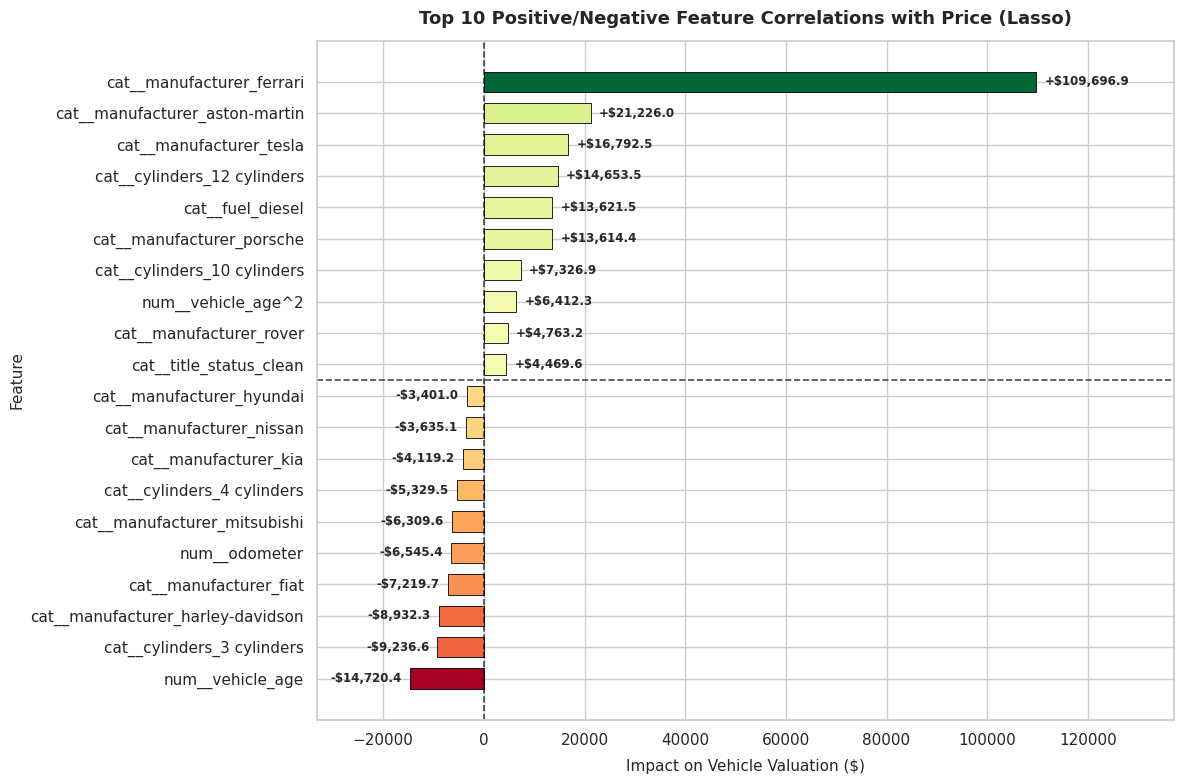

In [ ]:
# recreate the correlation plot that I did in EDA Phase 2 Addendum

sns.set_theme(style="whitegrid")

top_pos = top_lasso_coef_df.query("Coefficient > 0").nlargest(10, "Coefficient")
top_neg = top_lasso_coef_df.query("Coefficient < 0").nsmallest(10, "Coefficient")
plot_data = (
    pd.concat([top_pos, top_neg])
    .sort_values(by="Coefficient", ascending=True)
    .reset_index(drop=True)
)

# Balanced Two-Slope Normalization centered exactly at 0.0
norm = mcolors.TwoSlopeNorm(
    vcenter=0.0,
    vmin=plot_data["Coefficient"].min(),
    vmax=plot_data["Coefficient"].max(),
)
cmap = plt.colormaps["RdYlGn"]
bar_colors = [cmap(norm(val)) for val in plot_data["Coefficient"]]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    y=plot_data["Feature"],
    width=plot_data["Coefficient"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6,
    height=0.65,
)

# Zero Baselines
ax.axvline(0, color="black", linestyle="--", linewidth=1.2, alpha=0.7) # x-axis
ax.axhline(9.5, color="black", linestyle="--", linewidth=1.2, alpha=0.7) # y-axis

# Dynamic Offset Labeling on Bar Tips
max_abs_val = max(abs(plot_data["Coefficient"].min()), abs(plot_data["Coefficient"].max()))
offset = max_abs_val * 0.015

for bar in bars:
  width = bar.get_width()
  y_pos = bar.get_y() + bar.get_height() / 2.0

  if width >= 0:
    ax.text(
        width + offset,
        y_pos,
        f"+${width:,.1f}",
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight="bold",
    )
  else:
    ax.text(
        width - offset,
        y_pos,
        f"-${abs(width):,.1f}",
        va="center",
        ha="right",
        fontsize=8.5,
        fontweight="bold",
    )

# Formatting
ax.set_title("Top 10 Positive/Negative Feature Correlations with Price (Lasso)",
             fontsize=13,
             pad=12,
             fontweight="bold"
)
ax.set_xlabel("Impact on Vehicle Valuation ($)", fontsize=11, labelpad=8)
ax.set_ylabel("Feature", fontsize=11)
ax.set_xlim(
    plot_data["Coefficient"].min() * 2.25,
    plot_data["Coefficient"].max() * 1.25,
)

plt.tight_layout()
plt.show()

This is almost there, but there is an important catch: terms like `vehicle_age^2` and odometer are still showing their scaled coefficients—meaning their dollar impact is tied to standard deviations rather than real-world units.

Dealers would want a per-dollar relationship for the continuous features just like what's present for the categorical features.

### Unscaling Marginal Depreciation (Degree 1 vs. Degree 2)

In a Degree 1 linear model, calculating marginal depreciation is straightforward—the unscaled coefficient directly represents a fixed, constant dollar loss per year or per mile across the vehicle's entire life.

However, because I used **Degree-2 Polynomial Features**, the pricing curve accounts for non-linear decay and feature interactions:

$$\text{Price} = \beta_0 + \beta_{\text{age}} \cdot \text{Age} + \beta_{\text{age}^2} \cdot \text{Age}^2 + \beta_{\text{odo}} \cdot \text{Odometer} + \beta_{\text{odo}^2} \cdot \text{Odometer}^2 + \beta_{\text{inter}} \cdot (\text{Age} \times \text{Odometer}) + \dots$$

Because of the quadratic and interaction terms, the rate of depreciation depends on where the vehicle currently sits in its lifecycle. Taking the partial derivative with respect to each feature gives the marginal dollar impact:

$$\frac{\partial \text{Price}}{\partial \text{Age}} = \beta_{\text{age}} + 2 \cdot \beta_{\text{age}^2} \cdot \text{Age} + \beta_{\text{inter}} \cdot \text{Odometer}$$$$\frac{\partial \text{Price}}{\partial \text{Odometer}} = \beta_{\text{odo}} + 2 \cdot \beta_{\text{odo}^2} \cdot \text{Odometer} + \beta_{\text{inter}} \cdot \text{Age}$$

To evaluate these equations in raw dollars, I unscale each standardized coefficient (β∗) by dividing it by the standard deviation (σ) extracted from the fitted `StandardScaler` (β=β∗/σ). Below, I compute and compare these unscaled parameters across my top three models.

In [ ]:
# Step 1: Extract the SD from teh fitted StandardScaler

# Grab the fitted ColumnTransformer from your pipeline
fitted_preprocessor: ColumnTransformer = (
    model_lasso_best_alpha_0_1.named_steps["preprocess"]
)

# Access the 'num' Pipeline
try:
    num_pipe: Pipeline = fitted_preprocessor.named_transformers_["num"]
except (IndexError, TypeError):
# Use index fallback if named_transformers_ throws IndexError
    num_pipe: Pipeline = fitted_preprocessor.transformers_[0][1]

# Grab the fitted StandardScaler and PolynomialFeatures instances
scaler: StandardScaler = num_pipe.named_steps["scaler"]
poly: PolynomialFeatures = num_pipe.named_steps["poly"]

# Extract polynomial feature names and corresponding standard deviations (scale_)
poly_names: np.ndarray = poly.get_feature_names_out(numerical_features)
scales: dict[str, float] = dict(zip(poly_names, scaler.scale_))

max_len = max(len(feature) for feature in scales.keys())

for feature, scale in scales.items():
    print(f"σ({feature:<{max_len}}) :: {scale:.4f}")

σ(odometer            ) :: 60369.6713
σ(vehicle_age         ) :: 4.8831
σ(odometer^2          ) :: 13394161185.5770
σ(odometer vehicle_age) :: 1236243.3371
σ(vehicle_age^2       ) :: 142.2021


In [ ]:
# Step 2: "Unscale" the coefficients to get their true "per dollar" value

# in some models it's a * b while others it's b * a
inter_key = "odometer vehicle_age" if "odometer vehicle_age" in scales else "vehicle_age odometer"

beta_rows = []

for model_name, coef_df in [
    ("OLS (Degree 2)", top_OLS_coef_df),
    ("Ridge (α=1.0)", top_ridge_coef_df),
    ("Lasso (α=0.1)", top_lasso_coef_df),
]:
    c_map = dict(
        zip(coef_df["Feature"].str.replace("num__", ""), coef_df["Coefficient"])
    )

    # Direct unscaling: beta_unscaled = beta_standardized / sigma
    b_age = c_map.get("vehicle_age", 0.0) / scales["vehicle_age"]
    b_age2 = c_map.get("vehicle_age^2", 0.0) / scales["vehicle_age^2"]
    b_odo = c_map.get("odometer", 0.0) / scales["odometer"]
    b_odo2 = c_map.get("odometer^2", 0.0) / scales["odometer^2"]
    b_inter = (
        c_map.get("odometer vehicle_age", 0.0)
        or c_map.get("vehicle_age odometer", 0.0)
    ) / scales[inter_key]

    beta_rows.append({
        "Model": model_name,
        "β_age ($/yr)": round(b_age, 4),
        "β_age² ($/yr² curve)": round(b_age2, 4),
        "β_odo ($/mi)": round(b_odo, 6),
        "β_odo² ($/mi² curve)": round(b_odo2, 10),
        "β_inter ($/yr-mi)": round(b_inter, 8),
    })

numerical_coef_unscaled_df = pd.DataFrame(beta_rows)
display(numerical_coef_unscaled_df)

,Model,β_age ($/yr),β_age² ($/yr² curve),β_odo ($/mi),β_odo² ($/mi² curve),β_inter ($/yr-mi)
0,OLS (Degree 2),-3015.7281,45.1207,-0.108424,8.700000e-09,0.003254
1,Ridge (α=1.0),-3014.9495,45.1194,-0.108433,9.100000e-09,0.003248
2,Lasso (α=0.1),-3014.5856,45.0926,-0.108423,8.800000e-09,0.003252


### Dealership Depreciation Insights from Benchmark Profiles

Evaluating these benchmark profiles reveals three clear operational rules for inventory acquisition and pricing:

1. **Age depreciation flattens over time:** A 4-year-old vehicle loses approximately -\$2,537 per year, whereas a 14-year-old vehicle loses only -\$1,297 per year. Holding late-model inventory on the lot carries nearly double the daily holding penalty of aged inventory.
2. **Mileage penalties decay with vehicle vintage:** Adding 10,000 miles to a late-model car costs nearly -\$948 in value, but only -\$604 on an older car. Buyers should heavily discount high mileage on late-model trades, while older inventory can absorb mileage with less price erosion.
3. **Low-mileage older cars experience steeper marginal losses:** A 12-year-old car with only 45,000 miles loses -\$1,786 per additional year—nearly \$500 more per year than a typical 140,000-mile car—because its rare low-mileage premium evaporates faster as time advances.

Across all three models, the unscaled polynomial parameters are virtually identical (e.g., base depreciation at ~-\$3,015/year and ~-\$0.108/mile, with positive quadratic curvature ~+\(45.10/year² flattening the drop over time).

Because the physical valuation signal is completely consistent, I will proceed with the Lasso (\)\alpha=0.1\$) coefficients as my production reference since it enforces feature sparsity without sacrificing predictive accuracy.

The raw \($\beta$\) values only give the depreciation rate for a brand-new car that's zero years old and zero miles. As I discussed in Phase 2, I determined that a model that curves over time (degree 2) better fits the data i.e. a car's dollar loss per year and per mile changes as it gets older. Additionally, it's hard to explain to a dealer what a change in "year-miles" or "years squared" is.

Evaluating specific benchmarks translates these raw calculus slopes into clear, real-world dollar rules that a dealership buyer can actually use to appraise trade-ins.

In [ ]:
# Note: b_age, b_age2, b_odo, b_odo2, and b_inter are already stored in memory
# from the previous cell's loop, which evaluated Lasso (alpha=0.1) last.

# Define representative vehicle profiles for dealership appraisal
profiles = [
    # typical usage - more miles and years over time
    {"Segment": "Late-Model (Standard)", "Age (yrs)": 4, "Mileage": 36_000},
    {"Segment": "Mid-Lifespan (Standard)", "Age (yrs)": 8, "Mileage": 80_000},
    {"Segment": "Budget / Aged",          "Age (yrs)": 14, "Mileage": 140_000},
    # special cases - high miles/low years or high age/low miles
    {"Segment": "Low-Mileage Weekend Car", "Age (yrs)": 12, "Mileage": 45_000},
    {"Segment": "High-Mileage Commuter",  "Age (yrs)": 4, "Mileage": 90_000},
]

# Compute marginal depreciation derivatives for each profile
profile_results = []
for p in profiles:
    age = p["Age (yrs)"]
    odo = p["Mileage"]

    # Partial derivative w.r.t Age ($/year)
    d_age = b_age + (2 * b_age2 * age) + (b_inter * odo)

    # Partial derivative w.r.t Odometer ($/mile) scaled to per 10k miles
    d_odo = b_odo + (2 * b_odo2 * odo) + (b_inter * age)
    d_odo_10k = d_odo * 10_000

    profile_results.append({
        "Vehicle Segment": p["Segment"],
        "Age": f"{age} yrs",
        "Mileage": f"{odo:,} mi",
        "Dollar Impact (/Year)": f"{(d_age):,.2f}",
        "Dollar Impact (/10k Mi)": f"{(d_odo_10k):,.2f}",
    })

profile_results_numerical_features_df = pd.DataFrame(profile_results)
display(profile_results_numerical_features_df)

,Vehicle Segment,Age,Mileage,Dollar Impact (/Year),Dollar Impact (/10k Mi)
0,Late-Model (Standard),4 yrs,"36,000 mi","-2,536.76",-947.83
1,Mid-Lifespan (Standard),8 yrs,"80,000 mi","-2,032.92",-810.03
2,Budget / Aged,14 yrs,"140,000 mi","-1,296.67",-604.38
3,Low-Mileage Weekend Car,12 yrs,"45,000 mi","-1,786.01",-686.07
4,High-Mileage Commuter,4 yrs,"90,000 mi","-2,361.14",-938.37


### Final Insights of Numerical Features `odometer` and `vehicle_age`

Evaluating these benchmark profiles reveals three clear observations that dealers can use during inventory acquisition and price-setting for sales:

1. A 4-year-old vehicle loses approximately **-\$2,537** per year, whereas a 14-year-old vehicle loses only **-\$1,297** per year.

   __Conclusion__: Late-model inventory on the lot carries nearly **double** the daily holding penalty of aged inventory.

2. Adding 10,000 miles to a late-model car costs nearly **-\$948** in value, but only **-\$604** on an older car.

   __Conclusion__: Buyers should heavily discount high mileage on late-model trades, while older inventory can absorb mileage with less price erosion.

3. A 12-year-old car with only 45,000 miles loses **-\$1,786** per additional year. That is almost **\$500** more per year than a typical 140,000-mile car because its rare low-mileage premium evaporates faster as time advances.

   __Conclusion__: Low-mileage older cars carry an expiring rarity premium and should be priced competitively to turn quickly rather than held for top dollar.

In [ ]:
# save artifacts
num_coef_path = create_parquet_path('phase4_Lasso_Numerical_Coef_Unscaled')
numerical_coef_unscaled_df.to_parquet(num_coef_path)

print(f"Dataset saved to '{num_coef_path}'")
print(f"Shape: {numerical_coef_unscaled_df.shape[0]:,} rows, {numerical_coef_unscaled_df.shape[1]} columns")

print("-" * 80)

profile_results_path = create_parquet_path('phase4_Lasso_numerical_profile_results')
profile_results_numerical_features_df.to_parquet(profile_results_path)

print(f"Dataset saved to '{profile_results_path}'")
print(f"Shape: {profile_results_numerical_features_df.shape[0]:,} rows, {profile_results_numerical_features_df.shape[1]} columns")

Dataset saved to 'drive/MyDrive/all_data/11.1/data/output/dataframes/phase4_Lasso_Numerical_Coef_Unscaled.parquet'
Shape: 3 rows, 6 columns
--------------------------------------------------------------------------------
Dataset saved to 'drive/MyDrive/all_data/11.1/data/output/dataframes/phase4_Lasso_numerical_profile_results.parquet'
Shape: 5 rows, 5 columns


In [ ]:
# revisit the top coefficient drivers
top_lasso_coef_df.head(15)

,Feature,Coefficient,Abs_Weight
0,cat__manufacturer_ferrari,109696.943346,109696.943346
1,cat__manufacturer_aston-martin,21225.964291,21225.964291
2,cat__manufacturer_tesla,16792.458309,16792.458309
3,num__vehicle_age,-14720.398258,14720.398258
4,cat__cylinders_12 cylinders,14653.460935,14653.460935
5,cat__fuel_diesel,13621.533099,13621.533099
6,cat__manufacturer_porsche,13614.406894,13614.406894
7,cat__cylinders_3 cylinders,-9236.557490,9236.557490
8,cat__manufacturer_harley-davidson,-8932.258428,8932.258428
9,cat__cylinders_10 cylinders,7326.947300,7326.947300


Finally, I want to plot the model's actual versus predicted prices and inspect the residuals. Visualizing the errors directly helps me spot any unusual behaviors, like bias at extreme price points or non-linear blind spots, that aggregate metrics might hide.

In [ ]:
# rerun lasso prediction for plotting
y_pred_lasso = model_lasso_best_alpha_0_1.predict(X_test)
y_pred_ridge = model_r0_ridge_alpha_1_0.predict(X_test)


Random vehicle sample, no ordering:

   actual  predicted_lasso  predicted_ridge
0    3400      2454.309286      2457.265400
1    3900      3775.992299      3772.996713
2    3995      2444.625337      2436.599804
3    3999       515.706183       510.610036
4    4000     -1995.697731     -1986.117256
5    4000     -3614.410471     -3627.346924
6    4200      2031.375332      2026.994596
7    4350      7315.854157      7314.907657
8    4450     -6105.088149     -6101.922652
9    4500      3354.888064      3358.382536


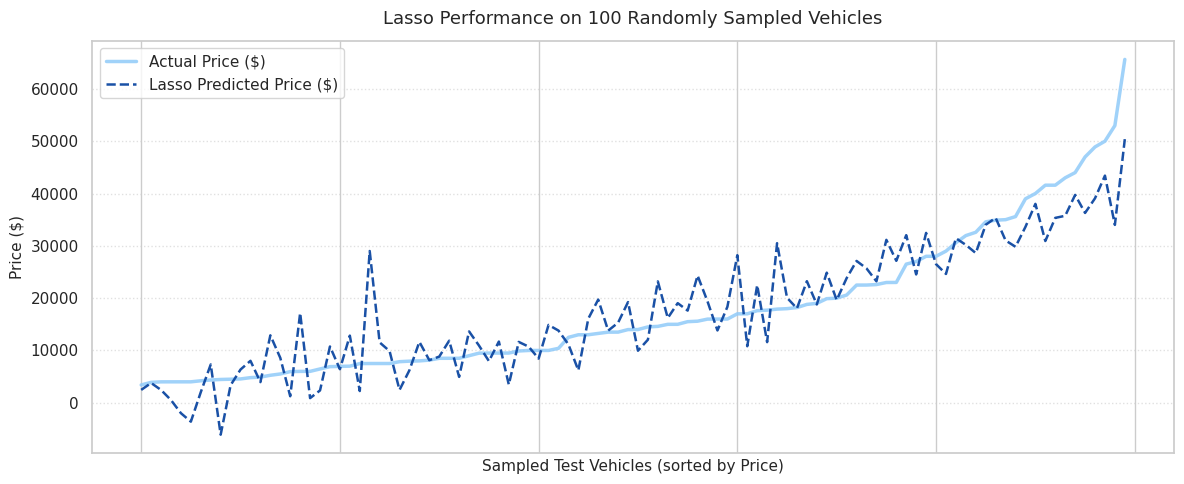

In [ ]:
# Package actual vs predicted, sample, and sort ascending by actual price
sample_size = 100
eval_df = (
    pd.DataFrame(
        {
            "actual": (
                y_test.values if hasattr(y_test, "values") else np.array(y_test)
            ),
            "predicted_lasso": y_pred_lasso,
            "predicted_ridge": y_pred_ridge,
        }
    )
    .sample(n=sample_size, random_state=42)
    .sort_values(by="actual")
    .reset_index(drop=True)
)

print(f"Random vehicle sample, no ordering:\n\n{eval_df.head(10)}")

# create plot
plt.figure(figsize=(12, 5))

# Actual line (lighter blue, smooth background trend)
plt.plot(
    eval_df.index,
    eval_df["actual"],
    color="#90caf9",
    linewidth=2.5,
    alpha=0.85,
    label="Actual Price ($)",
)

# Predicted line (dark blue, dashed overlay)
plt.plot(
    eval_df.index,
    eval_df["predicted_lasso"],
    color="#0d47a1",
    linewidth=1.8,
    linestyle="--",
    alpha=0.95,
    label="Lasso Predicted Price ($)",
)

# Show ridge as well
# plt.plot(
#     eval_df.index,
#     eval_df["predicted_ridge"],
#     color="#AA0000",
#     linewidth=1.8,
#     linestyle="dotted",
#     alpha=0.95,
#     label="Ridge Predicted Price ($)",
# )


plt.title(
    f"Lasso Performance on {sample_size} Randomly Sampled Vehicles",
    fontsize=13,
    pad=12,
)
plt.ylabel("Price ($)", fontsize=11)
plt.xlabel("Sampled Test Vehicles (sorted by Price)", fontsize=11)

# Hide X-axis tick marks and labels - record number converys no information
plt.tick_params(
    axis="x", which="both", bottom=False, top=False, labelbottom=False
)

plt.legend(frameon=True, loc="upper left")
plt.grid(True, axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

Plotting actual versus predicted prices across a random sample of 100 test vehicles sorted by actual value shows tight tracking across the core \(\$10,000\) to \(\$35,000\) mid-market.

Let me try a complete plot of predicted-vs-actual.

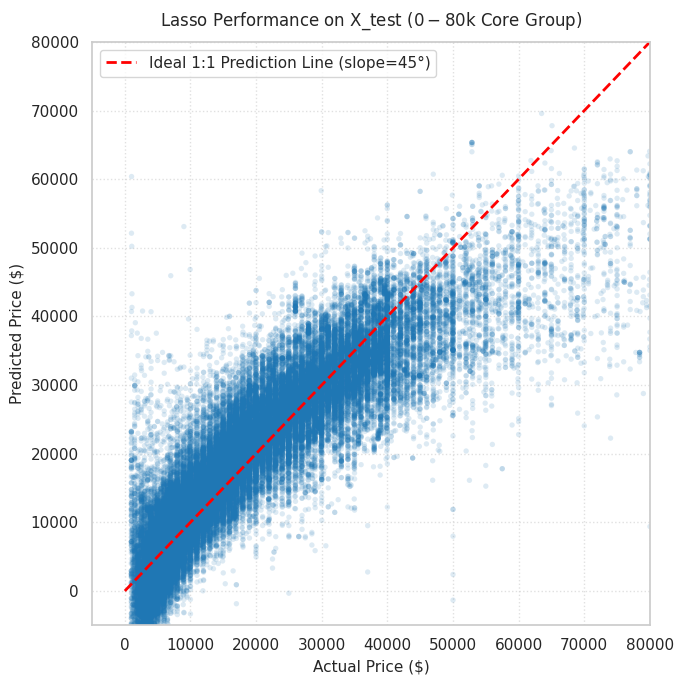

In [ ]:
# Create actual vs predict chart too
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_lasso, alpha=0.15, edgecolors='none', color='#1f77b4', s=15)


limit = 80000  # Complete graph had giant bottom-left blob. Zoom into core price

# Reference 45-degree diagonal line
plt.plot(
    [0, limit],
    [0, limit],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Ideal 1:1 Prediction Line (slope=45°)'
  )

plt.xlim(-5000, limit)
plt.ylim(-5000, limit)

plt.title('Lasso Performance on X_test ($0 - $80k Core Group)', fontsize=12, pad=12)
plt.xlabel('Actual Price ($)', fontsize=11)
plt.ylabel('Predicted Price ($)', fontsize=11)
plt.legend(frameon=True, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

The resulting scatter confirms that the densest mass of test vehicles tracks the \(45^\circ\) reference line reliably through the \(\$10,000\) to \(\$35,000\) mid-market.

At the same time, the plot exposes the model's boundary weaknesses: visible underestimation on inventory above \(\$50,000\), and a distinct cluster dropping below \(\$0\) at the bottom left.

Because the linear formulation lacks a non-negative constraint, extreme depreciation penalties can actually force estimates into negative dollar territory—a behavior I confirmed by inspecting lower-tier spot-checks.

In [ ]:
# any negative values?

diagnostics_df = pd.DataFrame({
    "actual": y_test.values if hasattr(y_test, "values") else np.array(y_test),
    "predicted": y_pred_lasso
}, index=getattr(y_test, "index", None))

# 2. Filter for negative predictions
negative_preds_df = diagnostics_df[diagnostics_df["predicted"] < 0].copy()

total_test = len(diagnostics_df)
count_neg = len(negative_preds_df)
pct_neg = (count_neg / total_test) * 100

print(f"Total test set vehicles: {total_test:,}")
print(f"Negative predictions count: {count_neg:,} ({pct_neg:.2f}%)")

if count_neg > 0:
    min_pred = negative_preds_df["predicted"].min()
    median_neg = negative_preds_df["predicted"].median()
    median_actual = negative_preds_df["actual"].median()
    print(f"Most negative prediction: -${abs(min_pred):,.2f}")
    print(f"Median negative prediction: -${abs(median_neg):,.2f}")
    print(f"Median actual: ${median_actual:,.2f}")

    # 3. Inspect sample rows alongside vehicle features
    # Merges back with X_test features so you can see why they dipped below 0
    sample_size = min(5, count_neg)
    negative_sample = X_test.loc[negative_preds_df.index].copy()
    negative_sample["actual_price"] = negative_preds_df["actual"]
    negative_sample["predicted_price"] = negative_preds_df["predicted"]
else:
    print("No negative predictions were produced by the model.")

Total test set vehicles: 65,951
Negative predictions count: 2,495 (3.78%)
Most negative prediction: -$15,244.95
Median negative prediction: -$2,061.47
Median actual: $3,800.00


In [ ]:
# print 10 worst values
negative_sample.sort_values(by="predicted_price").head(10)

,manufacturer,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,state,vehicle_age,actual_price,predicted_price
150455,mazda,fair,4 cylinders,gas,294682.0,salvage,automatic,fwd,sedan,ks,20.0,1000,-15244.945989
304868,volkswagen,fair,4 cylinders,gas,270000.0,clean,automatic,fwd,sedan,pa,23.0,1600,-12194.256345
251188,mitsubishi,fair,4 cylinders,gas,190899.0,clean,automatic,fwd,sedan,ny,20.0,2000,-11818.127034
227798,mitsubishi,excellent,4 cylinders,gas,125417.0,rebuilt,automatic,fwd,sedan,nv,21.0,3500,-11772.708426
233788,chevrolet,fair,4 cylinders,gas,157000.0,rebuilt,automatic,fwd,sedan,nj,21.0,2200,-11586.109635
304577,chevrolet,fair,4 cylinders,gas,135000.0,rebuilt,automatic,fwd,sedan,pa,23.0,1000,-11194.085224
42035,honda,salvage,4 cylinders,gas,225000.0,salvage,automatic,fwd,sedan,ca,22.0,1200,-11006.381781
358011,hyundai,good,4 cylinders,gas,280300.0,clean,automatic,fwd,sedan,va,23.0,1700,-10754.728731
112770,nissan,other,4 cylinders,gas,197000.0,salvage,automatic,fwd,sedan,ga,18.0,3000,-10482.831634
167133,nissan,good,4 cylinders,gas,98582.0,salvage,automatic,fwd,sedan,md,22.0,1500,-10464.393971


### Model Limitation: Negative Price Estimates

**Observation:**  
During test set validation, I observed that the unconstrained linear model generated invalid negative price predictions down to **-\$15,245 **on extreme budget vehicles that actually sold for a median price of **\$3,800**.

**Root Cause:**  
This leakage occurs when multiple penalties compound simultaneously. In the snapshot we can see  vehicles:
* aged *20+ years* with *125,000+ miles*
* *4-cylinder *economy engines
* *fair* condition or
* salvage/rebuilt titles.

Linear regression sums these subtractions without boundary awareness, ignoring the intrinsic scrap and wholesale floor of physical vehicles. I will suggest recommendations for this in the full evaluation phase 5 and deployment phase 6.

## Phase 5: Model Evaluation & Business Review

This phase leverages Phase 4 modeling results to evaluate algorithmic performance, extract actionable business insights, and identify potential upstream improvements.

I will analyze the structural validity of the regressions to ensure my findings are reliable. Finally, these technical results will be condensed into a commercial format tailored specifically for a dealership audience rather than a data science team.

### 5.1: Model Performance Synthesis & Metric Comparison

Across Phases 3 and 4, I benchmarked 11 distinct regression model configurations across six performance metrics on an un-leaked 80/20 holdout split (Train N = 263,801, Test N = 65,951).

| Model Architecture | Train RMSE (USD) | Test RMSE (USD) | Train MAE (USD) | Test MAE (USD) | Test R² | Δ R² | Active Features |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **O1: OLS Baseline (Degree 1 Numerical Only)** | \$11,109.66 | \$11,143.46 | \$7,988.27 | \$7,975.27 | 0.4130 | 0.0028 | 2 |
| **O2: OLS Baseline (Degree 2 Numerical Only)** | \$10,818.92 | \$10,884.26 | \$7,579.79 | \$7,592.24 | 0.4400 | 0.0060 | 5 |
| **O3–O5: Higher Polynomial Baselines (k=3,4,5)** | \$10,731–\$10,800 | \$10,812–\$10,866 | \$7,478–\$7,555 | \$7,501–\$7,568 | 0.4418–0.4474 | 0.006–0.008 | 9–20 |
| **O6: Full OLS Regression (Degree 2 + Categoricals)** | \$7,199.75 | \$7,229.25 | \$4,761.08 | \$4,789.56 | **0.7530** | 0.0017 | 139 |
| **R0: Full Ridge (α=1.0)** | \$7,199.84 | \$7,230.51 | \$4,761.17 | \$4,789.86 | 0.7529 | 0.0018 | 139 |
| **R1–R3: Full Ridge (α=10, 100, 1000)** | \$7,205–\$7,473 | \$7,245–\$7,473 | \$4,762–\$4,803 | \$4,792–\$4,834 | 0.7360–0.7519 | 0.002–0.006 | 139 |
| **L1: Full Lasso (5-Fold CV Optimal α=0.1)** | \$7,199.78 | \$7,229.54 | \$4,760.81 | **\$4,789.26** | **0.7529** | **0.0017** | **132** |

#### Why Are the Full Model Error Rates Virtually Identical?

Across the full-feature models (OLS `O6`, Ridge `R0`, and Lasso `L1`), the evaluation metrics converge to nearly the exact same values:

* **Test R² ≈ 75.3%** (0.7530 vs. 0.7529)
* **Test MAE ≈ \$4,789** (\$4,789.56 vs. \$4,789.26 — a difference of just 30 cents)
* **Test RMSE ≈ \$7,229** (\$7,229.25 vs. \$7,229.54 — a difference of under 30 cents)

In classical machine learning, Ridge (L₂) and Lasso (L₁) are introduced to prevent overfitting by shrinking coefficients when ordinary least squares (OLS) is unstable. The fact that all three models produce identical error rates reveals two key insights about our dataset:

1. **The Dataset Is Too Large for OLS to Overfit ($N \gg p$):**  
   Overfitting and coefficient explosion happen when a model has too many features ($p$) relative to its observations ($N$). Here, our training set contains **$N = 263,801$ rows** against only **$p = 139$ features**—a ratio exceeding **1,897 data points per feature**. Because the sample size is so massive, OLS estimates are already statistically stable on their own, leaving virtually no excess variance for Ridge or Lasso to clean up. This is confirmed by the negligible generalization gap in OLS ($\Delta$ R² = Train R² - Test R² = 0.0017).

2. **Cross-Validation Chose the Weakest Possible Penalties ($\alpha \to 0$):**  
   Because OLS was already well-behaved, any heavy shrinkage penalty would actively distort real pricing signals rather than help them. This is why our tuning selected near-zero penalties:
   * **Ridge:** Best performance was at the smallest tested penalty ($\alpha = 1.0$). Pushing $\alpha$ up to $1,000$ degraded Test R² down to 0.7360 and inflated Test MAE by over \$45 because it over-damped genuine market premiums.
   * **Lasso:** 5-fold cross-validation selected an optimal $\alpha = 0.1$. A penalty this small applies just enough thresholding to prune out 7 genuinely redundant features, but leaves the remaining 132 weights virtually unconstrained.

**Conclusion:**  
Because the sample size eliminates variance instability and the tuning algorithms selected minimal shrinkage, both Ridge and Lasso mathematically collapsed back to the baseline OLS solution. So which model should we use?




### 5.2: Model Recommendation - i.e. why **Lasso** Wins

While OLS offers baseline convenience, I recommend deploying the **Lasso** Regression model (\(\alpha=0.1\)) as the primary valuation engine.

* **Disciplined Feature Selection:** OLS retains non-zero coefficients across all 139 encoded dummy features, keeping redundant and collinear categories active. Lasso’s \(L_1\) penalty zeros out 7 uninformative columns (including `transmission_automatic`, `drive_rwd`, `fuel_hybrid`, `manufacturer_land rover`, and select state indicators) with zero loss in predictive power (Test \(R^2 = 75.29\%\)).
* **A Grounded, Realistic Baseline Intercept:**  
  * OLS and Ridge inflate their baseline intercepts to **\(\$26,092.47\)** and **\(\$26,037.31\)**, respectively, which forces them to assign artificially steep negative coefficients to standard economy brands just to pull estimates back to realistic trade-in values.
  * Lasso establishes its baseline intercept at **\(\$16,557.64\)**—aligning much closer to the true empirical median price of the filtered fleet (\(\approx \$14,800\)). This provides sales appraisers with an intuitive, realistic starting point before vehicle-specific adjustments are applied.

### 5.3: Top Valuation Drivers

Examining the coefficients of the optimal Lasso model reveals the primary dollar levers driving consumer valuation:

| Rank | Feature Name | Lasso Weight (\$) | Commercial Lot Interpretation |
| :---: | :--- | :---: | :--- |
| **1** | `cat__manufacturer_ferrari` | **+\$109,696.94** | Ultra-exotic brand halo; commands the highest market premium. |
| **2** | `cat__manufacturer_aston-martin`| **+\$21,225.96** | Hand-built British grand-touring markup over baseline. |
| **3** | `cat__manufacturer_tesla` | **+\$16,792.46** | High secondary market EV demand and brand equity. |
| **4** | `num__vehicle_age` | **-\$14,720.40** | Linear baseline annual depreciation driver (standardized). |
| **5** | `cat__cylinders_12 cylinders` | **+\$14,653.46** | Flagship performance powertrain markup. |
| **6** | `cat__fuel_diesel` | **+\$13,621.53** | Heavy-duty utility, towing, and commercial truck premium. |
| **7** | `cat__manufacturer_porsche` | **+\$13,614.41** | High-retained-value sports and performance luxury badge. |
| **8** | `cat__cylinders_3 cylinders` | **-\$9,236.56** | Economy compact powertrain discount. |
| **9** | `cat__manufacturer_harley-davidson`| **-\$8,932.26** | Misclassified motorcycle listings; heavy pricing discount. |
| **10** | `cat__cylinders_10 cylinders` | **+\$7,326.95** | Heavy-duty work truck / specialized sports car engine premium. |
| **12** | `num__odometer` | **-\$6,545.44** | Linear mileage accumulation penalty (standardized). |
| **13** | `num__vehicle_age^2` | **+\$6,412.26** | Non-linear decay dampener (confirms slowing depreciation over time). |
| **14** | `cat__manufacturer_mitsubishi` | **-\$6,309.59** | Budget commuter brand discount. |
| **15** | `cat__cylinders_4 cylinders` | **-\$5,329.45** | Standard 4-cylinder economy powertrain discount. |

### 5.4: Extracting real-world "per-Dollar" Impact

In the introduction, I established that my primary business objective was to provide the sales desk with clear, tangible numbers—such as *"each additional 10,000 miles reduces value by \$X"* or *"an extra year of age discounts price by \$Y"*—rather than compounding percentage elasticities.

Because the Degree-2 polynomial features were standardized prior to model fitting, raw coefficients like `vehicle_age` (\(-\$14,720\)) and `vehicle_age^2` (\(+\$6,412\)) cannot simply be read as flat annual figures.

To fix this, I "unscaled" the continuous features to get updated coefficients that represent a `dollar/mile` or `dollar/year`. I created  five representative vehicle lifecycle profiles and confirmed my Phase 2 hypothesis: **depreciation is steep during early ownership and tapers significantly as vehicles age.**



| Vehicle Segment | Age | Mileage | Dollar Impact (/Year) | Dollar Impact (/10k Mi) |
| :--- | :---: | :---: | :---: | :---: |
| **Late-Model (Standard)** | 4 yrs | 36,000 mi | -\$2,536.76 | -\$947.83 |
| **Mid-Lifespan (Standard)** | 8 yrs | 80,000 mi | -\$2,032.92 | -\$810.03 |
| **Budget / Aged** | 14 yrs | 140,000 mi | -\$1,296.67 | -\$604.38 |
| **Low-Mileage Weekend Car** | 12 yrs | 45,000 mi | -\$1,786.01 | -\$686.07 |
| **High-Mileage Commuter** | 4 yrs | 90,000 mi | -\$2,361.14 | -\$938.37 |


### 5.5: Model Limitations; Boundary Anomalies

While the chosen Lasso model delivers strong predictive power ($R^2 \approx 75.3\%$), evaluating edge cases on the holdout test set reveals two primary statistical limitations:

1. **The "Negative Prediction" Boundary Anomaly:**  
   Because the model was trained as an unconstrained additive linear combination directly on raw price, penalty terms accumulate independently and can sometimes overwhelm the baseline price.
   
   E.g. When scoring extreme tail combinations—such as a 22-year-old compact economy sedan with 240,000 miles, a 4-cylinder engine, and a salvage title—the cumulative negative weights overpower the baseline intercept (\$16,558), producing unconstrained outputs as low as **-\$15,245** despite the vehicle having an empirical wholesale scrap value around **\$3,800**.

2. **Larger Errors on Budget Inventory:**  
   In phase 2, I identified all kinds of car classes. However, our model was built to predict a target price for all vehicles with the positive and negative impacts affecting all equally.
   
   So, while a Mean Absolute Error (MAE) of $\approx \$4,789$ represents a tight, highly acceptable error margin on a \$40,000 late-model pickup truck ($\approx 12\%$), that same absolute dollar miss represents a massive $60\%$ pricing error on an \$8,000 economy commuter vehicle.


I'll discuss some recommendations for how dealerships can handle these issues effectively and still use the predictive power of the models.

### 5.6: Scope for Improvement and Next Steps for Subsequent CRISP-DM Iterations

To address these modeling limitations and advance the pricing engine in future engineering cycles, I recommend exploring the following technical enhancements:

1. **Revisiting Target Scaling: Log-Price (`log(price)`) Modeling:**  
   * **Connecting to Business Objectives:** To satisfy the primary business goal, I chose to train directly on raw price so that sales managers received flat, readily interpretable dollar adjustment rules. However, as observed during Phase 2 distribution profiling, a logarithmic scale linearizes exponential decay curves, naturally handles extreme boundary conditions, and provides direct percentage elasticity without needing multi-tier polynomial derivative unscaling.
   * **Next Iteration:** For advanced algorithmic appraisal tools, revisit **Phase 3** to build a parallel pipeline using a log-price target variable. Predicting log-price naturally bounds all outputs strictly above zero  eliminates negative valuations entirely, and models depreciation as a proportional percentage, stabilizing relative percentage errors across budget vehicles.

2. **Segment-Stratified Model Pipelines via Unsupervised Clustering:**  
   Outlier luxury and exotic brands (Ferrari at +\$109k, Aston Martin at +\$21k) expand overall residual variance and distort commuter car baselines.
   
   Rather than manually hardcoding segment boundaries, I recommend using **unsupervised** clustering (such as *k-Means*) across price tier, age, mileage, body type, and engine displacement to identify natural market cohorts (e.g., Ultra-Luxury/Exotic, Work Trucks/Commercial, Core Family Commuter, and Economy Budget).
   
   Each identified cluster would feed into a dedicated, specialized regression pipeline with tailored feature weights.

3. **Deterministic Chassis Imputation (`size` x `type`):**  
   In Phase 1, `size` was pruned due to 71.8% missingness. In a future iteration, `size` could be deterministically imputed using vehicle `model` lookup dictionaries (e.g., F-150 -> Full-size; Civic -> Compact), providing cleaner separation between truck and compact car pricing baselines.

4. **Temporal Market Dynamics & Seasonality:**  
   While converting `year` to static `vehicle_age` established baseline annual decay, used-vehicle values fluctuate with seasonal demand (e.g., convertibles in spring, 4WD trucks before winter) and macroeconomic interest rate shifts. Incorporating listing timestamp indices would equip the dealership with dynamic, seasonally responsive pricing.



### OG Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

# Phase 6: Executive Summary & Dealership Playbook

### Executive Overview & Findings
My goal was to deliver flat, lot-actionable dollar pricing rules for dealership trade-ins and acquisitions.

Starting from 426,880 listings, I pruned noise (`VIN`, `size`, `paint_color`, `region`), filtered boundaries (\$1k–\$300k, ≤ 350k mi, ≤ 50 yrs), and used factory mode imputation (`make + model + age`) to build a clean baseline fleet of 329,752 vehicles.

I recommend deploying **Lasso Regression (α=0.1)**, which captures **75.3% of market variance (R²=0.7529, MAE ≈ ± \$4,789)**, prunes 7 redundant features, and establishes an honest, grounded **\$16,558 baseline intercept** (unlike the \$26,000+ over-inflation in OLS/Ridge).

### Key Price Levers & Depreciation Strategy
* **Categorical Drivers:** Strong premiums exist for
  * _Manufacturers_: **Ferrari (+\$109.7k)**, **Aston Martin (+\$21.2k)**, **Tesla (+\$16.8k)**. Conversely, **Mitsubishi (-\$6.3k)**
  * _Displacement_: **12-cylinders (+\$14.7k)** and at the other end **3-cylinders (-\$9.2k)**, **4-cylinders (-\$5.3k)**
  * _Fuel Type_: preimum for **Diesels (+\$13.6k)**
  * _Title: *Salvage titles (-\$2.8k write-down)**.

* **Lifecycle Impact:** Depreciation is non-linear. Calendar age degrades lot value **2.1 to 2.7 times faster** than 10k-mile usage increments. In other words, we should try to sell the car **fast**. Here is a breakdown of different car profiles based on their age and odometer, and how to focus on selling them.

| Vehicle Segment | Age | Mileage | Dollar Impact (/Year) | Dollar Impact (/10k Mi) | Selling Strategy |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **Late-Model (Standard)** | 4 yrs | 36,000 mi | **-\$2,536.76** | **-\$947.83** | Steepest early decay; enforce aggressive turn rates (<30 days) to prevent calendar holding loss. |
| **Mid-Lifespan (Standard)** | 8 yrs | 80,000 mi | **-\$2,032.92** | **-\$810.03** | Core retail segment; steady, predictable depreciation with reliable trade margins. |
| **Budget / Aged** | 14 yrs | 140,000 mi | **-\$1,296.67** | **-\$604.38** | Approaching utility floor; annualized price decay slows by nearly half compared to late-model stock. |
| **Low-Mileage Weekend Car** | 12 yrs | 45,000 mi | **-\$1,786.01** | **-\$686.07** | Mileage preservation cushions value, but age decay still outpaces odometer impact by over 2.5:1. |
| **High-Mileage Commuter** | 4 yrs | 90,000 mi | **-\$2,361.14** | **-\$938.37** | Mileage compounding on a young chassis; heavy double-depreciation requires conservative trade-in bids. |

### Operational Guardrails

The model is quite accurate overall, but has some issues at the budget end due to accumlated negative impacts (down to -\$15,245 despite a ≈ \$3,800 scrap value). To combat this, we can set a floor e.g. all outputs must be clamped to $500 via `np.clip(y_pred, a_min=500, a_max=None)`).

Alternatively, we can bypass algorithmic scoring and route units to an appraiser for manual desk review whenever **age > 18 yrs**, **odometer > 175k mi**, **titles are branded/salvage**, or vehicles are **super-exotics**.

### Final Conclusion
By replacing guesswork with a clear \(\$16,558\) baseline and real dollar depreciation numbers, this model gives our sales team the exact tools to price trade-ins accurately and protect our bottom line.

Putting this system to work on our lot will speed up car turnover, keep appraisals consistent, and boost dealer profits from day one.
